In [24]:
import cvxpy as cp
import numpy as np
import pandas as pd
from cvxpy import psd_wrap
import matplotlib.pyplot as plt
from cvxpy.atoms.affine.wraps import psd_wrap
from sklearn.covariance import LedoitWolf
import seaborn as sns
from plot_functions import plot_te_carbon_by_sector, plot_origin_vs_opt_weights_comparison, plot_te_carbon_heatmap
from tabulate import tabulate

| Term         | What to Use                                                     |
| ------------ | --------------------------------------------------------------- |
| `w_b_sector` | Benchmark weights **within the sector**, normalized to sum to 1 |
| `Σ_sector`   | Covariance matrix of sector constituents                        |
| `c_sector`   | Carbon intensities of sector companies                          |
| `w`          | Optimization variable: weights in sector                        |
| Constraints  | All operate **within** the sector universe                      |


# Missing Data statistics

In [25]:
# Load data
df = pd.read_excel("Data/dataset_comp_1222.xlsx")

# Columns of interest
manually_imputed_flags = ['Manually Imputed Scope 1', 'Manually Imputed Scope 2', 'Manually Imputed Scope 3']
imputed_flags = ['Scope 1 Imputed', 'Scope 2 Imputed', 'Scope 3 Imputed']

# Build the summary table
summary_rows = []

for sector, group in df.groupby('GICS Sector'):
    n_stocks = len(group)
    row = {
        'Sector': sector,
        'Number of Stocks': n_stocks
    }

    # Automatically imputed
    for col in imputed_flags:
        count = group[col].fillna(False).sum()
        row[f'{col} Count'] = count
        row[f'{col} %'] = count / n_stocks * 100

    # Manually imputed
    for col in manually_imputed_flags:
        count = group[col].fillna(False).sum()
        row[f'{col} Count'] = count
        row[f'{col} %'] = count / n_stocks * 100

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("Sector")
summary_df.reset_index(drop=True, inplace=True)
# Round all percentage columns to integers
percentage_cols = [col for col in summary_df.columns if '%' in col]
summary_df[percentage_cols] = summary_df[percentage_cols].round(0).astype('Int64')
# Create 'Missing Scope' as the sum of max imputed counts across S1/S2/S3
summary_df["Missing Scope Count"] = summary_df[
    ["Scope 1 Imputed Count", "Scope 2 Imputed Count", "Scope 3 Imputed Count"]
].max(axis=1) + summary_df[
    ["Manually Imputed Scope 1 Count", "Manually Imputed Scope 2 Count", "Manually Imputed Scope 3 Count"]
].max(axis=1)

# Now compute Missing Scope % over sector
summary_df["Missing Scope (%)"] = (summary_df["Missing Scope Count"] / summary_df["Number of Stocks"] * 100).round(0).astype('Int64')

# Define the new column order
columns_order = ['Sector', 'Number of Stocks', 'Missing Scope Count', 'Missing Scope (%)'] + \
                [col for col in summary_df.columns if col not in ['Sector', 'Number of Stocks', 'Missing Scope Count', 'Missing Scope (%)']]

# Reorder the columns
summary_df = summary_df[columns_order]

# Sort by "Missing Scope (%)"
summary_df = summary_df.sort_values("Missing Scope (%)", ascending=False)

# Optional: reset index for clean display
summary_df = summary_df.reset_index(drop=True)

summary_df

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_17289/3486243057.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  count = group[col].fillna(False).sum()
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_17289/3486243057.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  count = group[col].fillna(False).sum()


,Sector,Number of Stocks,Missing Scope Count,Missing Scope (%),Scope 1 Imputed Count,Scope 1 Imputed %,Scope 2 Imputed Count,Scope 2 Imputed %,Scope 3 Imputed Count,Scope 3 Imputed %,Manually Imputed Scope 1 Count,Manually Imputed Scope 1 %,Manually Imputed Scope 2 Count,Manually Imputed Scope 2 %,Manually Imputed Scope 3 Count,Manually Imputed Scope 3 %
0,Energy,23,10.0,43,0.0,0,0.0,0,10.0,43,0.0,0,0.0,0,0.0,0
1,Health Care,63,25.0,40,1.0,2,1.0,2,24.0,38,1.0,2,1.0,2,1.0,2
2,Industrials,74,25.0,34,1.0,1,1.0,1,23.0,31,2.0,3,2.0,3,1.0,1
3,Consumer Discretionary,52,17.0,33,1.0,2,2.0,4,14.0,27,3.0,6,2.0,4,2.0,4
4,Real Estate,32,9.0,28,0.0,0,0.0,0,8.0,25,1.0,3,1.0,3,1.0,3
5,Consumer Staples,37,10.0,27,0.0,0,0.0,0,6.0,16,4.0,11,4.0,11,2.0,5
6,Financials,75,18.0,24,4.0,5,4.0,5,13.0,17,5.0,7,5.0,7,5.0,7
7,Communication Services,22,5.0,23,2.0,9,2.0,9,4.0,18,1.0,5,1.0,5,1.0,5
8,Information Technology,63,12.0,19,1.0,2,1.0,2,10.0,16,2.0,3,2.0,3,2.0,3
9,Materials,29,4.0,14,0.0,0,0.0,0,4.0,14,0.0,0,0.0,0,0.0,0


# TE - CARBON FRONTIERS
Clipping negative eigenvalues to 0 and reconstructing the closest possible PSD matrix to the original covariance matrix in Frobenius norm

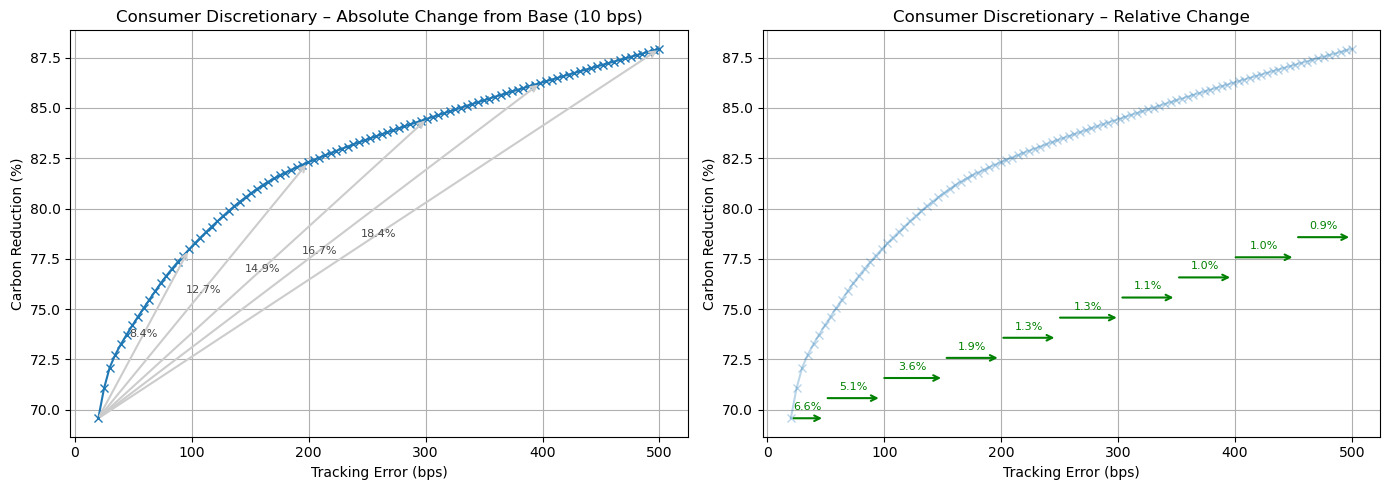

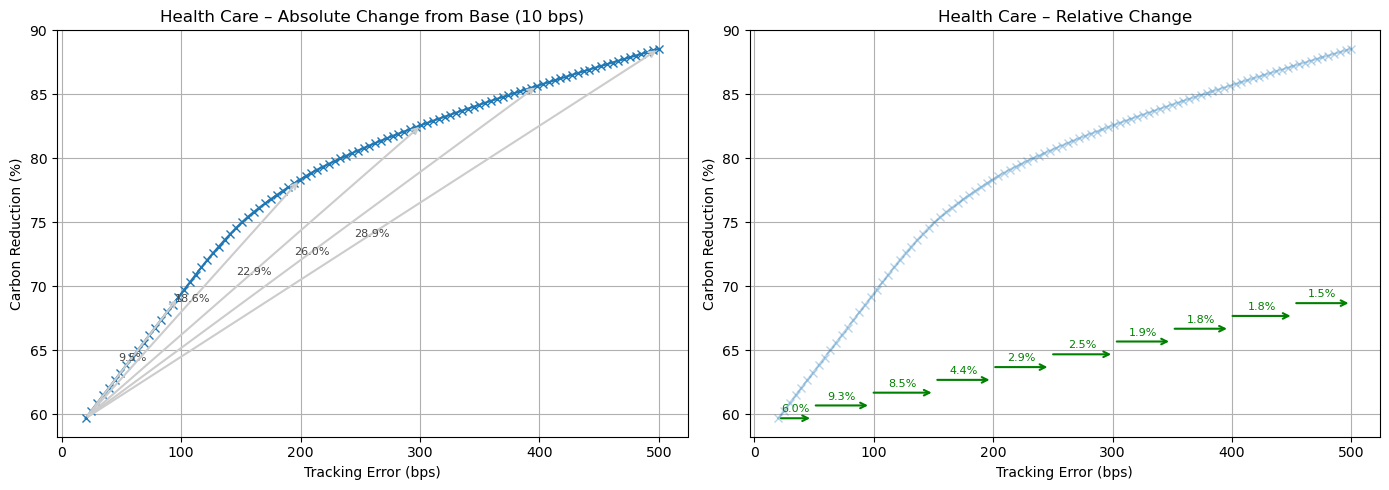

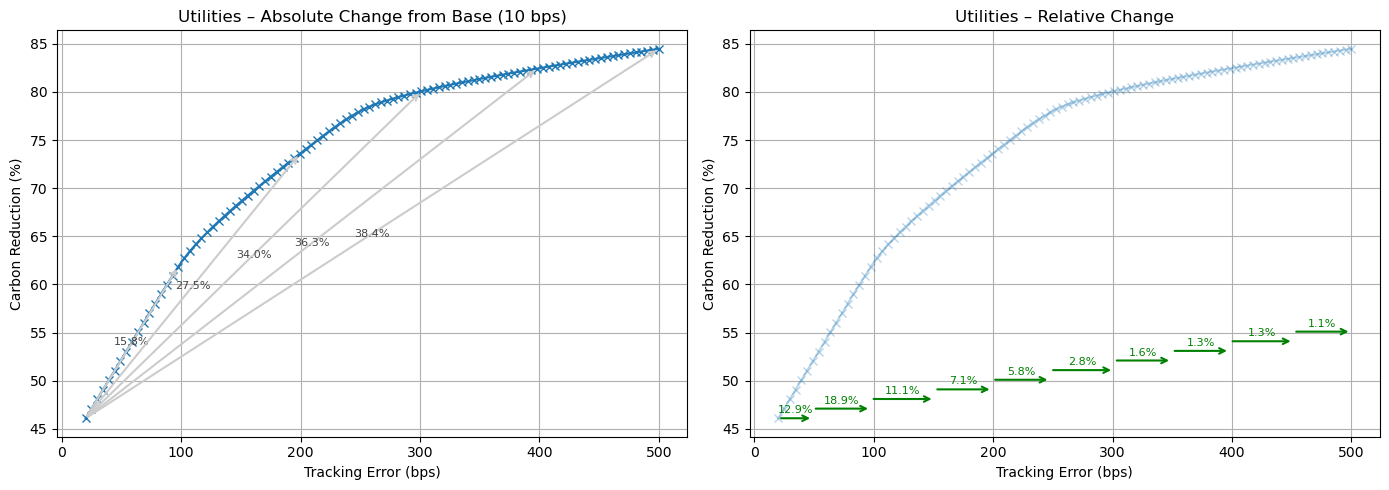

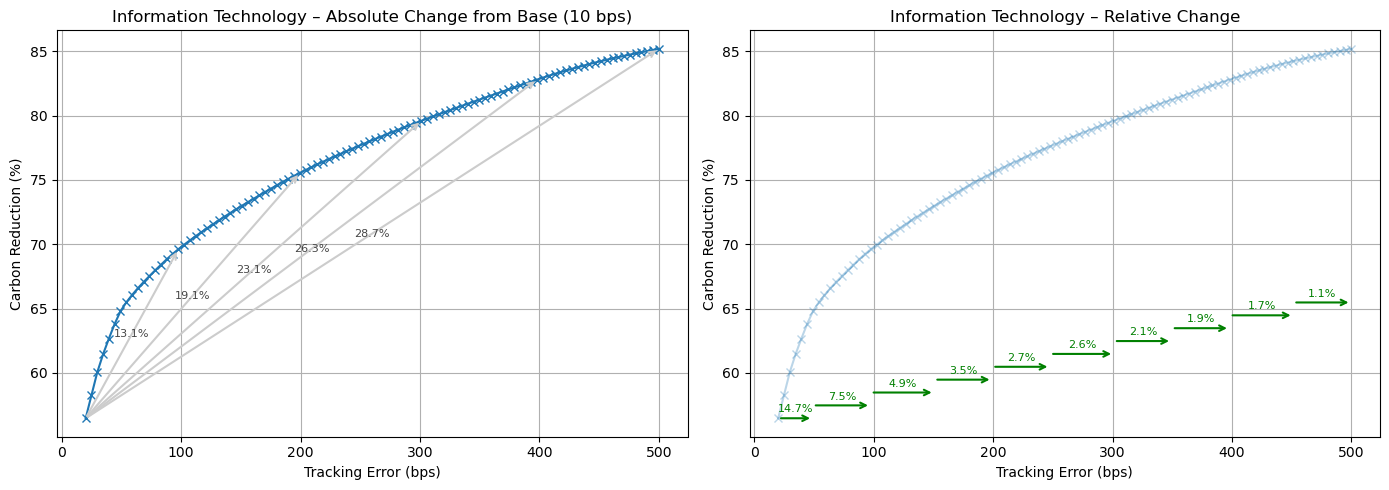

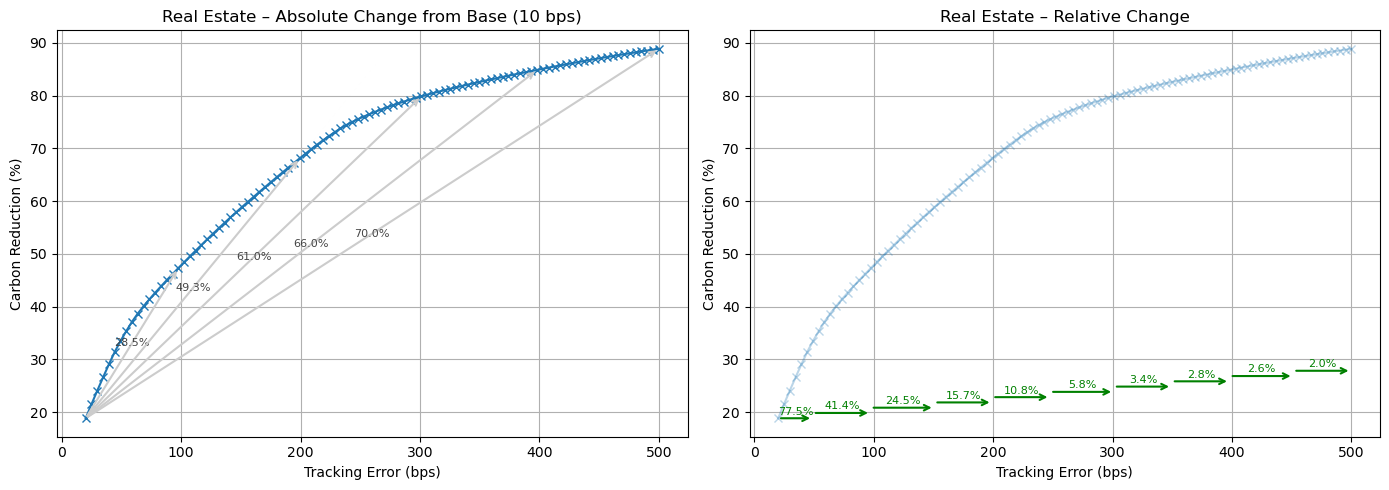

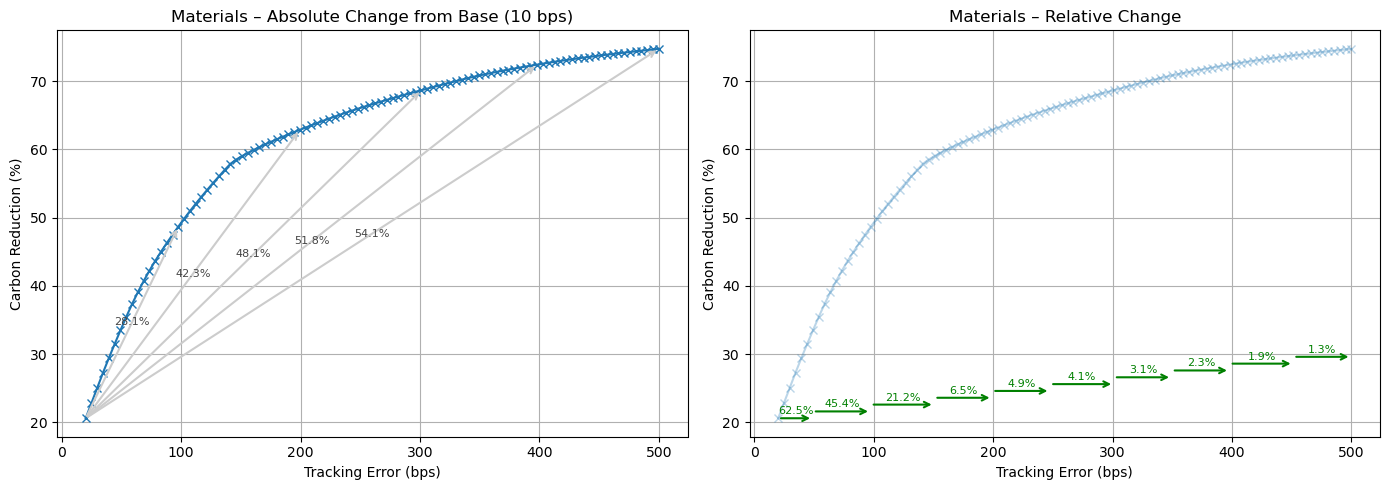

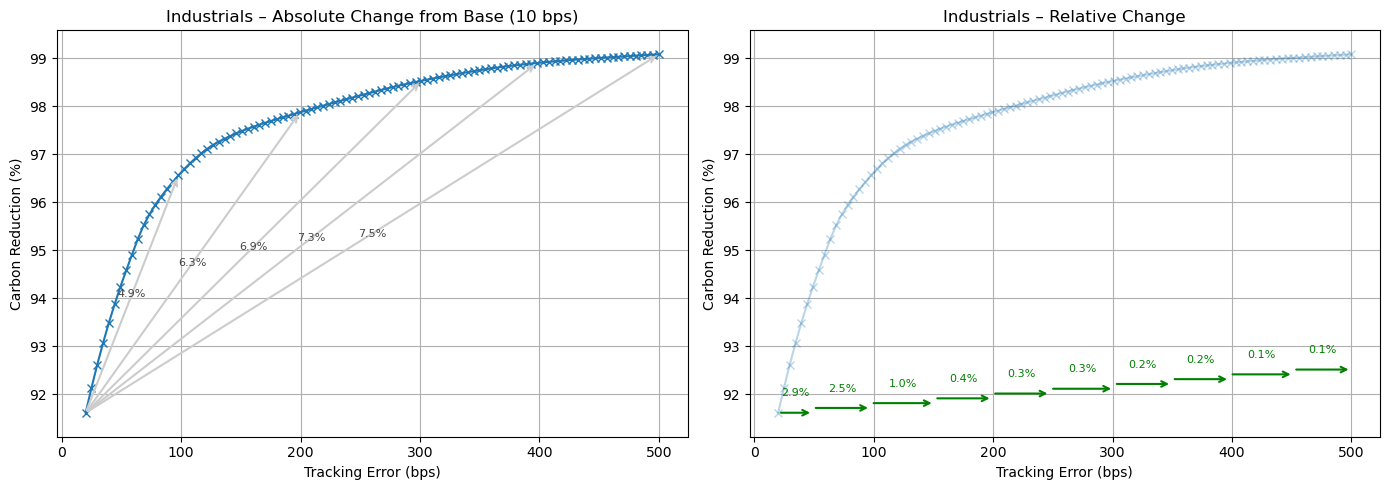

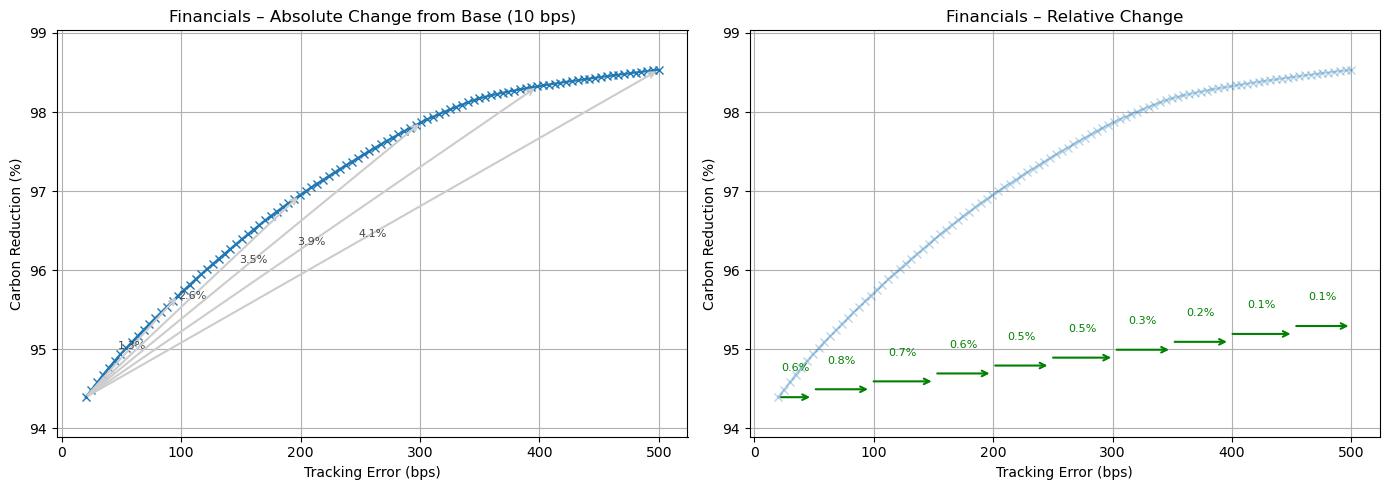

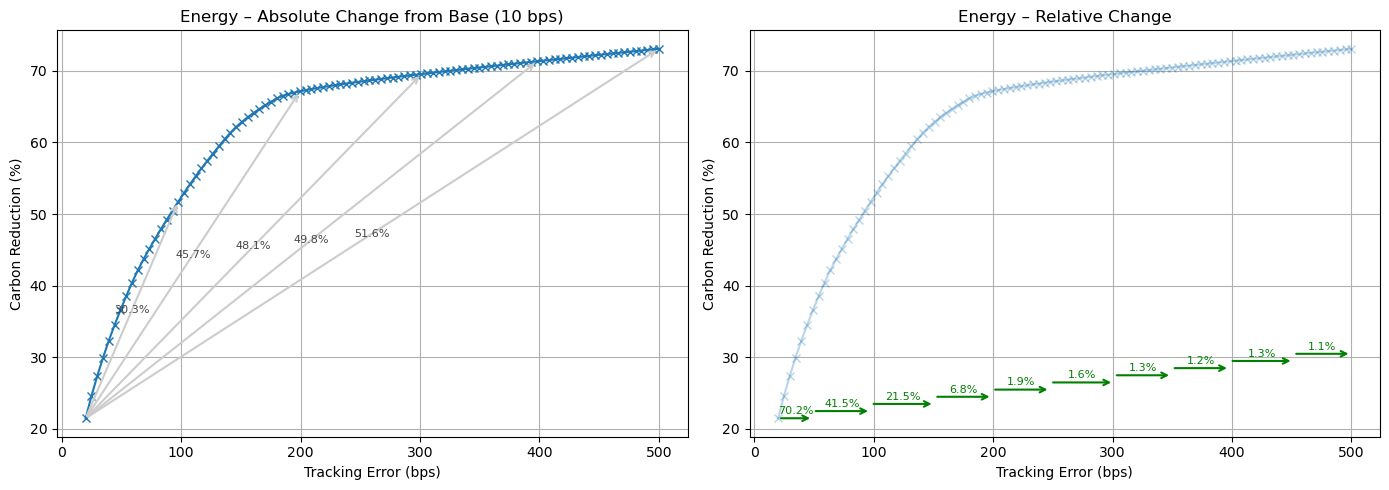

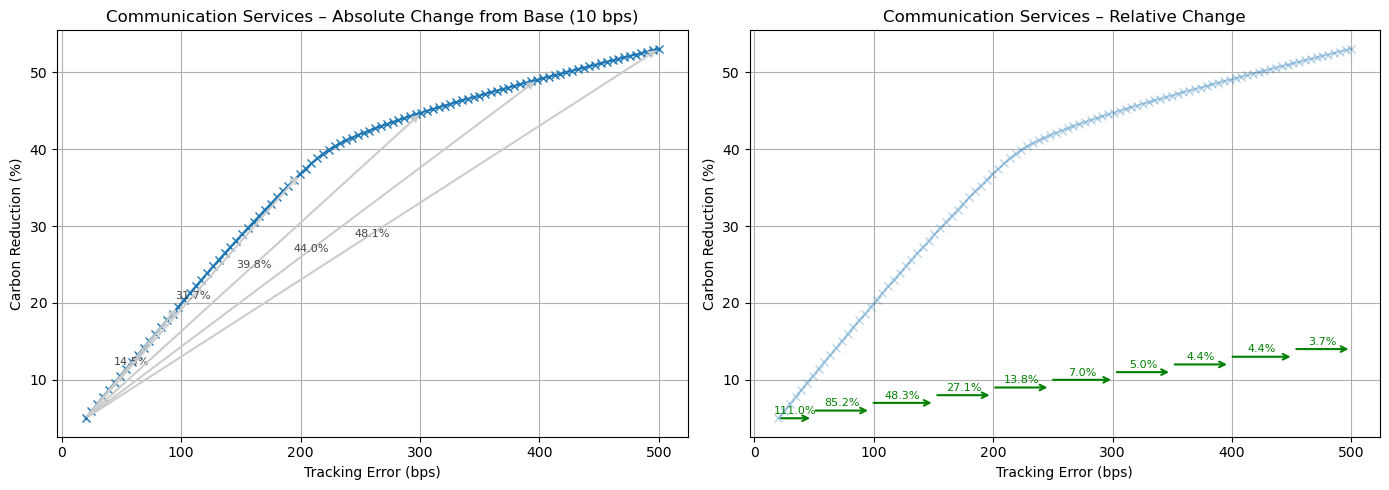

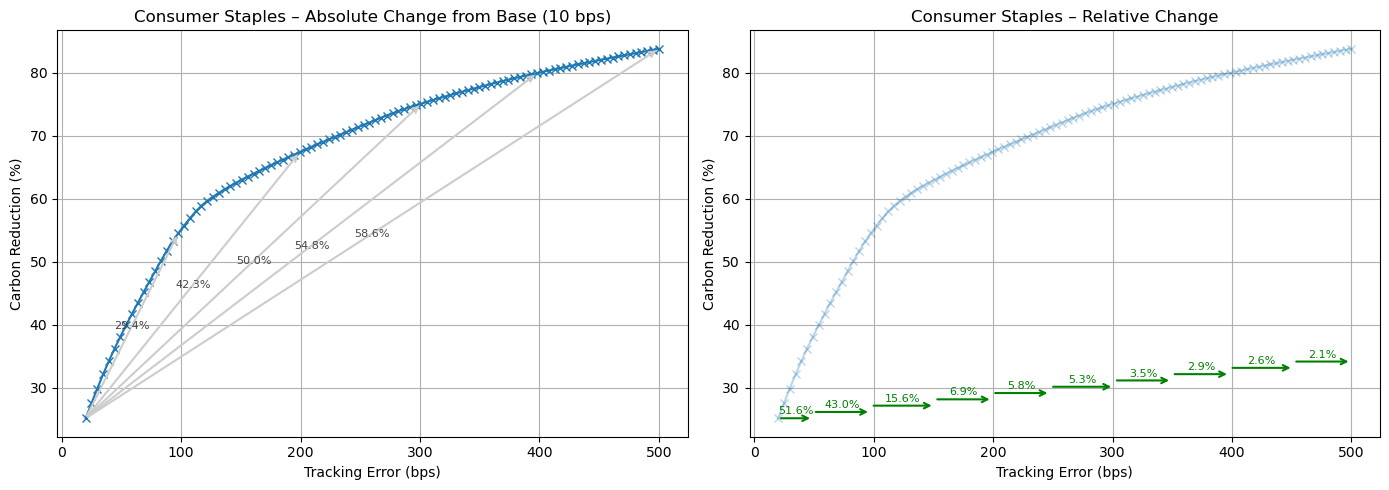

| Sector                 |   Num Features |   Rank |   Min_Eigval1 |   Min_Eigval2 |   Min_Eigval3 |   Min_Eigval4 |   Min_Eigval5 | Low Rank?   | Not PSD?   |
|------------------------|----------------|--------|---------------|---------------|---------------|---------------|---------------|-------------|------------|
| Communication Services |             22 |     22 |   4.89645e-05 |   6.95918e-05 |   0.000158415 |   0.000324683 |   0.000469213 | False       | False      |
| Consumer Discretionary |             52 |     24 |  -6.27257e-18 |  -5.10291e-18 |  -4.15191e-18 |  -2.91039e-18 |  -2.30768e-18 | True        | False      |
| Consumer Staples       |             37 |     24 |  -4.94994e-18 |  -2.23947e-18 |  -1.82351e-18 |  -1.21667e-18 |  -1.98333e-20 | True        | False      |
| Energy                 |             23 |     23 |   2.2278e-05  |   2.96038e-05 |   7.50102e-05 |   9.13723e-05 |   0.000236027 | False       | False      |
| Financials             |             7

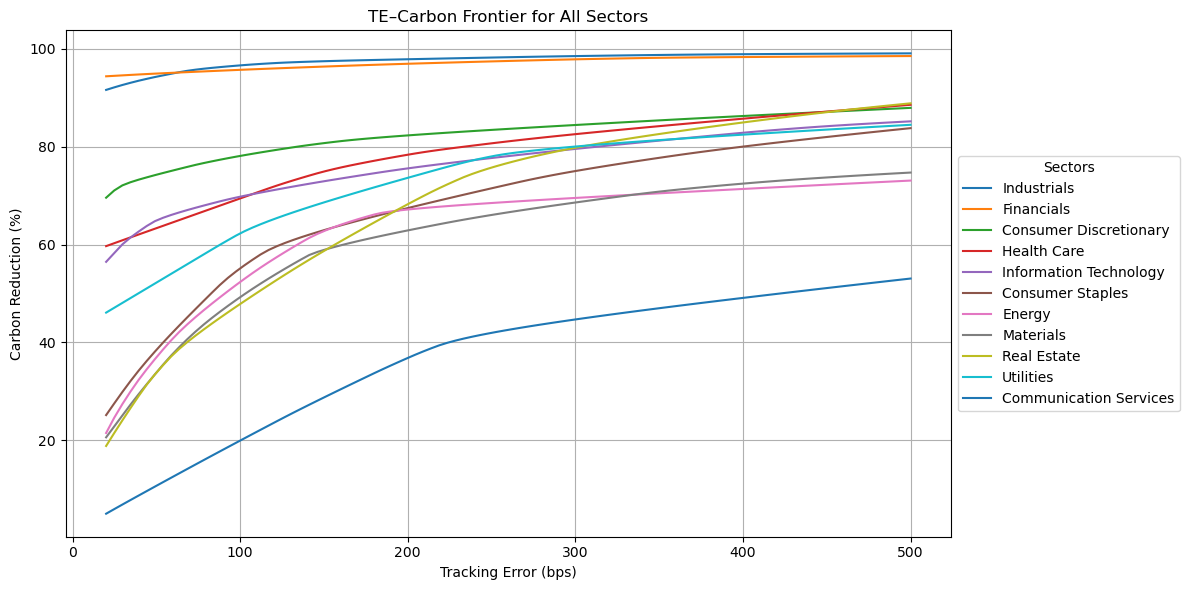

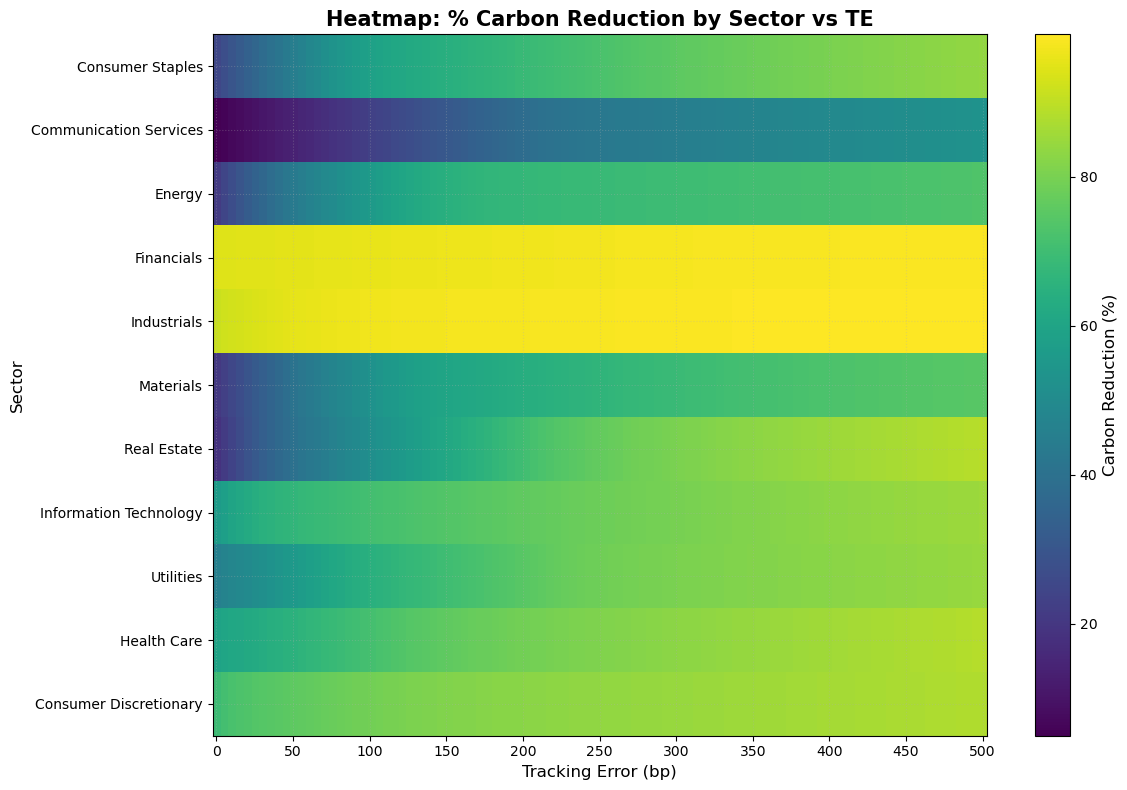

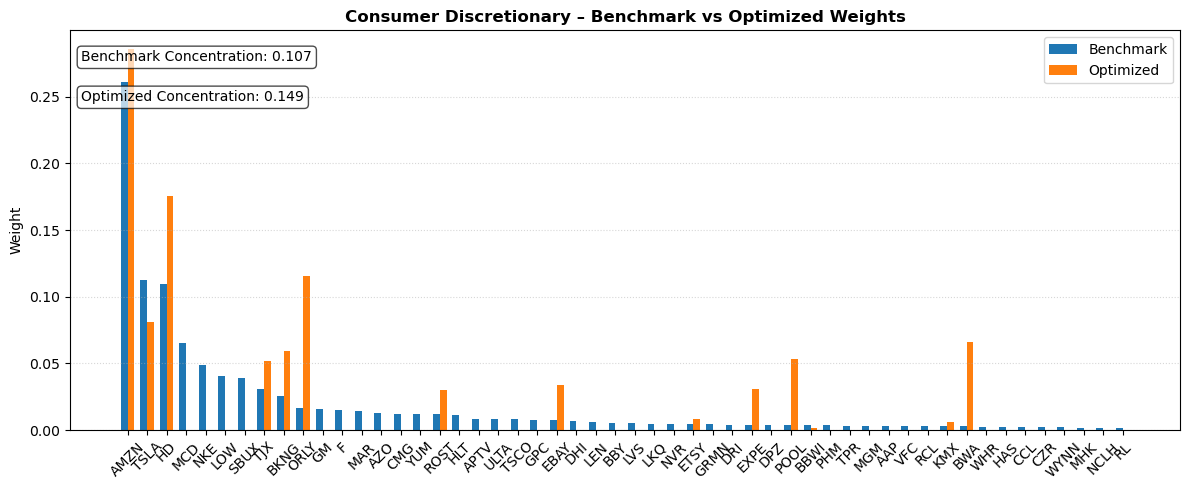

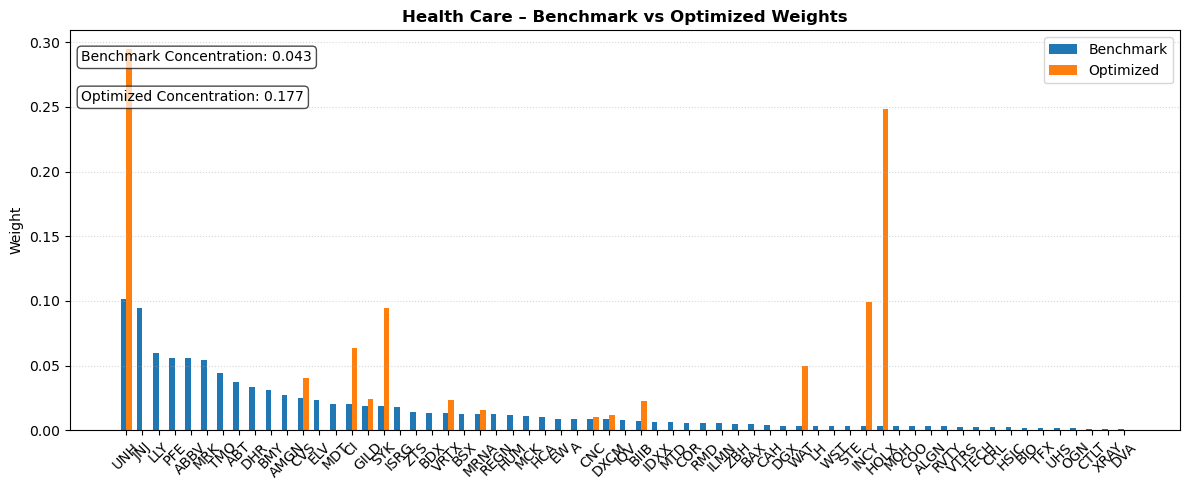

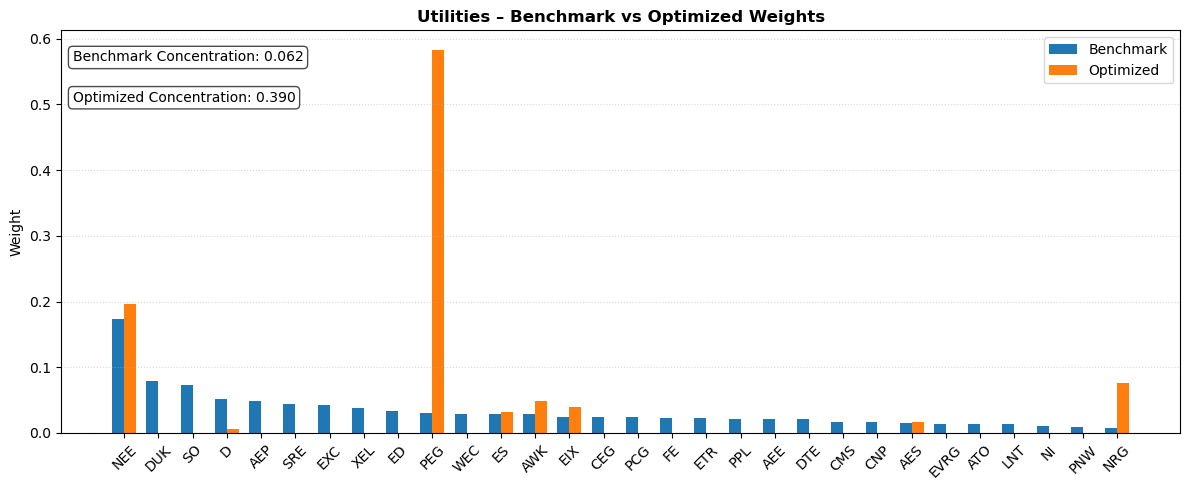

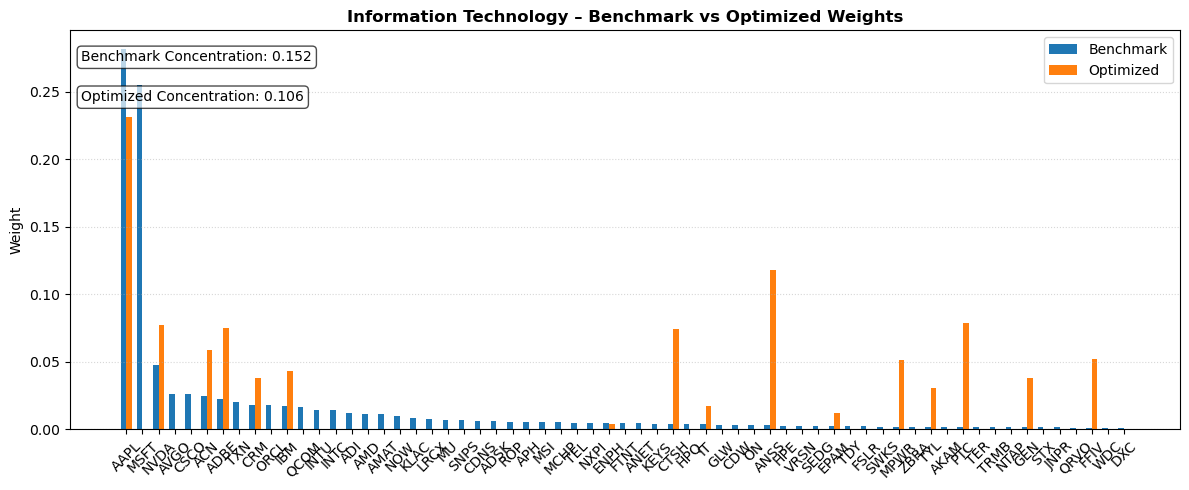

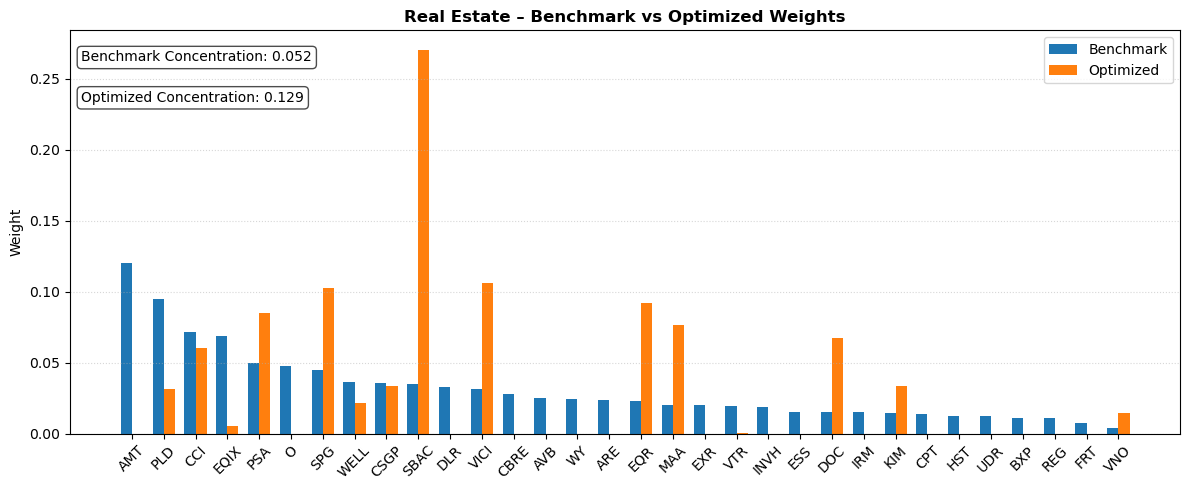

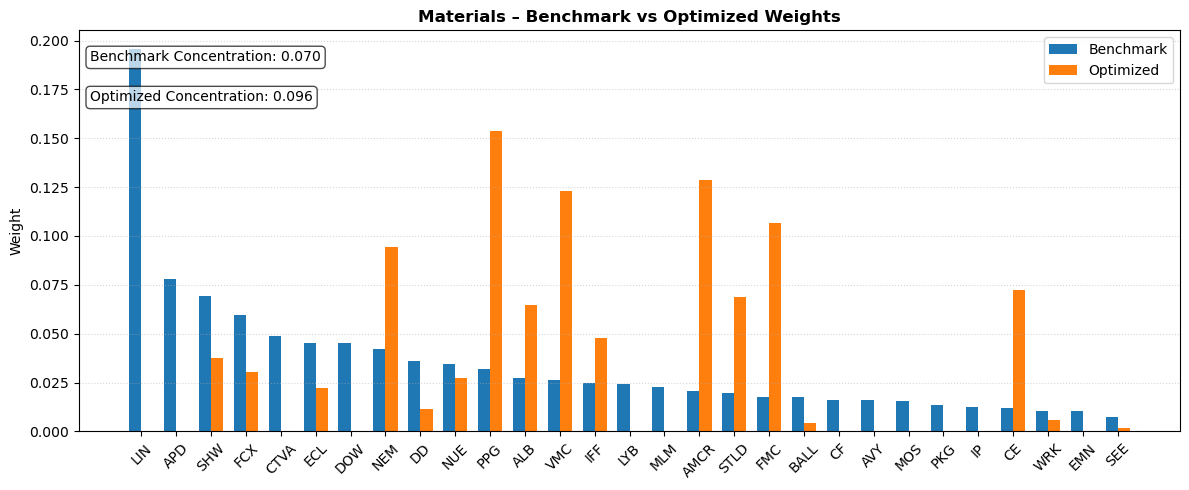

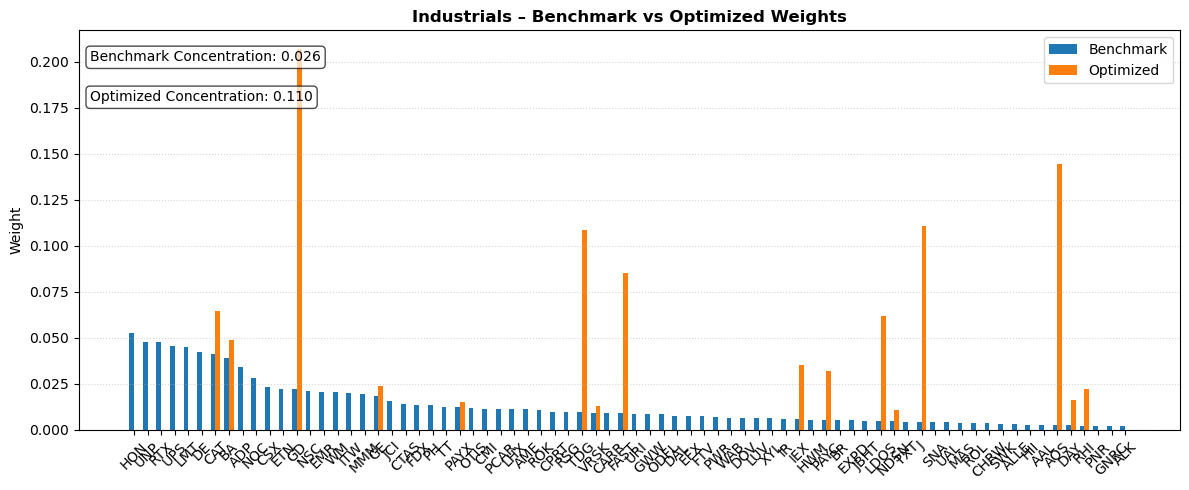

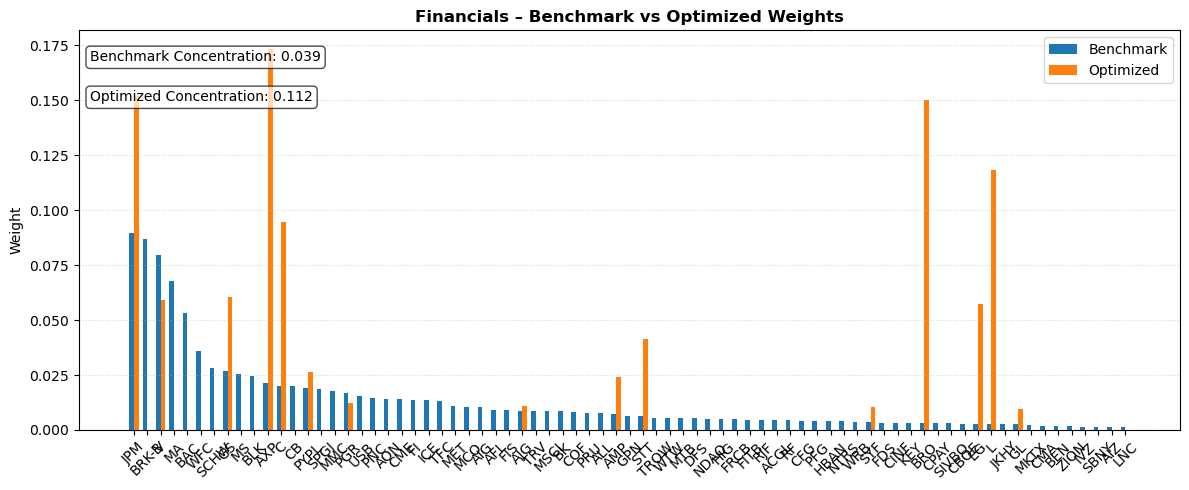

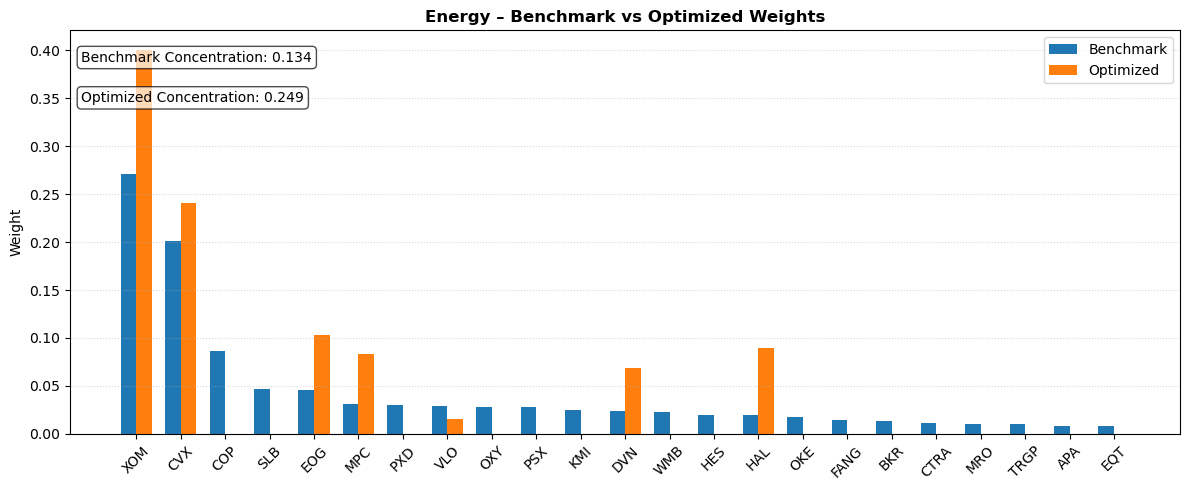

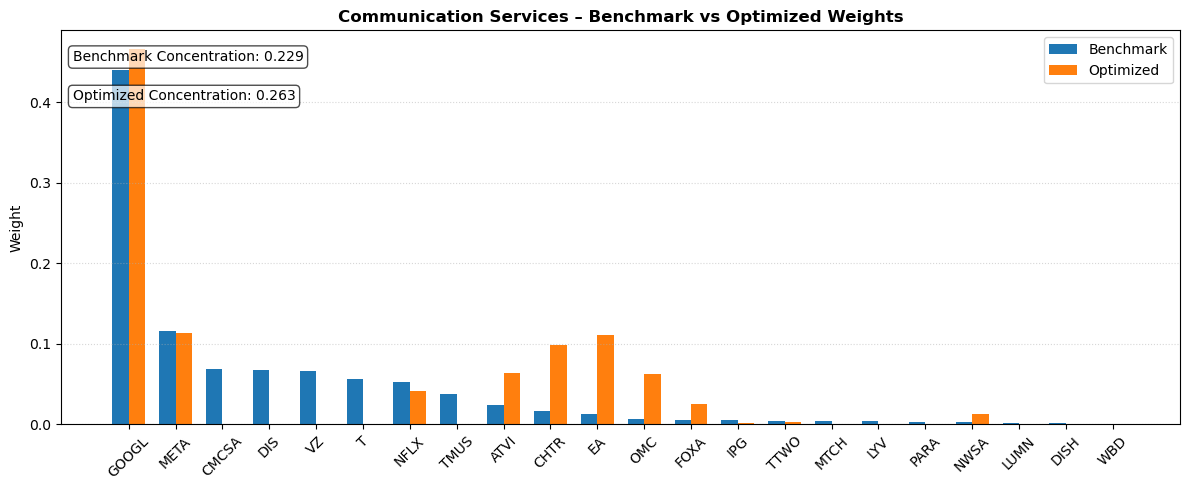

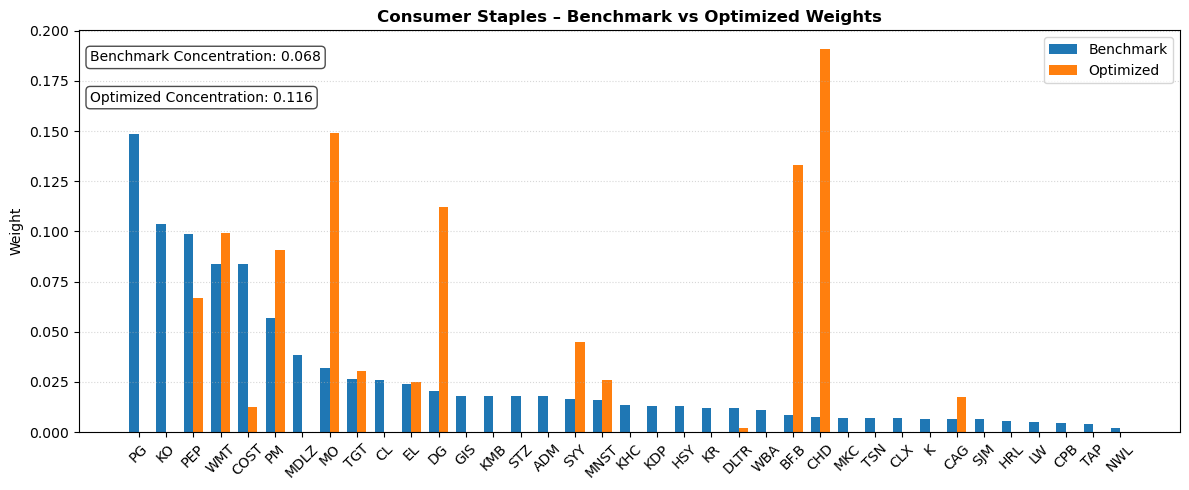

In [26]:
data = pd.read_excel("Data/dataset_comp_1222.xlsx")
diagnostics_raw = []
diagnostics_clipped = []

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negative eigenvalues
    return eigvecs @ np.diag(eigvals) @ eigvecs.T # reconstructing the covariance matrix in frobenius norm
# Raw Sigma from empirical returns
def sigma_raw_fn(R_clean):
    Sigma_sector = R_clean.cov()
    return Sigma_sector



sector_weights = {} 
optimal_portfolios = {}
diagnostics = []
reductions_raw = []

for sector_name in data['GICS Sector'].unique():
    sector = data.loc[data['GICS Sector'] == sector_name]



    # Benchmark weights (should sum to 1)
    w_b_sector = sector[['weight_in_sector']]
    assert np.isclose(w_b_sector.sum().values[0], 1.0), f"{sector_name}: weights don't sum to 1"

    # Carbon intensities
    c_sector = sector[['Carbon Intensity']]
    assert c_sector.isna().sum().values[0] == 0, f"{sector_name}: carbon data has NaNs"

    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()
    stock_labels = R_clean.columns
    Sigma_raw = sigma_raw_fn(R_clean)
    # Raw Sigma
    eigvals_raw = np.linalg.eigvalsh(Sigma_raw)
    rank_raw = np.linalg.matrix_rank(Sigma_raw)
    num_features = Sigma_raw.shape[1]
    smallest_eigs_raw = np.sort(eigvals_raw)[:5]
    
    Sigma_clipped = nearest_psd(Sigma_raw)
    Sigma_sector = Sigma_clipped

    

    diagnostics_raw.append({
        "Sector": sector_name,
        "Num Features": num_features,
        "Rank": rank_raw,
        "Min_Eigval1": smallest_eigs_raw[0],
        "Min_Eigval2": smallest_eigs_raw[1] if len(smallest_eigs_raw) > 1 else np.nan,
        "Min_Eigval3": smallest_eigs_raw[2] if len(smallest_eigs_raw) > 2 else np.nan,
        "Low Rank?": rank_raw < num_features,
        "Not PSD?": eigvals_raw.min() < -1e-6
    })

    # Clipped Sigma
    eigvals_clip = np.linalg.eigvalsh(Sigma_clipped)
    rank_clip = np.linalg.matrix_rank(Sigma_clipped)
    smallest_eigs_clip = np.sort(eigvals_clip)[:5]

    diagnostics_clipped.append({
        "Sector": sector_name,
        "Num Features": num_features,
        "Rank": rank_clip,
        "Min_Eigval1": smallest_eigs_clip[0],
        "Min_Eigval2": smallest_eigs_clip[1] if len(smallest_eigs_clip) > 1 else np.nan,
        "Min_Eigval3": smallest_eigs_clip[2] if len(smallest_eigs_clip) > 2 else np.nan,
        "Low Rank?": rank_clip < num_features,
        "Not PSD?": eigvals_clip.min() < -1e-6
    })

    eigvals = np.linalg.eigvalsh(Sigma_sector)
    rank = np.linalg.matrix_rank(Sigma_sector)
    num_features = Sigma_sector.shape[1]


    # Convert covariance matrix to correlation matrix
    stddev = np.sqrt(np.diag(Sigma_sector))
    corr_matrix = Sigma_sector / np.outer(stddev, stddev)
    

   

    # Inputs
    N = len(w_b_sector)
    w_b_vec = w_b_sector.values.flatten()
    c_vec = c_sector.values.flatten()
    
   
    sector_weights[sector_name] = {
    'weights_by_te': [],         # list of np.array
    'tracking_errors': [],
    'carbon_reductions': [],
    'w_b_vec': w_b_vec,
    'stock_labels': list(stock_labels),  
    'relative_deltas':[]
    }
    # TE caps and results
    te_caps_annual = np.linspace(0.002, 0.05, 100)  # up to 10% TE
    tracking_errors = []
    carbon_reductions = []
    smallest_eigs = np.sort(eigvals)[:5]

    for te_annual in te_caps_annual:
        # Convert to monthly variance
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2

        # Optimization
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, psd_wrap(Sigma_sector))
        constraints = [
            tracking_error <= te_cap_var_monthly,
            cp.sum(w) == 1,
            w >= 0,
        ]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)
        # Check if solution is usable
        if prob.status in ["optimal", "optimal_inaccurate"] and w.value is not None:
            pass
        else:
            print("Optimization failed or unreliable:", prob.status)
        w_opt = w.value
        if w_opt is not None:
            # Ex-post tracking error (annualized)
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            tracking_errors.append(te_real * 10000)  # in bps

            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
            carbon_reductions.append(reduction_pct)
            sector_weights[sector_name]['weights_by_te'].append(w_opt)
            sector_weights[sector_name]['tracking_errors'].append(te_real * 10000)
            sector_weights[sector_name]['carbon_reductions'].append(reduction_pct)



   
            if np.round(te_annual, 3) == 0.02:
                optimal_portfolios[sector_name] = {
                "w_b_vec": w_b_vec,
                "w_opt": w_opt,
                "stock_labels": stock_labels}
                # w_b_vec is the benchmark weights vector
                # w_opt is the optimised weights vector
                # stock labels is the companies name
                benchmark_df =  pd.DataFrame({"w": w_b_vec, "symbol": stock_labels})
                optimised_df = pd.DataFrame({"w": w_opt, "symbol": stock_labels})
                benchmark_df.sort_values(by = 'w', ascending=False, inplace=True)
                optimised_df.sort_values(by = 'w', ascending=False, inplace=True)

                # Count if the leading asset by portfolio weight in the optimized allocation aligns with that of the benchmark portfolio.
                optimal_portfolios[sector_name].update({'count_1' : 1 if benchmark_df['symbol'].values[0] == optimised_df['symbol'].values[0] else 0})
                # Count how many assets coincide by comparing the three assets with the highest weight in the optimized allocation coincide with the top three weighted consitutents of the benchmark portfolio.
                optimal_portfolios[sector_name].update({'count_3' : len(set(benchmark_df['symbol'].values[:3]).intersection(set(optimised_df['symbol'].values[:3])))})
                # Count how many assets coincide by comparing the five assets with the highest weight in the optimized allocation coincide with the top five weighted consitutents of the benchmark portfolio.
                optimal_portfolios[sector_name].update({'count_5' : len(set(benchmark_df['symbol'].values[:5]).intersection(set(optimised_df['symbol'].values[:5])))})
                # Count how many assets coincide by comparing the ten assets with the highest weight in the optimized allocation coincide with the top ten weighted consitutents of the benchmark portfolio.
                optimal_portfolios[sector_name].update({'count_10' : len(set(benchmark_df['symbol'].values[:10]).intersection(set(optimised_df['symbol'].values[:10])))})

                # Count stocks with non-zero weights in the optimised portfolio:
                optimal_portfolios[sector_name].update({'zero_stocks': len(optimised_df.loc[optimised_df['w'] < 1e-04])})
                optimal_portfolios[sector_name].update({'zero_stocks_%': len(optimised_df.loc[optimised_df['w'] < 1e-04])/len(optimised_df)})
                
    # Define the tracking error breakpoints (in bps)
    absolute_te_points = [100, 200, 300, 400, 500]
    relative_te_points = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

    tracking_errors_np = np.array(tracking_errors)
    carbon_reductions_np = np.array(carbon_reductions)
    # === Carbon Summary Diagnostics ===
    if len(carbon_reductions_np) > 0:
        start_reduction = carbon_reductions_np[0]
        end_reduction = carbon_reductions_np[-1]
        total_gain = end_reduction - start_reduction

        idx_2pct = np.argmin(np.abs(tracking_errors_np - 200))  # ~2% TE = 200bps
        reduction_at_2pct = carbon_reductions_np[idx_2pct]

        diagnostics.append({
            "Sector": sector_name,
            "Num Features": num_features,
            "Rank": rank,
            "Min_Eigval1": smallest_eigs[0],
            "Min_Eigval2": smallest_eigs[1] if len(smallest_eigs) > 1 else np.nan,
            "Min_Eigval3": smallest_eigs[2] if len(smallest_eigs) > 2 else np.nan,
            "Min_Eigval4": smallest_eigs[3] if len(smallest_eigs) > 3 else np.nan,
            "Min_Eigval5": smallest_eigs[4] if len(smallest_eigs) > 4 else np.nan,
            "Low Rank?": rank < num_features,
            "Not PSD?": eigvals.min() < -1e-6,
        })
        reductions_raw.append({
            "Sector": sector_name,
            "Start Reduction (%)": round(start_reduction, 2),
            "End Reduction (%)": round(end_reduction, 2),
            "Gain (%)": round(total_gain, 2),
            "Reduction @2% TE (%)": round(reduction_at_2pct, 2)})
    plot_te_carbon_by_sector(tracking_errors=tracking_errors, carbon_reductions=carbon_reductions, tracking_errors_np=tracking_errors_np, absolute_te_points=absolute_te_points, sector_name=sector_name, sector_weights=sector_weights, relative_te_points=relative_te_points)

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df = diagnostics_df.sort_values("Sector")  # optional
print(tabulate(diagnostics_df, headers='keys', tablefmt='github', showindex=False))
print()
reductions_raw_df = pd.DataFrame(reductions_raw)
reductions_raw_df = reductions_raw_df.sort_values("Gain (%)", ascending=False)  # optional
print(tabulate(reductions_raw_df, headers='keys', tablefmt='github', showindex=False))

# print("Before clipping & reconstructing matrix:")
# diagnostics_raw_df = pd.DataFrame(diagnostics_raw)
# diagnostics_raw_df = diagnostics_raw_df.sort_values("Sector")  # optional

# print(tabulate(diagnostics_raw_df, headers='keys', tablefmt='github', showindex=False))

# print("After Clipping & reconstructing matrix:")
# diagnostics_clipped_df = pd.DataFrame(diagnostics_clipped)
# diagnostics_clipped_df = diagnostics_clipped_df.sort_values("Sector")  # optional

# print(tabulate(diagnostics_clipped_df, headers='keys', tablefmt='github', showindex=False))

# Custom sector order
ordered_sectors = [
    "Industrials",
    "Financials",
    "Consumer Discretionary",
    "Health Care",
    "Information Technology",
    "Consumer Staples",
    "Energy",
    "Materials",
    "Real Estate",
    "Utilities",
    "Communication Services"
]

plt.figure(figsize=(12, 6))  # Wider figure helps with spacing

for sector_name in ordered_sectors:
    if sector_name in sector_weights:
        metrics = sector_weights[sector_name]
        plt.plot(metrics['tracking_errors'], metrics['carbon_reductions'], label=sector_name)

plt.xlabel('Tracking Error (bps)')
plt.ylabel('Carbon Reduction (%)')
plt.title('TE–Carbon Frontier for All Sectors')

# Legend outside right
plt.legend(title="Sectors", loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()  # Adjust layout to fit legend
plt.show()


plot_te_carbon_heatmap(sector_weights=sector_weights, te_caps_annual=te_caps_annual)

for sector_name, data in optimal_portfolios.items():
    plot_origin_vs_opt_weights_comparison(
        data["w_b_vec"],
        data["w_opt"],
        data["stock_labels"],
        sector_name=sector_name,
        weight_comp_bool=True
    )

# TE - CARBON FRONTIERS WITH COVARIANCE REGULARIZATION
Ledoit-Wolf shrinkage + clipping eigenvalues + λI regularization:

Asserting that the sector order between log returns matrix and df is the same True


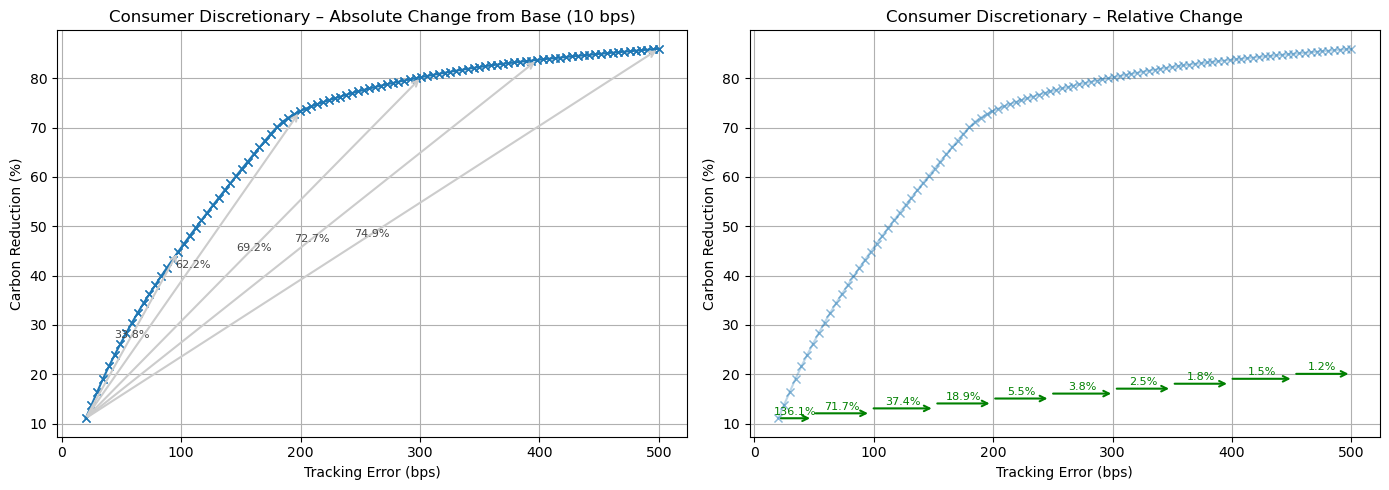

Asserting that the sector order between log returns matrix and df is the same True


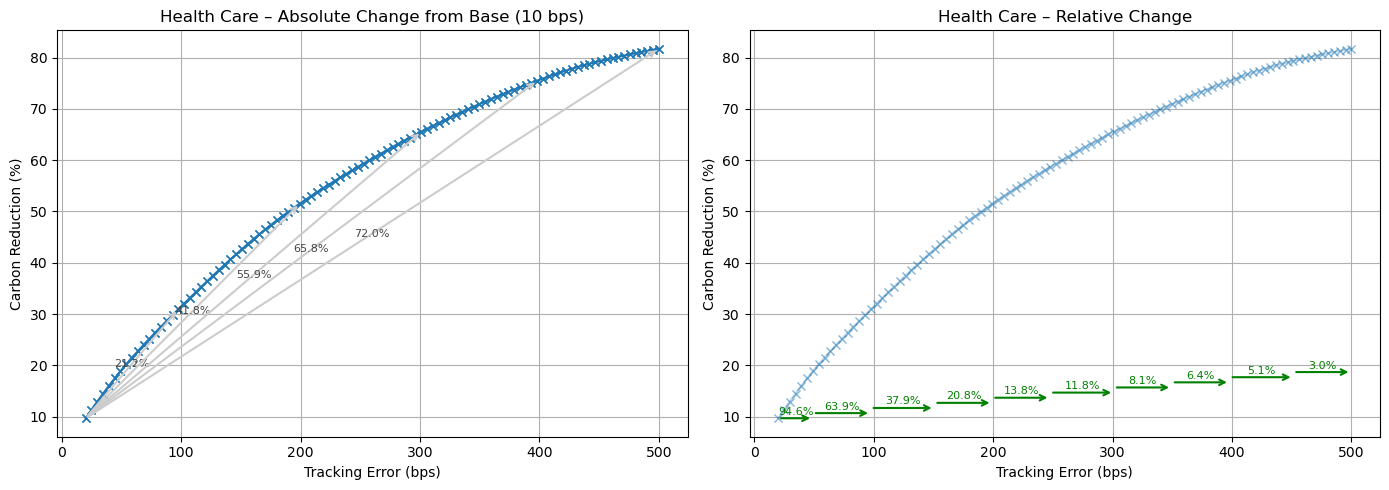

Asserting that the sector order between log returns matrix and df is the same True


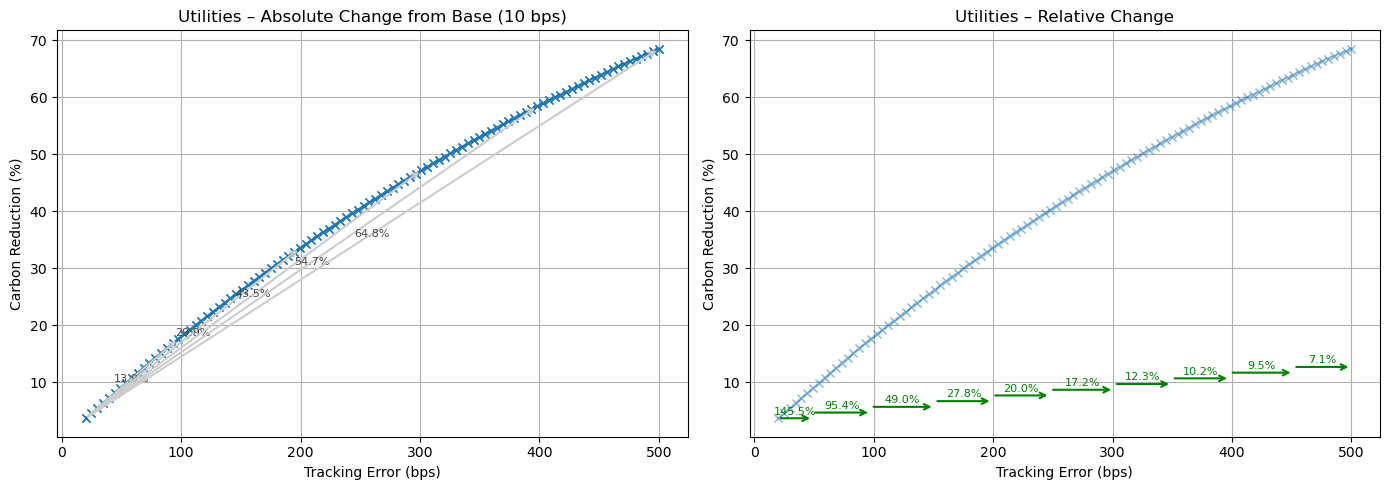

Asserting that the sector order between log returns matrix and df is the same True


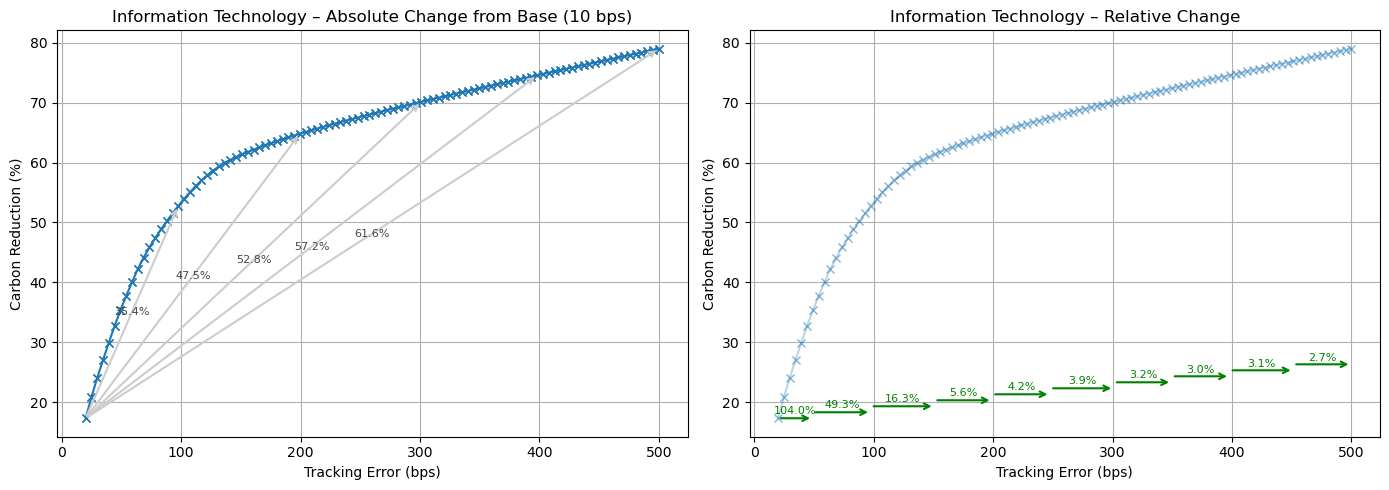

Asserting that the sector order between log returns matrix and df is the same True


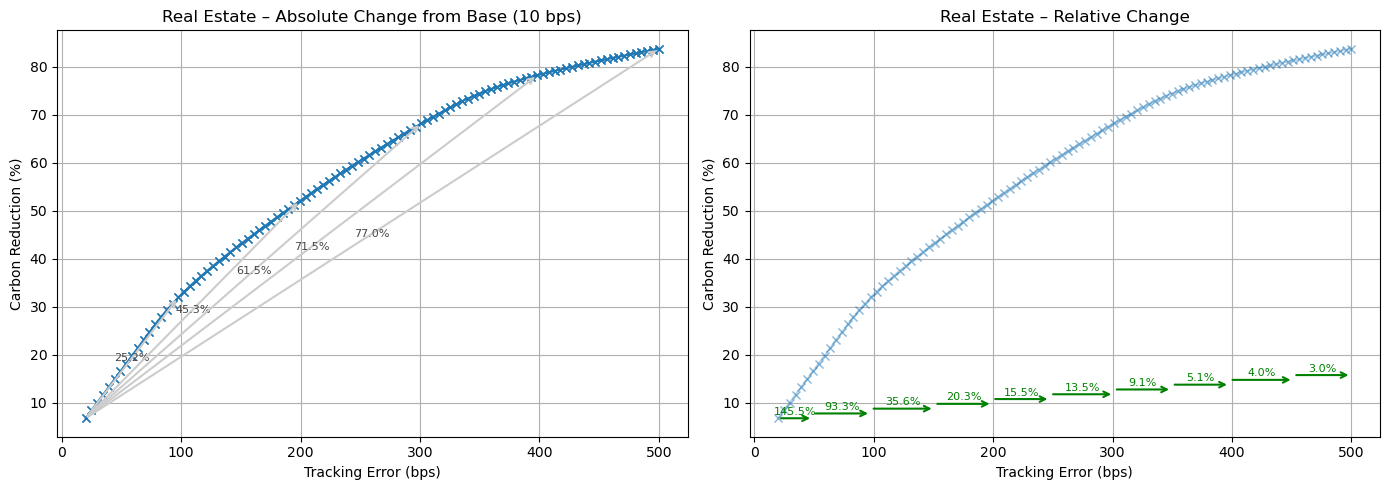

Asserting that the sector order between log returns matrix and df is the same True


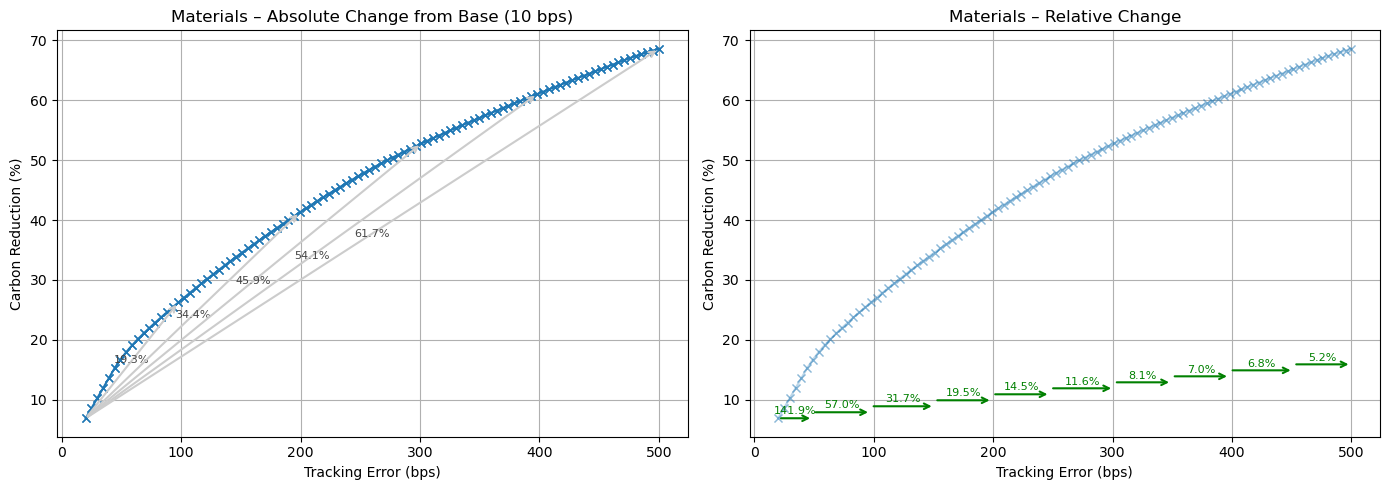

Asserting that the sector order between log returns matrix and df is the same True


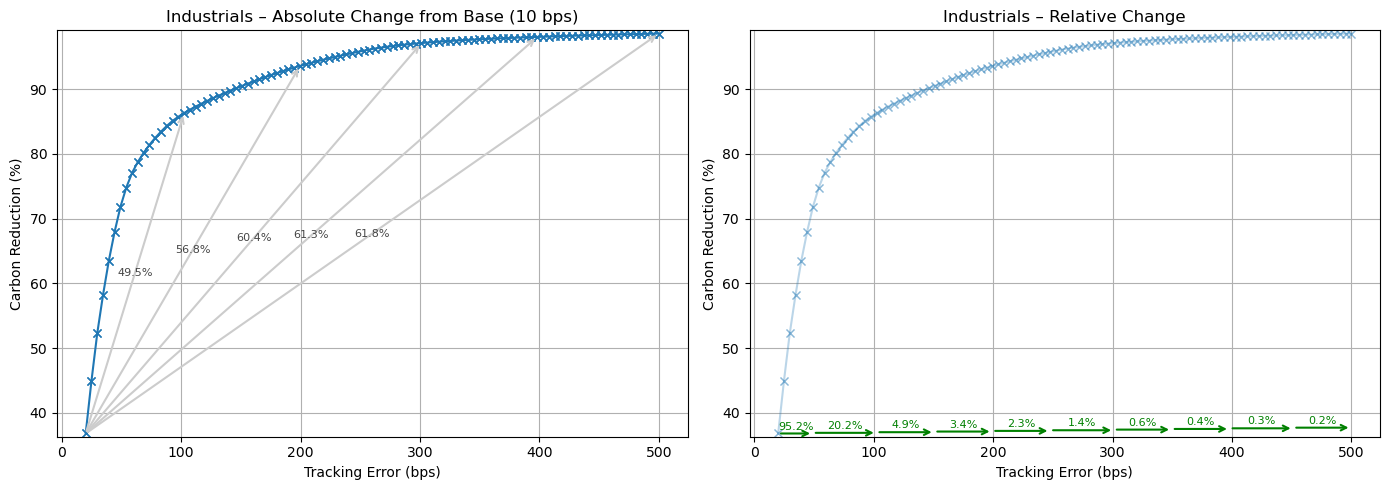

Asserting that the sector order between log returns matrix and df is the same True


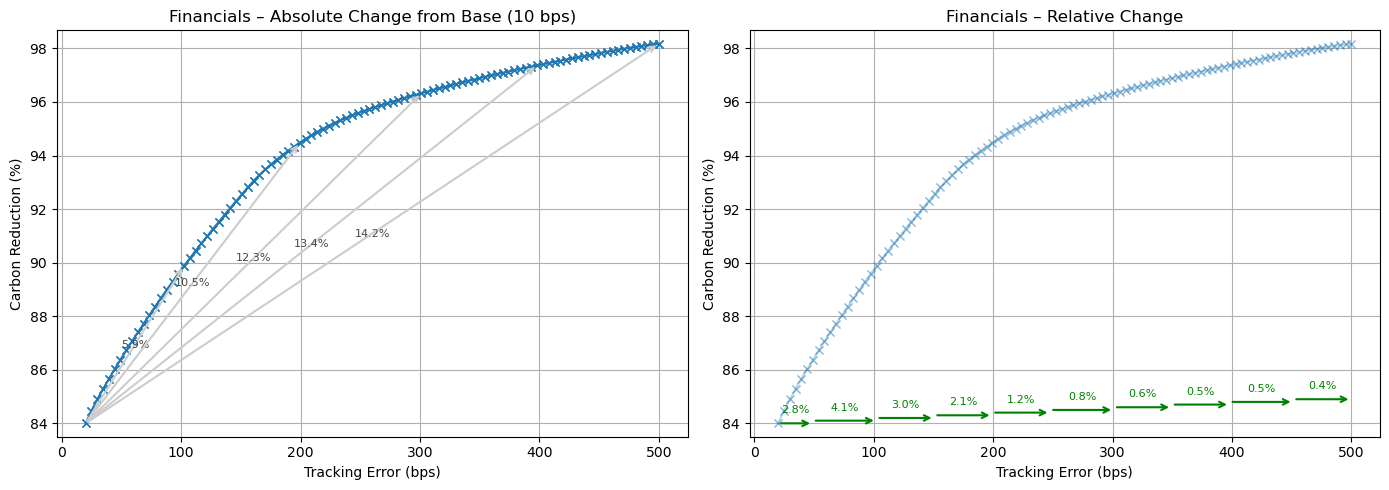

Asserting that the sector order between log returns matrix and df is the same True


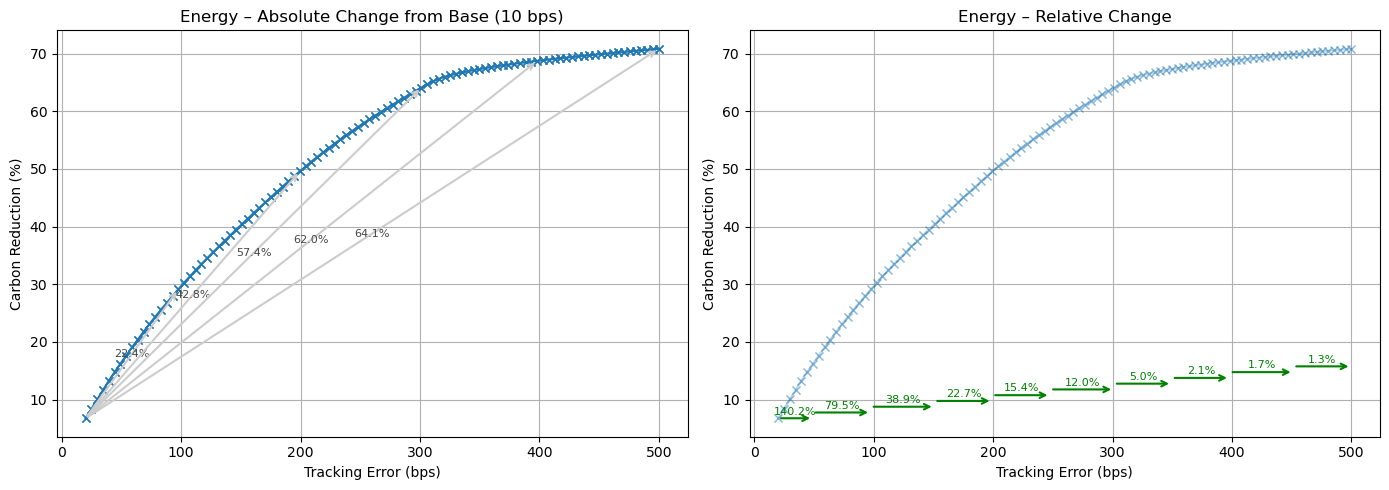

Asserting that the sector order between log returns matrix and df is the same True


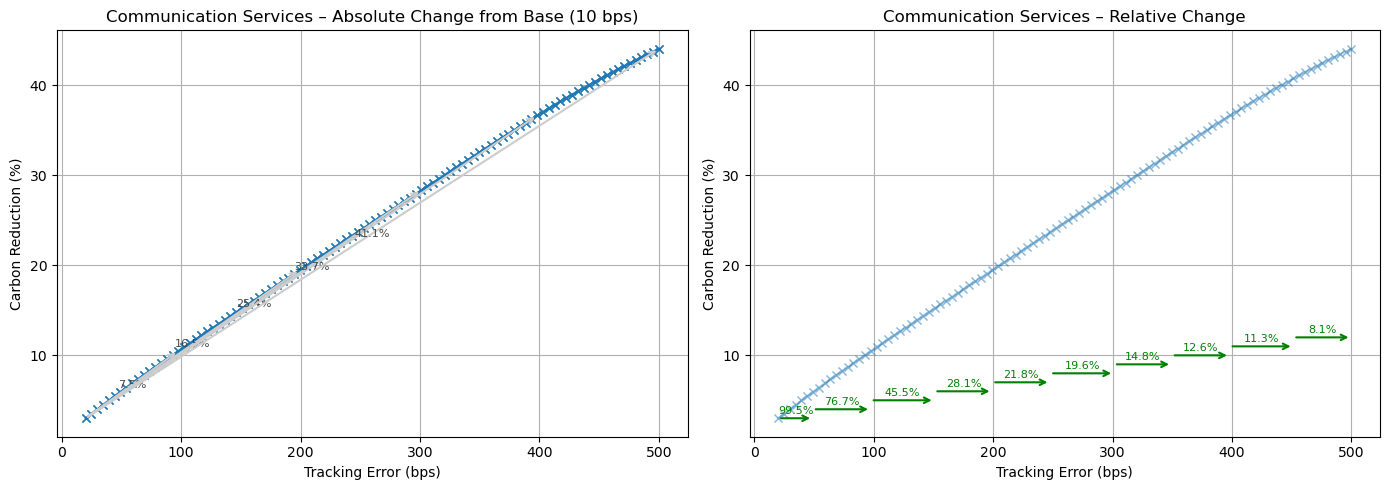

Asserting that the sector order between log returns matrix and df is the same True


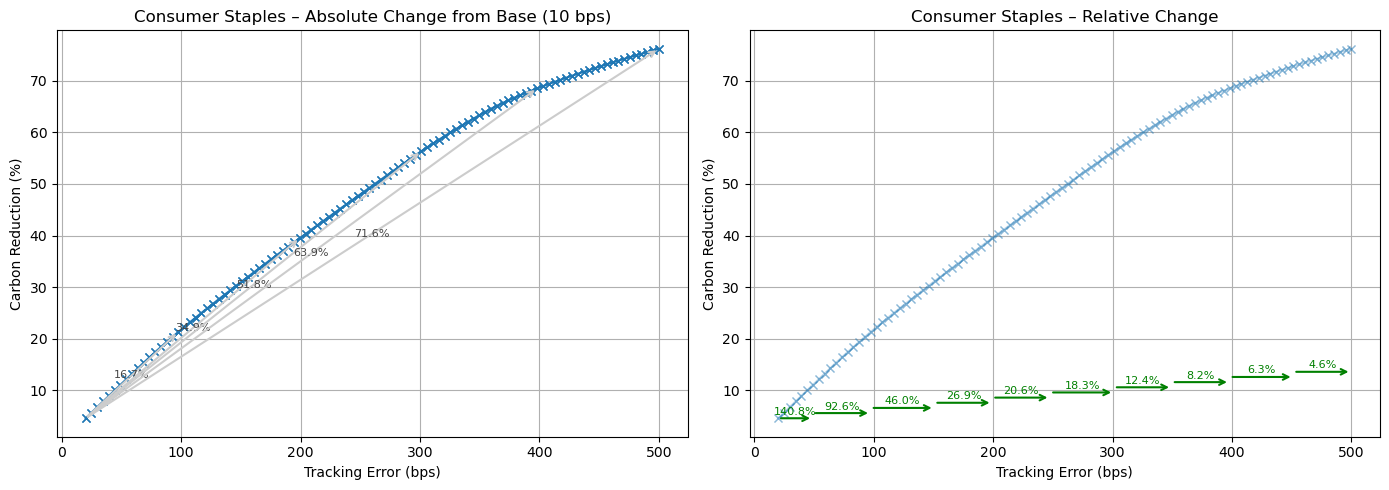

| Sector                 |   Num Features |   Rank |   Min_Eigval1 |   Min_Eigval2 |   Min_Eigval3 |   Min_Eigval4 |   Min_Eigval5 | Low Rank?   | Not PSD?   |   Start Reduction (%) |   End Reduction (%) |   Gain (%) |   Reduction @2% TE (%) |   Shrinkage Alpha |
|------------------------|----------------|--------|---------------|---------------|---------------|---------------|---------------|-------------|------------|-----------------------|---------------------|------------|------------------------|-------------------|
| Communication Services |             22 |     22 |   0.0041907   |   0.00420315  |   0.00425675  |   0.00435709  |   0.00444431  | False       | False      |                  2.96 |               44.08 |      41.11 |                  19.47 |             0.371 |
| Consumer Discretionary |             52 |     52 |   0.00233388  |   0.00233388  |   0.00233388  |   0.00233388  |   0.00233388  | False       | False      |                 11.07 |               85.98 |   

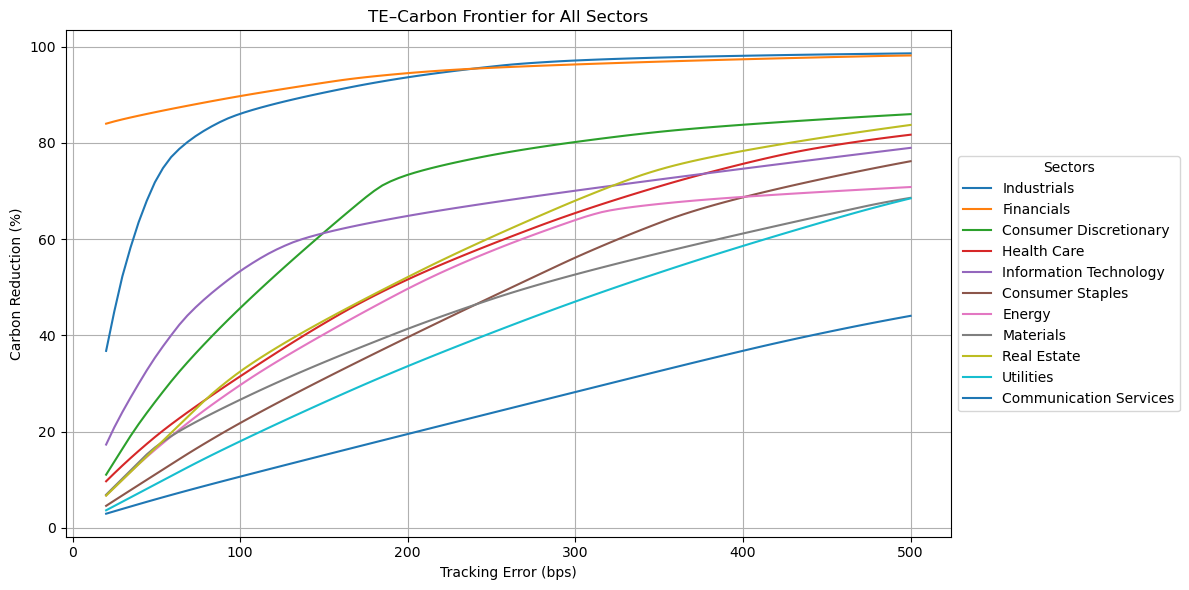

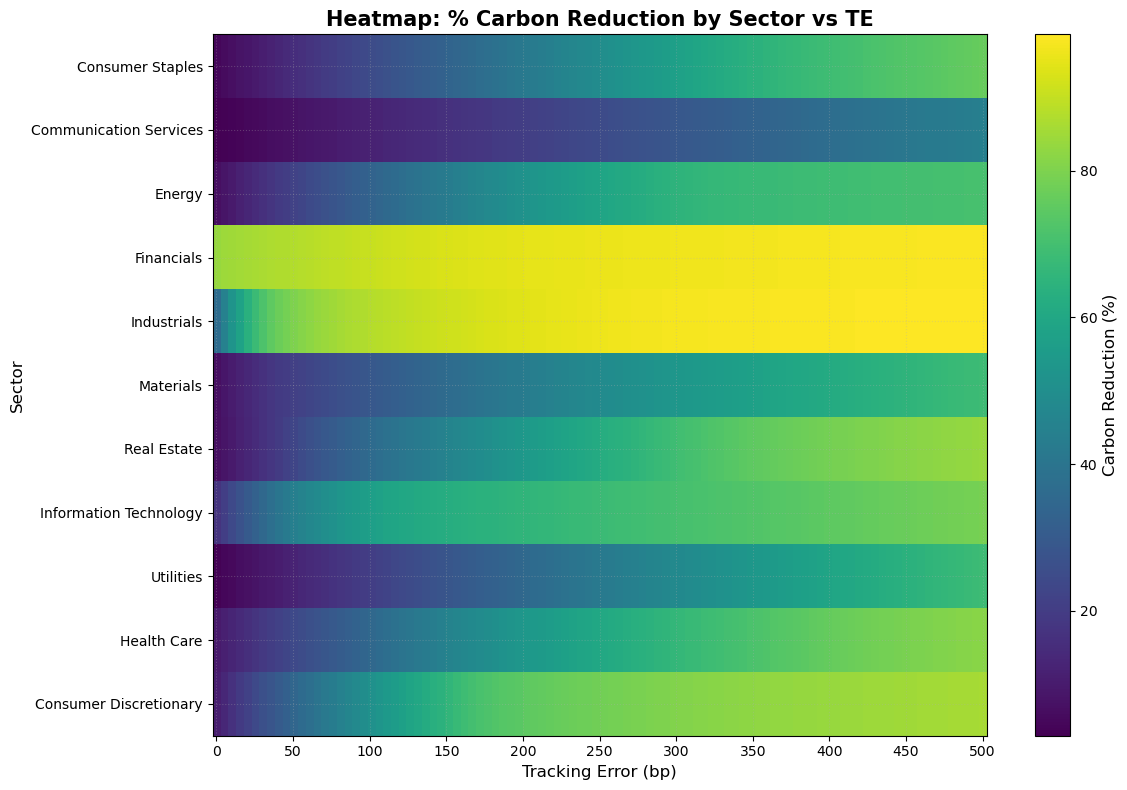

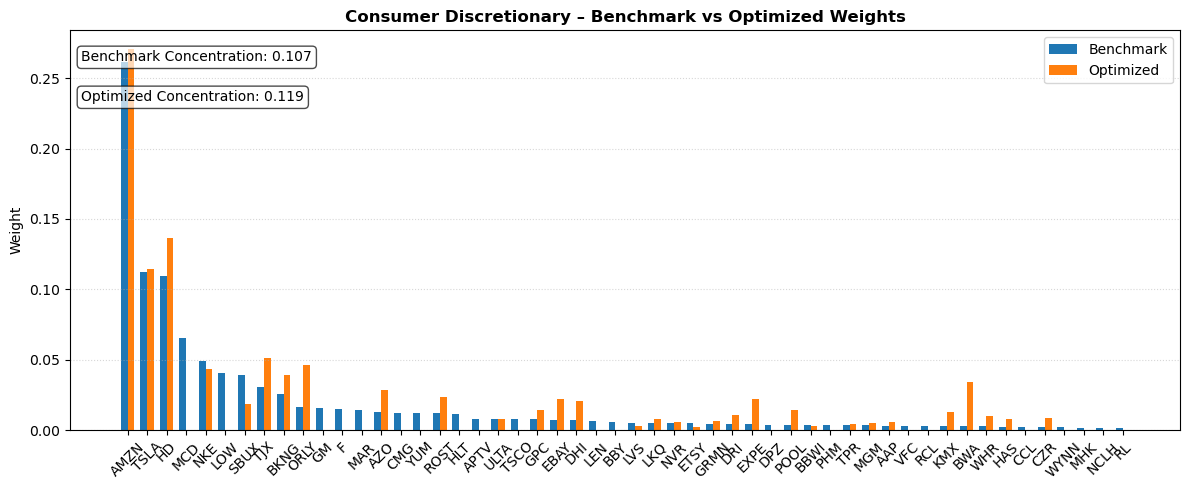

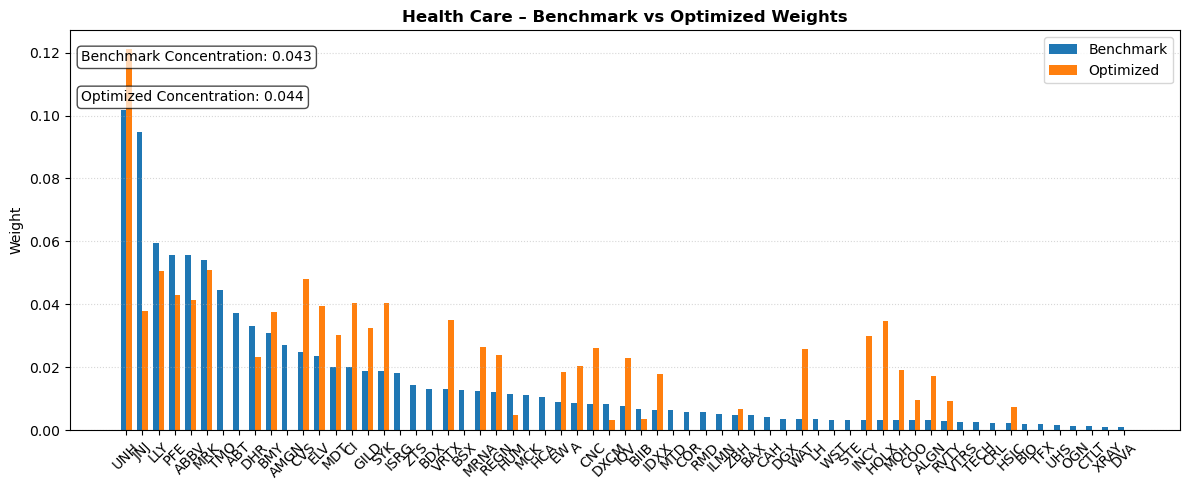

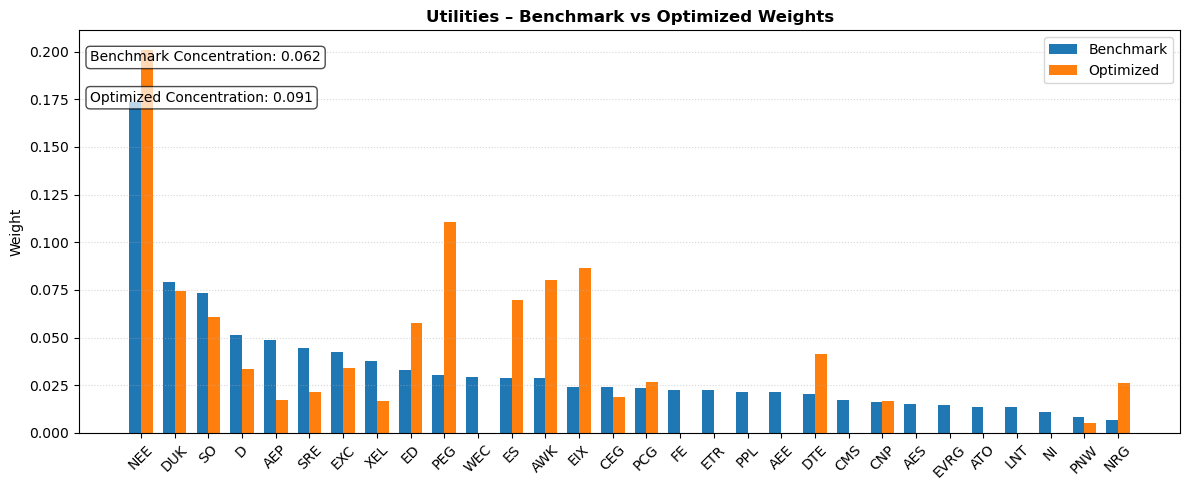

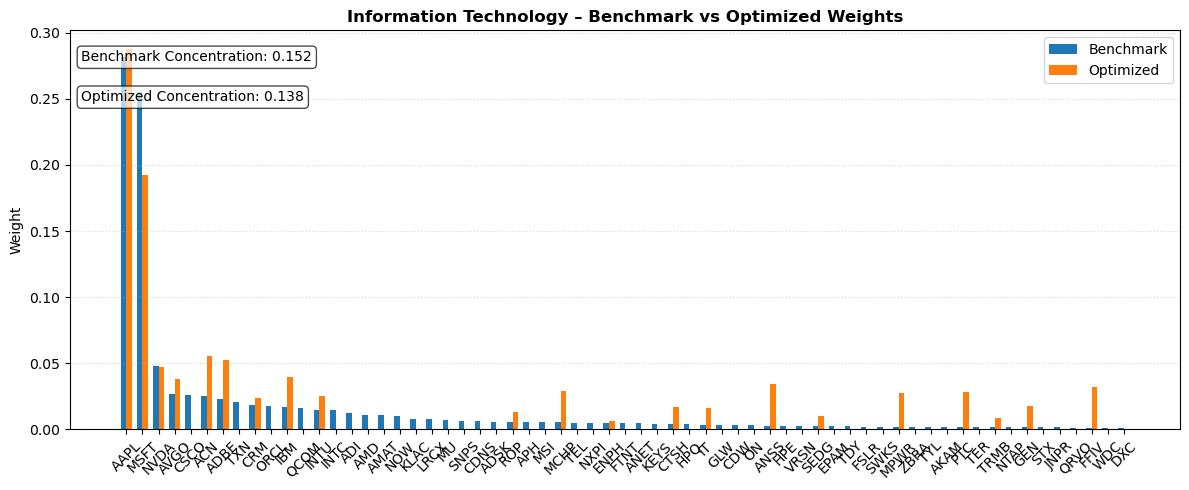

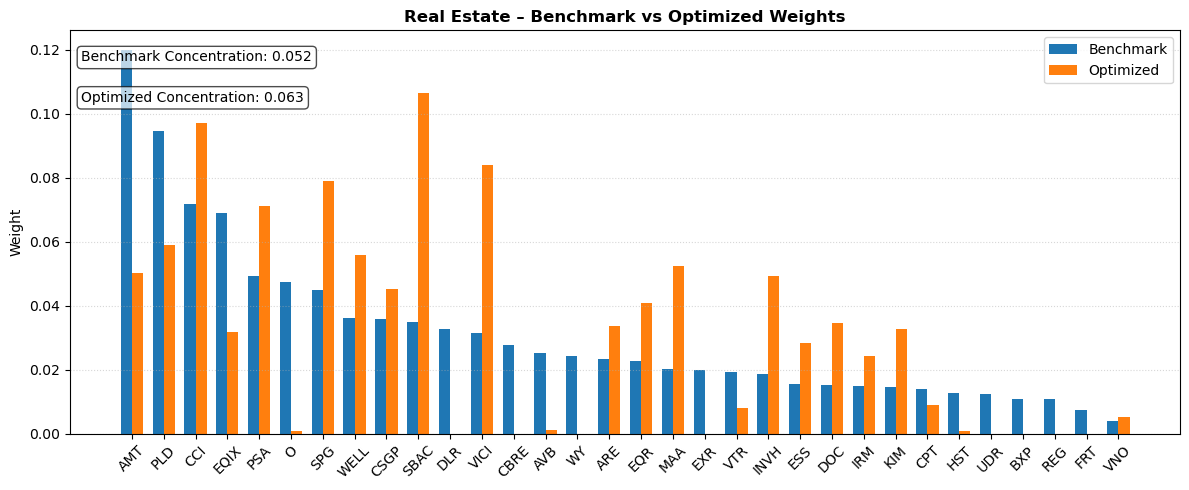

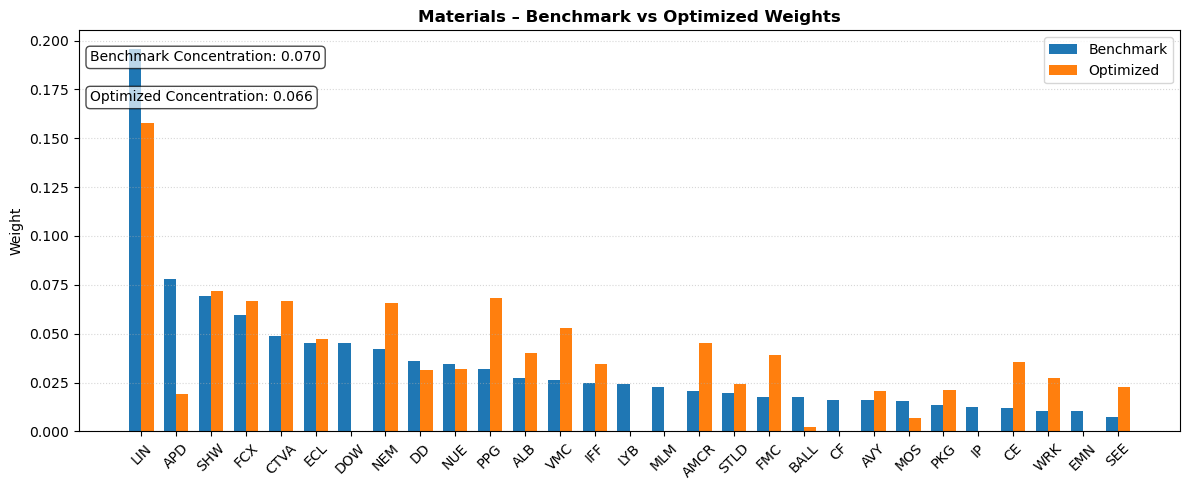

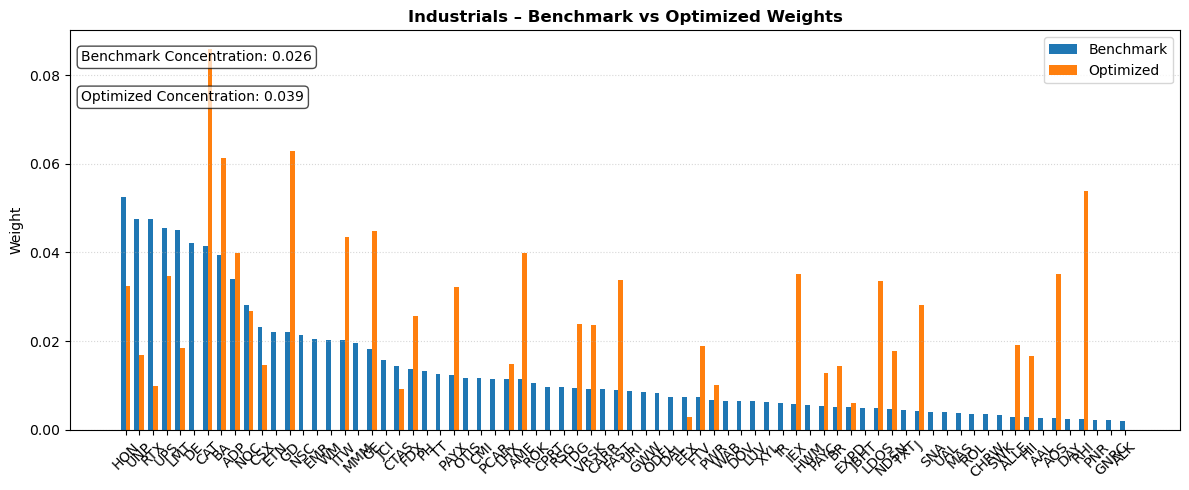

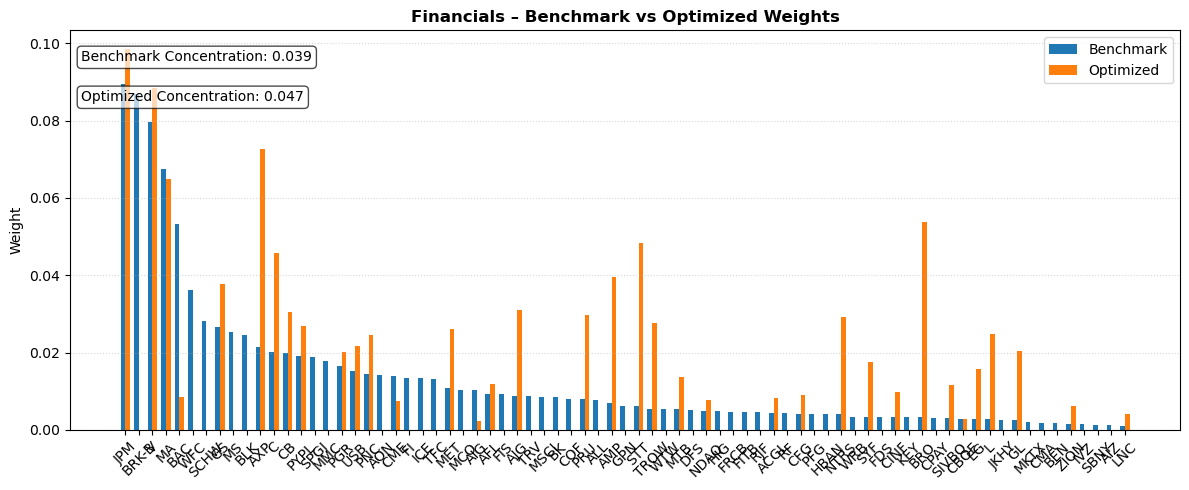

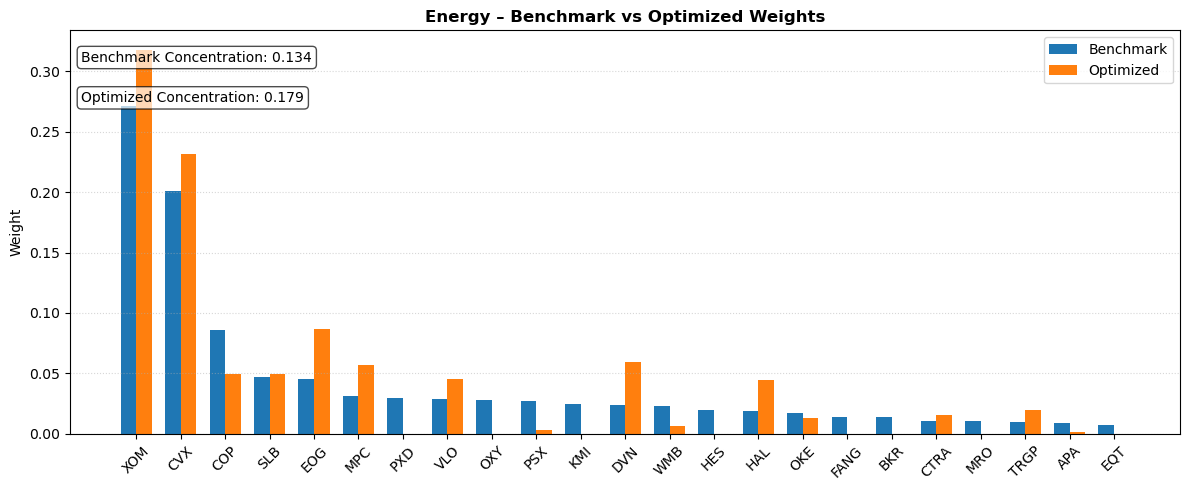

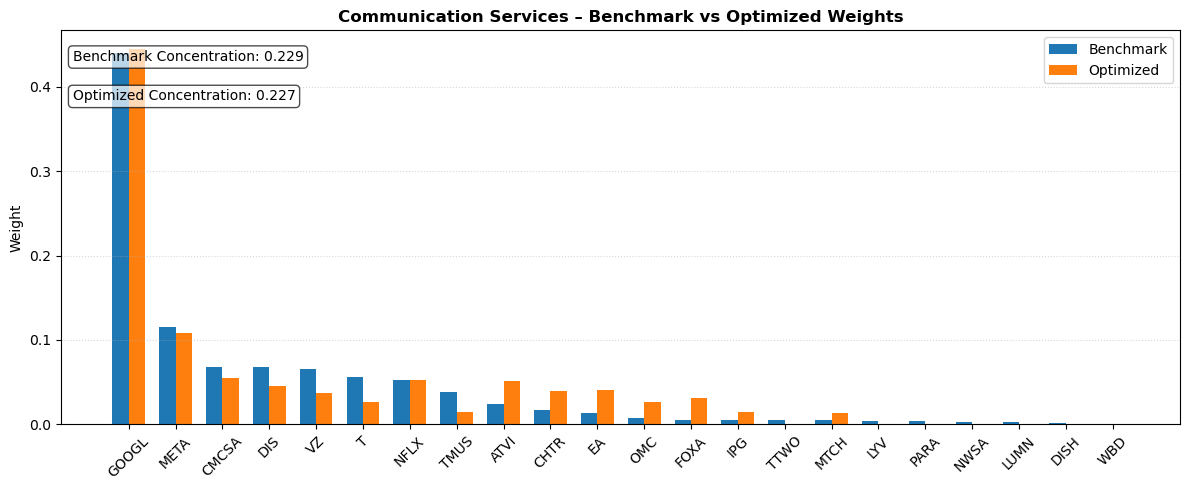

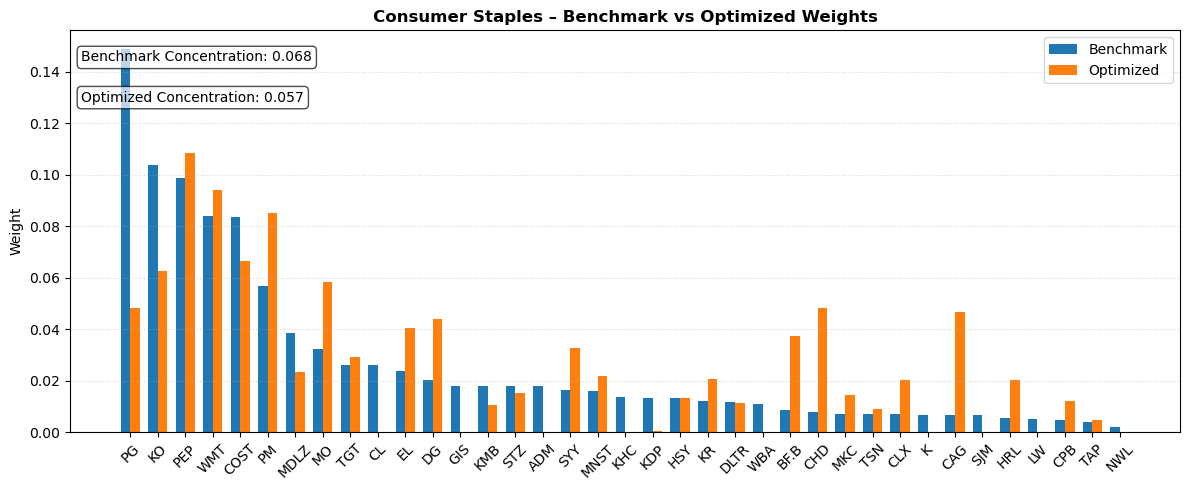

In [27]:
# Load data
# Regularized Sigma (shrinkage + lambda_I + nearest PSD)
def sigma_reg_fn(R_clean):

    # Apply Ledoit-Wolf shrinkage
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    tolerance = 1e-4  # or 0.0001 (allows small wiggle room)

    # --- λI regularization ---
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg, lw.shrinkage_

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negative eigenvalues
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

data = pd.read_excel("Data/dataset_comp_1222.xlsx")

sector_weights = {} 
optimal_portfolios_shrink = {}
diagnostics = []
reductions = []
for sector_name in data['GICS Sector'].unique():
    sector_weights[sector_name] = {
    'weights_by_te': [],
    'tracking_errors': [],
    'carbon_reductions': [],
    'relative_deltas': [],
    }
    sector = data.loc[data['GICS Sector'] == sector_name]

    w_b_sector = sector[['weight_in_sector']]
    assert np.isclose(w_b_sector.sum().values[0], 1.0), f"{sector_name}: weights don't sum to 1"

    c_sector = sector[['Carbon Intensity']]
    assert c_sector.isna().sum().values[0] == 0, f"{sector_name}: carbon data has NaNs"
    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    
    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()
    stock_labels = R_clean.columns
    print("Asserting that the sector order between log returns matrix and df is the same", (sector['SYMBOL'].values == stock_labels).all())
    Sigma_sector, shrinkage_alpha = sigma_reg_fn(R_clean)
  
    Sigma_sector = nearest_psd(Sigma_sector)

    eigvals = np.linalg.eigvalsh(Sigma_sector)
    rank = np.linalg.matrix_rank(Sigma_sector)
    num_features = Sigma_sector.shape[1]
   
    # Prepare optimization inputs
    N = len(w_b_sector)
    w_b_vec = w_b_sector.values.flatten()
    c_vec = c_sector.values.flatten()

    te_caps_annual = np.linspace(0.002, 0.05, 100)
    tracking_errors = []
    carbon_reductions = []
    smallest_eigs = np.sort(eigvals)[:5]


 
    for te_annual in te_caps_annual:
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma_sector))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if prob.status in ["optimal", "optimal_inaccurate"] and w.value is not None:
            w_opt = w.value
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100

            tracking_errors.append(te_real * 10000)
            carbon_reductions.append(reduction_pct)
        else:
            print(f"{sector_name}: Optimization failed at TE cap {te_annual:.3%}")
        w_opt = w.value
        if w_opt is not None:
            # Ex-post tracking error (annualized)
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            tracking_errors.append(te_real * 10000)  # in bps

            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
            carbon_reductions.append(reduction_pct)
            sector_weights[sector_name]['weights_by_te'].append(w_opt)
            sector_weights[sector_name]['tracking_errors'].append(te_real * 10000)
            sector_weights[sector_name]['carbon_reductions'].append(reduction_pct)

        
        cov_sector = pd.read_excel("Data/sector_cov_matrices_comp_1222.xlsx", sheet_name=sector_name)



        if np.round(te_annual, 3) == 0.02:
            optimal_portfolios_shrink[sector_name] = {
            "w_b_vec": w_b_vec,
            "w_opt": w_opt,
            "stock_labels": stock_labels}
            # w_b_vec is the benchmark weights vector
            # w_opt is the optimised weights vector
            # stock labels is the companies name
            benchmark_df =  pd.DataFrame({"w": w_b_vec, "symbol": stock_labels})
            optimised_df = pd.DataFrame({"w": w_opt, "symbol": stock_labels})
            benchmark_df.sort_values(by = 'w', ascending=False, inplace=True)
            optimised_df.sort_values(by = 'w', ascending=False, inplace=True)

            # Count if the leading asset by portfolio weight in the optimized allocation aligns with that of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_1' : 1 if benchmark_df['symbol'].values[0] == optimised_df['symbol'].values[0] else 0})
            # Count how many assets coincide by comparing the three assets with the highest weight in the optimized allocation coincide with the top three weighted consitutents of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_3' : len(set(benchmark_df['symbol'].values[:3]).intersection(set(optimised_df['symbol'].values[:3])))})
            # Count how many assets coincide by comparing the five assets with the highest weight in the optimized allocation coincide with the top five weighted consitutents of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_5' : len(set(benchmark_df['symbol'].values[:5]).intersection(set(optimised_df['symbol'].values[:5])))})
            # Count how many assets coincide by comparing the ten assets with the highest weight in the optimized allocation coincide with the top ten weighted consitutents of the benchmark portfolio.
            optimal_portfolios_shrink[sector_name].update({'count_10' : len(set(benchmark_df['symbol'].values[:10]).intersection(set(optimised_df['symbol'].values[:10])))})

            # Count stocks with non-zero weights in the optimised portfolio:
            optimal_portfolios_shrink[sector_name].update({'zero_stocks': len(optimised_df.loc[optimised_df['w'] < 1e-04])})
            optimal_portfolios_shrink[sector_name].update({'zero_stocks_%': len(optimised_df.loc[optimised_df['w'] < 1e-04])/len(optimised_df)})

    # Define the tracking error breakpoints (in bps)
    absolute_te_points = [100, 200, 300, 400, 500]
    relative_te_points = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

    tracking_errors_np = np.array(tracking_errors)
    carbon_reductions_np = np.array(carbon_reductions)
    # === Carbon Summary Diagnostics ===
    if len(carbon_reductions_np) > 0:
        start_reduction = carbon_reductions_np[0]
        end_reduction = carbon_reductions_np[-1]
        total_gain = end_reduction - start_reduction

        idx_2pct = np.argmin(np.abs(tracking_errors_np - 200))  # ~2% TE = 200bps
        reduction_at_2pct = carbon_reductions_np[idx_2pct]

        diagnostics.append({
             "Sector": sector_name,
            "Num Features": num_features,
            "Rank": rank,
            "Min_Eigval1": smallest_eigs[0],
            "Min_Eigval2": smallest_eigs[1] if len(smallest_eigs) > 1 else np.nan,
            "Min_Eigval3": smallest_eigs[2] if len(smallest_eigs) > 2 else np.nan,
            "Min_Eigval4": smallest_eigs[3] if len(smallest_eigs) > 3 else np.nan,
            "Min_Eigval5": smallest_eigs[4] if len(smallest_eigs) > 4 else np.nan,
            "Low Rank?": rank < num_features,
            "Not PSD?": eigvals.min() < -1e-6,
            "Start Reduction (%)": round(start_reduction, 2),
            "End Reduction (%)": round(end_reduction, 2),
            "Gain (%)": round(total_gain, 2),
            "Reduction @2% TE (%)": round(reduction_at_2pct, 2),
            "Shrinkage Alpha": round(shrinkage_alpha, 3)
    
        })
        reductions.append({
            "Sector": sector_name,
            "Start Reduction (%)": round(start_reduction, 2),
            "End Reduction (%)": round(end_reduction, 2),
            "Gain (%)": round(total_gain, 2),
            "Reduction @2% TE (%)": round(reduction_at_2pct, 2)})
    plot_te_carbon_by_sector(tracking_errors=tracking_errors, carbon_reductions=carbon_reductions, tracking_errors_np=tracking_errors_np, absolute_te_points=absolute_te_points, sector_name=sector_name, sector_weights=sector_weights, relative_te_points=relative_te_points)

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df = diagnostics_df.sort_values("Sector")  # optional
print(tabulate(diagnostics_df, headers='keys', tablefmt='github', showindex=False))
print()
reductions_df = pd.DataFrame(reductions)
print(reductions_raw_df)
print()
print(reductions_df)
print()
# Ensure the DataFrames are aligned on the 'Sector' column
if "Sector" in reductions_raw_df.columns:
    reductions_raw_df = reductions_raw_df.set_index("Sector")
reductions_df = reductions_df.set_index("Sector")

# Compute the difference: (after shrinkage) - (before shrinkage)
delta_df = reductions_df - reductions_raw_df

# Optional: Reset index to make 'Sector' a column again
delta_df = delta_df.reset_index()

# Rename columns to indicate they are deltas
delta_df.columns = ["Sector"] + [f"Δ {col}" for col in reductions_df.columns]
for col in delta_df.columns[1:]:
    delta_df.sort_values(col, inplace=True, ascending= False, key= abs)
    print(tabulate(delta_df, headers='keys', tablefmt='github', showindex=False))

# Custom sector order
ordered_sectors = [
    "Industrials",
    "Financials",
    "Consumer Discretionary",
    "Health Care",
    "Information Technology",
    "Consumer Staples",
    "Energy",
    "Materials",
    "Real Estate",
    "Utilities",
    "Communication Services"
]

plt.figure(figsize=(12, 6))  # Wider figure helps with spacing

for sector_name in ordered_sectors:
    if sector_name in sector_weights:
        metrics = sector_weights[sector_name]
        plt.plot(metrics['tracking_errors'], metrics['carbon_reductions'], label=sector_name)

plt.xlabel('Tracking Error (bps)')
plt.ylabel('Carbon Reduction (%)')
plt.title('TE–Carbon Frontier for All Sectors')

# Legend outside right
plt.legend(title="Sectors", loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()  # Adjust layout to fit legend
plt.show()

plot_te_carbon_heatmap(sector_weights=sector_weights, te_caps_annual=te_caps_annual)
for sector_name, data in optimal_portfolios_shrink.items():
    plot_origin_vs_opt_weights_comparison(
        data["w_b_vec"],
        data["w_opt"],
        data["stock_labels"],
        sector_name=sector_name,
        weight_comp_bool=True
    )

In [28]:
optimal_portfolios_shrink['Communication Services']['zero_stocks_%']

0.2727272727272727

count how many top 1,2,3 etc match for sector , % of stock that remain, 

No big changes:
Real Estate, Materials, Energy, Financials, Communication Services (not a big change but smoother elbow), Consumer Staples not extreme big changes

Biggest changes:
Consumer Discretionary, Health Care, Utilities, Inf. tech, Industrials (very big change)

# Weight Perturbation Sensitivity – Before and After
Answering to the question: "Which sectors deliver robust solutions under changing input assumptions?"

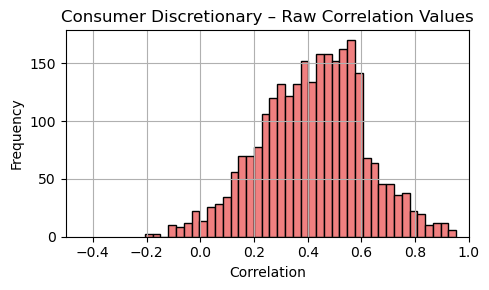

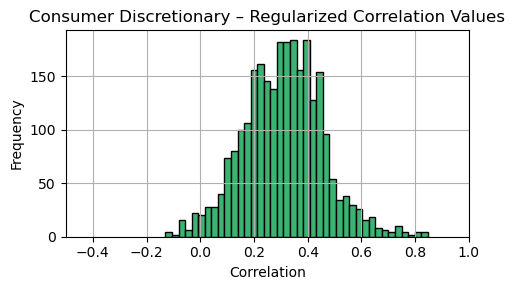

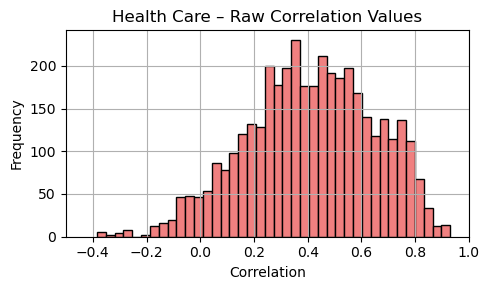

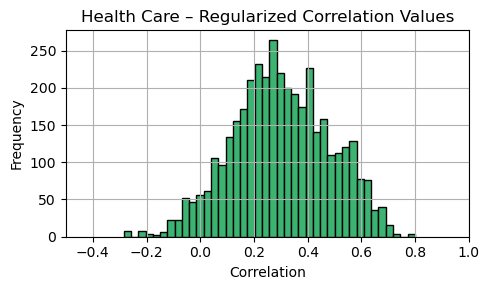

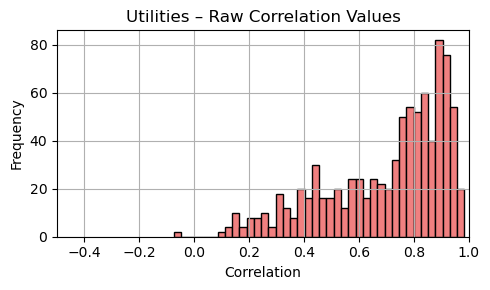

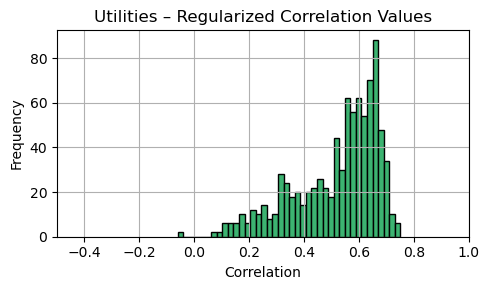

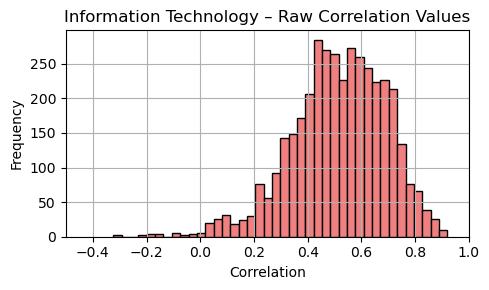

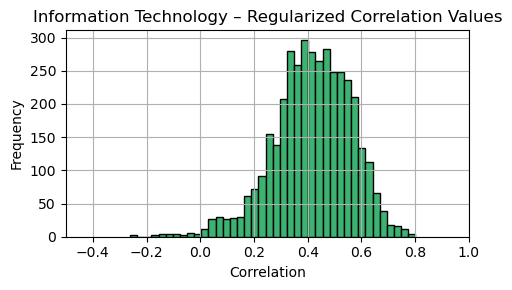

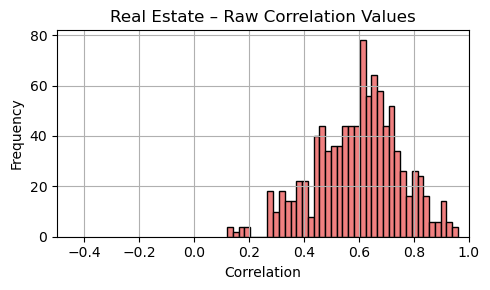

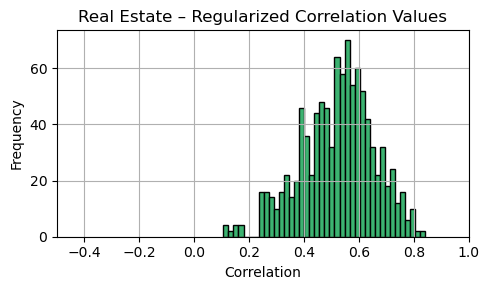

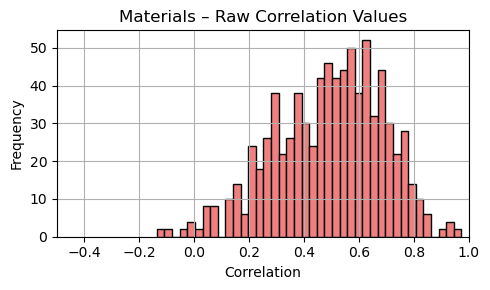

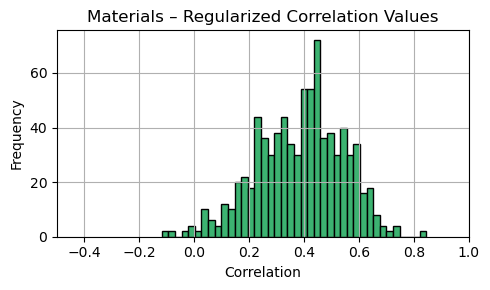

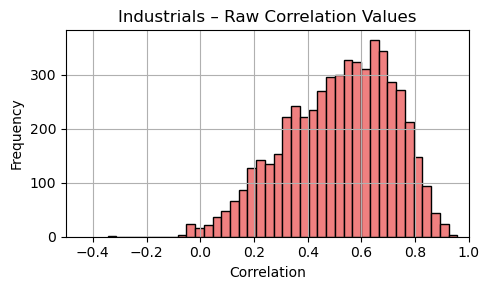

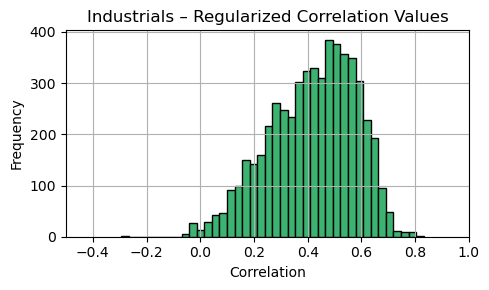

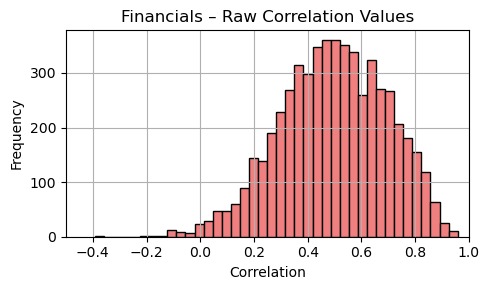

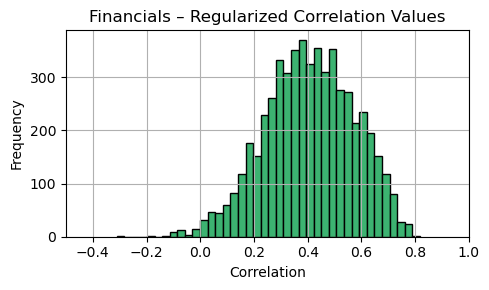

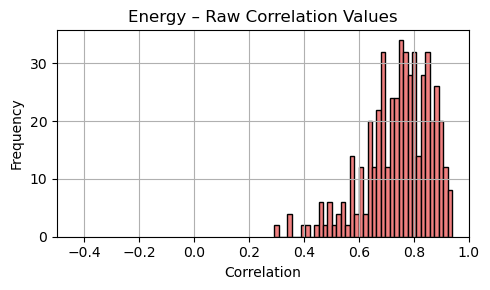

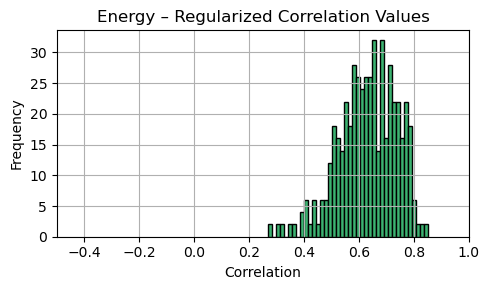

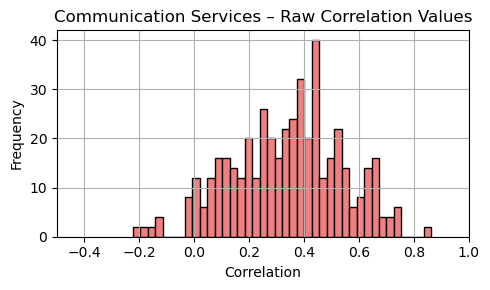

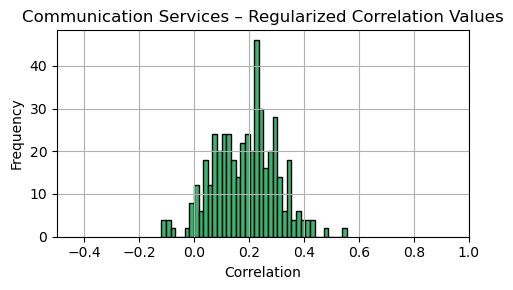

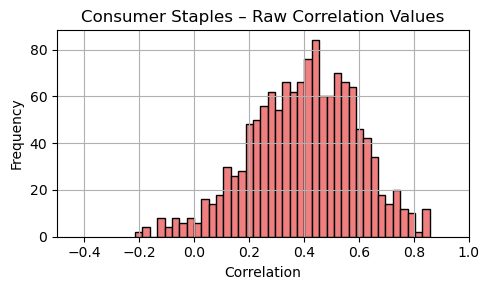

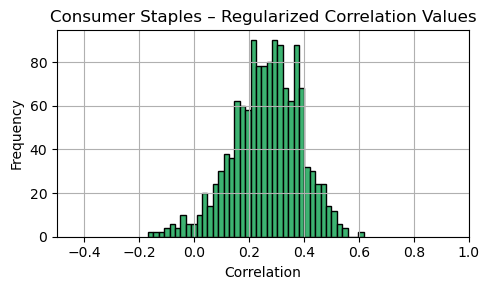

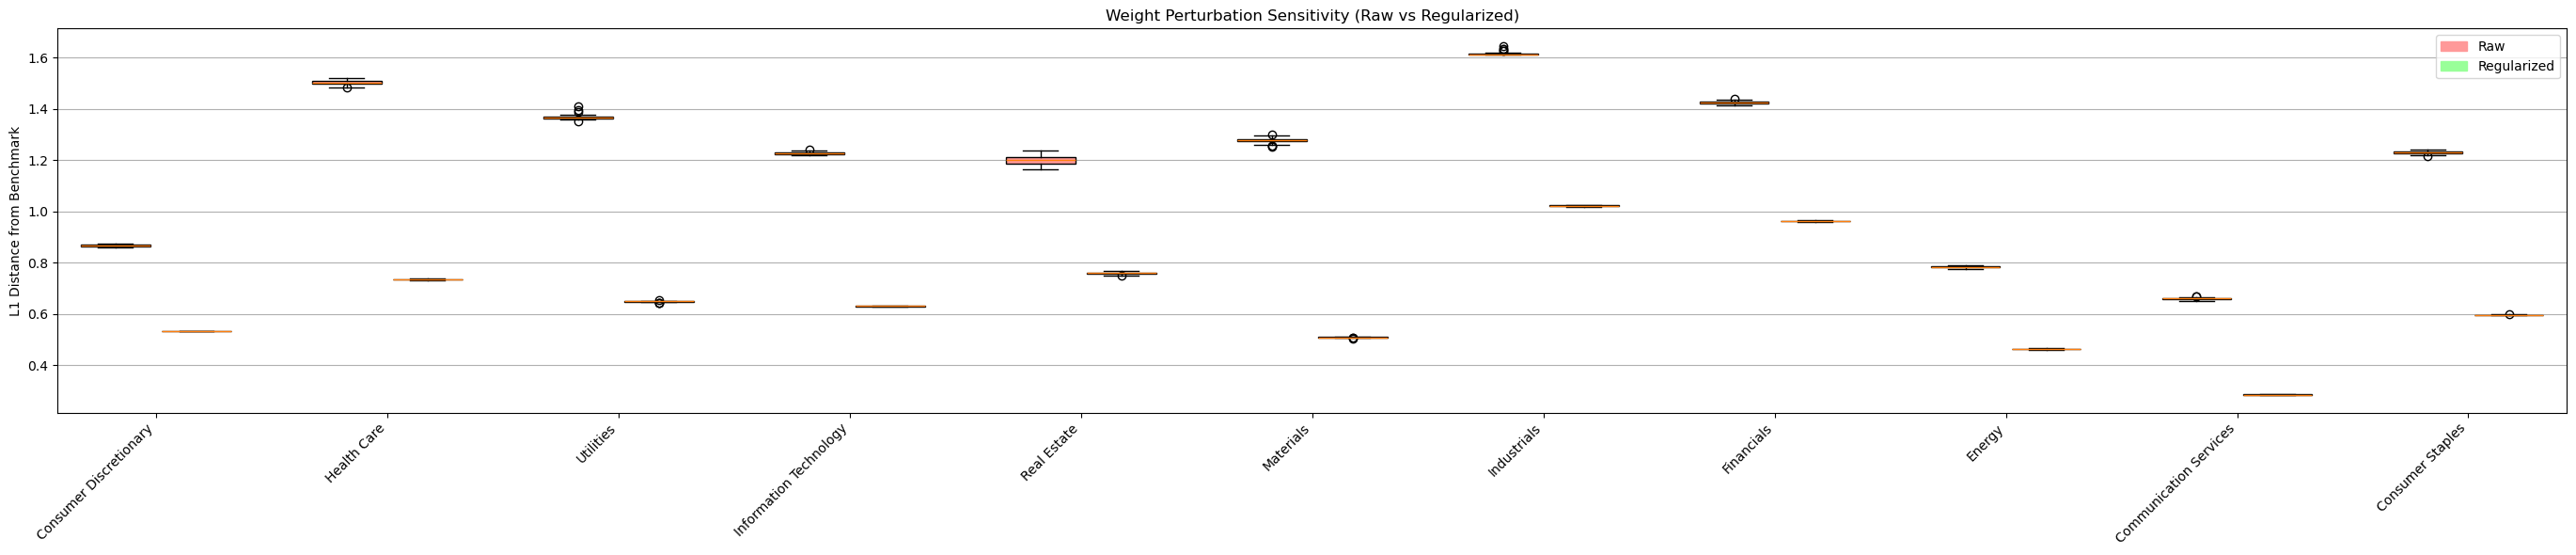

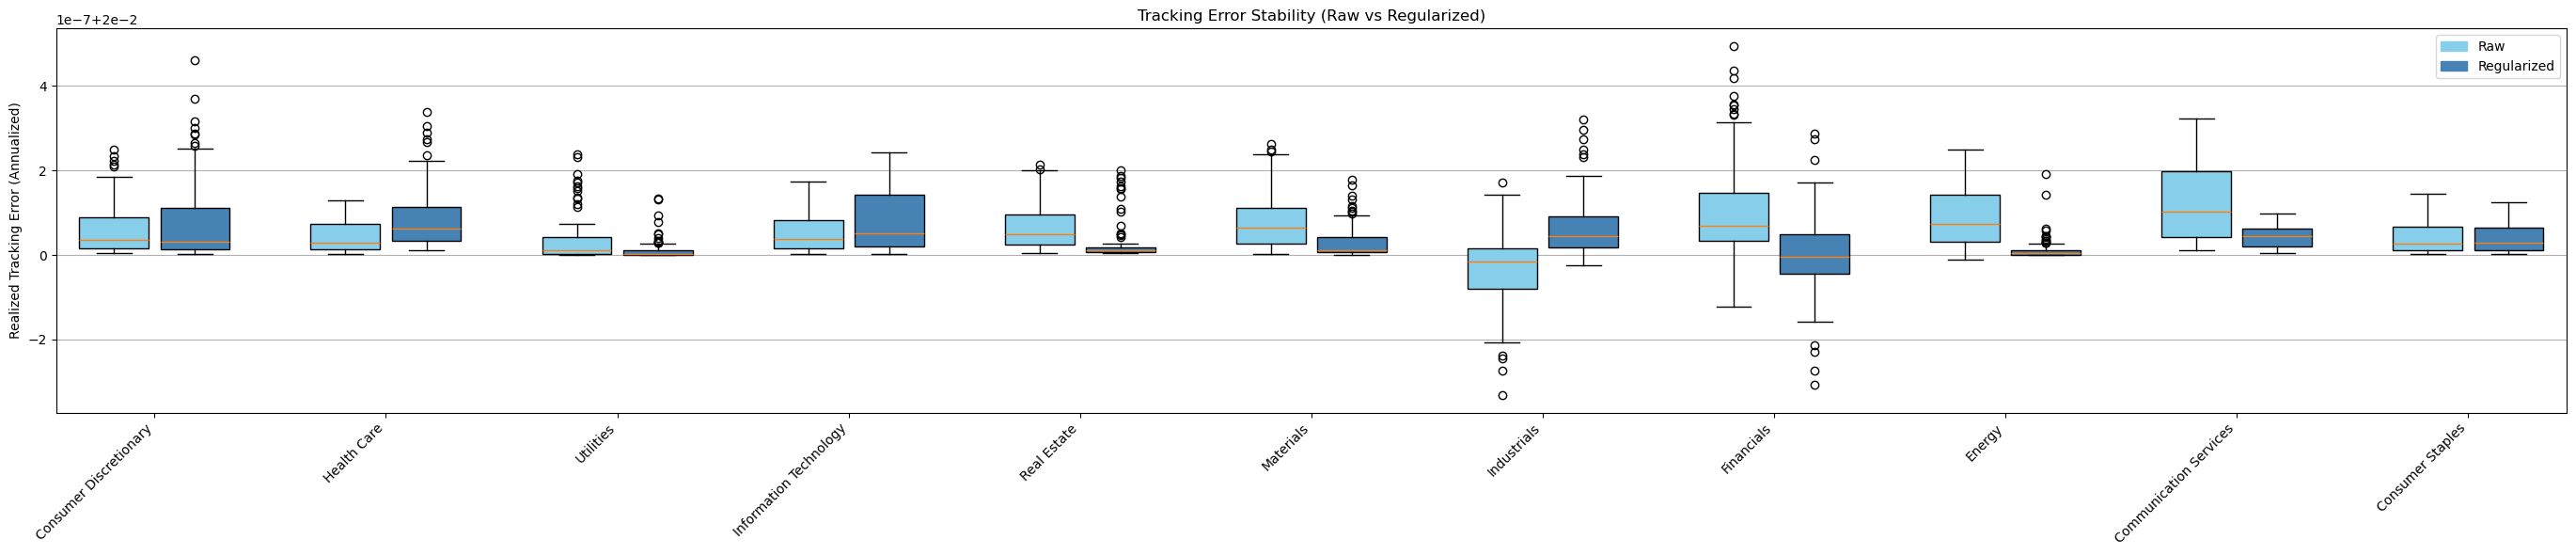

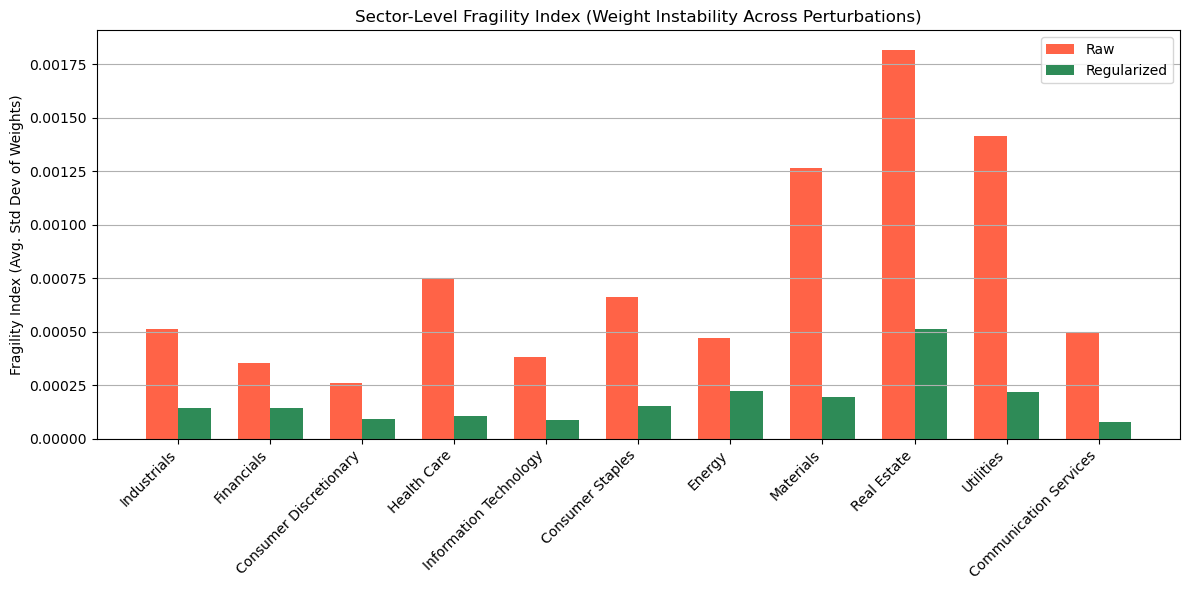

In [12]:
def sigma_reg_fn(R_clean):

    # Apply Ledoit-Wolf shrinkage
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    tolerance = 1e-4  # or 0.0001 (allows small wiggle room)

    # --- λI regularization ---
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg
def compute_perturbed_weights(
    R_clean,
    w_b_vec,
    c_vec,
    Sigma_fn,
    te_cap=0.03,
    n_trials=100,
    noise_std=0.01
):
    N = R_clean.shape[1]
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    weights = []
    tracking_errors = []

    for seed in range(n_trials):
        np.random.seed(seed)
        noise = np.random.normal(0, noise_std, R_clean.shape)
        R_perturbed = R_clean + R_clean.multiply(noise)
        Sigma = Sigma_fn(R_perturbed)

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            # compute realized TE
            diff = w.value - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)


data = pd.read_excel("Data/dataset_comp_1222.xlsx")

for sector_name in data['GICS Sector'].unique():
    
    
    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    

    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()
    
        # --- Histogram of Raw Correlation Matrix ---
    corr_raw = np.corrcoef(R_clean.T)
    off_diag_raw = corr_raw[~np.eye(corr_raw.shape[0], dtype=bool)]

    plt.figure(figsize=(5, 3))
    plt.hist(off_diag_raw, bins=40, color='lightcoral', edgecolor='black')
    plt.xlim(-0.5, 1)
    plt.title(f"{sector_name} – Raw Correlation Values")
    plt.xlabel("Correlation")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    # --- Histogram of Regularized Correlation Matrix ---
    Sigma_reg = sigma_reg_fn(R_clean)  # ← make sure sigma_reg_fn returns matrix only
    stds = np.sqrt(np.diag(Sigma_reg))
    corr_reg = Sigma_reg / np.outer(stds, stds)
    np.fill_diagonal(corr_reg, np.nan)
    off_diag_reg = corr_reg[~np.isnan(corr_reg)]

    plt.figure(figsize=(5, 3))
    plt.hist(off_diag_reg, bins=40, color='mediumseagreen', edgecolor='black')
    plt.title(f"{sector_name} – Regularized Correlation Values")
    plt.xlim(-0.5, 1)
    plt.xlabel("Correlation")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    sector = data.loc[data['GICS Sector'] == sector_name]

    w_b_sector = sector[['weight_in_sector']]
    w_b_vec = w_b_sector.values.flatten()
    c_sector = sector[['Carbon Intensity']]
    c_vec = c_sector.values.flatten()
    
    w_pert_raw, te_pert_raw = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_raw_fn, te_cap=0.02)
    w_pert_reg, te_pert_reg = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_reg_fn, te_cap=0.02)

    # Store
    sector_weights[sector_name]["te_raw"] = te_pert_raw[~np.isnan(te_pert_raw)]
    sector_weights[sector_name]["te_reg"] = te_pert_reg[~np.isnan(te_pert_reg)]

    # Compute standard deviation across perturbations (axis=0 → across trials)
    frag_raw = np.nanstd(w_pert_raw, axis=0).mean()
    frag_reg = np.nanstd(w_pert_reg, axis=0).mean()

    sector_weights[sector_name]["frag_raw"] = frag_raw
    sector_weights[sector_name]["frag_reg"] = frag_reg

    # L1 distances from baseline
    baseline_w = w_b_vec
    l1_raw = [np.sum(np.abs(w - baseline_w)) for w in w_pert_raw if not np.isnan(w).any()]
    l1_reg = [np.sum(np.abs(w - baseline_w)) for w in w_pert_reg if not np.isnan(w).any()]

    sector_weights[sector_name]["l1_raw"] = l1_raw
    sector_weights[sector_name]["l1_reg"] = l1_reg

    sectors = list(sector_weights.keys())
num_sectors = len(sectors)

fig, ax = plt.subplots(figsize=(2.5 * num_sectors, 6))

# Prepare data and positions
all_data = []
positions = []
labels = []
colors = []

for i, sector in enumerate(sectors):
    raw = sector_weights[sector]['l1_raw']
    reg = sector_weights[sector]['l1_reg']
    
    all_data.extend([raw, reg])
    positions.extend([2 * i, 2 * i + 0.7])
    labels.extend([f'{sector}\nRaw', 'Reg'])
    colors.extend(['#ff9999', '#99ff99'])  # light red, light green

# Plot boxplots
box = ax.boxplot(all_data, positions=positions, patch_artist=True, widths=0.6)

# Apply custom colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis
ax.set_xticks([2 * i + 0.35 for i in range(num_sectors)])
ax.set_xticklabels(sectors, rotation=45, ha='right')

# Labels and styling
ax.set_ylabel("L1 Distance from Benchmark")
ax.set_title("Weight Perturbation Sensitivity (Raw vs Regularized)")
ax.grid(True, axis='y')

# Legend manually
from matplotlib.patches import Patch
legend_patches = [Patch(color='#ff9999', label='Raw'), Patch(color='#99ff99', label='Regularized')]
ax.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(2.5 * num_sectors, 6))
all_te_data = []
te_positions = []
te_colors = []
te_labels = []

for i, sector in enumerate(sectors):
    raw = sector_weights[sector]['te_raw']
    reg = sector_weights[sector]['te_reg']

    all_te_data.extend([raw, reg])
    te_positions.extend([2 * i, 2 * i + 0.7])
    te_labels.extend([f'{sector}\nRaw', 'Reg'])
    te_colors.extend(['#87CEEB', '#4682B4'])  # blue shades

box = ax.boxplot(all_te_data, positions=te_positions, patch_artist=True, widths=0.6)
for patch, color in zip(box['boxes'], te_colors):
    patch.set_facecolor(color)

ax.set_xticks([2 * i + 0.35 for i in range(num_sectors)])
ax.set_xticklabels(sectors, rotation=45, ha='right')
ax.set_ylabel("Realized Tracking Error (Annualized)")
ax.set_title("Tracking Error Stability (Raw vs Regularized)")
ax.grid(True, axis='y')

legend_patches = [Patch(color='#87CEEB', label='Raw'), Patch(color='#4682B4', label='Regularized')]
ax.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.show()

frag_raw_all = []
frag_reg_all = []
sectors = []

for sector_name in ordered_sectors:
    if sector_name in sector_weights:
        if "frag_raw" in sector_weights[sector_name] and "frag_reg" in sector_weights[sector_name]:
            frag_raw_all.append(sector_weights[sector_name]["frag_raw"])
            frag_reg_all.append(sector_weights[sector_name]["frag_reg"])
            sectors.append(sector_name)

x = np.arange(len(sectors))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, frag_raw_all, width, label='Raw', color='tomato')
plt.bar(x + width/2, frag_reg_all, width, label='Regularized', color='seagreen')
plt.xticks(x, sectors, rotation=45, ha='right')
plt.ylabel("Fragility Index (Avg. Std Dev of Weights)")
plt.title("Sector-Level Fragility Index (Weight Instability Across Perturbations)")
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()



In [13]:
from sklearn.covariance import LedoitWolf
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# === UTILITIES ===

def sigma_raw_fn(R_clean):
    return R_clean.cov()

def sigma_reg_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    lambda_I = 1e-5
    return Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])

def simulate_parametric_noise(mu, Sigma, T, n_trials):
    return [np.random.multivariate_normal(mu, Sigma, T) for _ in range(n_trials)]

def bootstrap_returns(R_clean_np, n_trials):
    T = R_clean_np.shape[0]
    return [R_clean_np[np.random.choice(T, T, replace=True)] for _ in range(n_trials)]

def compute_perturbed_weights_from_samples(R_samples, w_b_vec, c_vec, Sigma_fn, te_cap=0.03):
    weights, tracking_errors = [], []
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    N = len(w_b_vec)

    for R_perturbed in R_samples:
        Sigma = Sigma_fn(pd.DataFrame(R_perturbed))
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)

def compute_perturbed_weights(
    R_clean,
    w_b_vec,
    c_vec,
    Sigma_fn,
    te_cap=0.03,
    n_trials=100,
    noise_std=0.01,
    noise_type="multiplicative"  # or "additive"
):
    N = R_clean.shape[1]
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    weights = []
    tracking_errors = []

    for seed in range(n_trials):
        np.random.seed(seed)
        noise = np.random.normal(0, noise_std, R_clean.shape)

        if noise_type == "multiplicative":
            R_perturbed = R_clean + R_clean.multiply(noise)
        elif noise_type == "additive":
            R_perturbed = R_clean + noise
        else:
            raise ValueError("noise_type must be 'multiplicative' or 'additive'")

        Sigma = Sigma_fn(R_perturbed)

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)


def compute_hhi(weights):
    return np.sum(np.square(weights))

def check_total_variability(R_clean, sector_name):
    stds = R_clean.std(axis=0)
    avg_std = np.mean(stds)
    print(f"{sector_name}: Avg Std Dev = {avg_std:.4f}")

In [14]:
data = pd.read_excel("Data/dataset_comp_1222.xlsx")
sector_weights = {}
n_trials = 100

for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    R_np = R_clean.values
    mu_hat = R_np.mean(axis=0)
    Sigma_hat = np.cov(R_np, rowvar=False)
    T = R_np.shape[0]

    sector = data[data['GICS Sector'] == sector_name]
    w_b_vec = sector['weight_in_sector'].values
    c_vec = sector['Carbon Intensity'].values

    # Simulate
    param_samples = simulate_parametric_noise(mu_hat, Sigma_hat, T, n_trials)
    boot_samples = bootstrap_returns(R_np, n_trials)

    # Optimization (raw vs regularized)
    w_param_raw, te_param_raw = compute_perturbed_weights_from_samples(param_samples, w_b_vec, c_vec, sigma_raw_fn)
    w_param_reg, te_param_reg = compute_perturbed_weights_from_samples(param_samples, w_b_vec, c_vec, sigma_reg_fn)

    w_boot_raw, te_boot_raw = compute_perturbed_weights_from_samples(boot_samples, w_b_vec, c_vec, sigma_raw_fn)
    w_boot_reg, te_boot_reg = compute_perturbed_weights_from_samples(boot_samples, w_b_vec, c_vec, sigma_reg_fn)

    w_mult_raw, te_mult_raw = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_raw_fn, noise_type="multiplicative", noise_std=0.3)
    w_mult_reg, te_mult_reg = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_reg_fn, noise_type="multiplicative", noise_std=0.3)

    w_add_raw, te_add_raw = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_raw_fn, noise_type="additive")
    w_add_reg, te_add_reg = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_reg_fn, noise_type="additive")

    # Condition Numbers
    cond_raw = np.linalg.cond(sigma_raw_fn(R_clean))
    cond_reg = np.linalg.cond(sigma_reg_fn(R_clean))

    # Fragility
    frag_param_raw = np.nanstd(w_param_raw, axis=0).mean()
    frag_param_reg = np.nanstd(w_param_reg, axis=0).mean()
    frag_boot_raw = np.nanstd(w_boot_raw, axis=0).mean()
    frag_boot_reg = np.nanstd(w_boot_reg, axis=0).mean()
    frag_mult_raw = np.nanstd(w_mult_raw, axis=0).mean()
    frag_mult_reg = np.nanstd(w_mult_reg, axis=0).mean()
    frag_add_raw = np.nanstd(w_add_raw, axis=0).mean()
    frag_add_reg = np.nanstd(w_add_reg, axis=0).mean()

    # Fragility ratios
    frag_ratio_param = frag_param_raw / frag_param_reg if frag_param_reg > 0 else np.nan
    frag_ratio_boot = frag_boot_raw / frag_boot_reg if frag_boot_reg > 0 else np.nan
    frag_ratio_mult = frag_mult_raw / frag_mult_reg if frag_mult_reg > 0 else np.nan
    frag_ratio_add = frag_add_raw / frag_add_reg if frag_add_reg > 0 else np.nan

    # L1 deviation
    l1_param_raw = [np.sum(np.abs(w - w_b_vec)) for w in w_param_raw if not np.isnan(w).any()]
    l1_param_reg = [np.sum(np.abs(w - w_b_vec)) for w in w_param_reg if not np.isnan(w).any()]
    l1_boot_raw = [np.sum(np.abs(w - w_b_vec)) for w in w_boot_raw if not np.isnan(w).any()]
    l1_boot_reg = [np.sum(np.abs(w - w_b_vec)) for w in w_boot_reg if not np.isnan(w).any()]
    l1_mult_raw = [np.sum(np.abs(w - w_b_vec)) for w in w_mult_raw if not np.isnan(w).any()]
    l1_mult_reg = [np.sum(np.abs(w - w_b_vec)) for w in w_mult_reg if not np.isnan(w).any()]
    l1_add_raw = [np.sum(np.abs(w - w_b_vec)) for w in w_add_raw if not np.isnan(w).any()]
    l1_add_reg = [np.sum(np.abs(w - w_b_vec)) for w in w_add_reg if not np.isnan(w).any()]

   # Concentration metrics
    hhi_benchmark = compute_hhi(w_b_vec)
   
    sector_weights[sector_name] = {
        # Fragility
        "frag_param_raw": frag_param_raw,
        "frag_param_reg": frag_param_reg,
        "frag_boot_raw": frag_boot_raw,
        "frag_boot_reg": frag_boot_reg,
        "frag_mult_raw": frag_mult_raw,
        "frag_mult_reg": frag_mult_reg,
        "frag_add_raw": frag_add_raw,
        "frag_add_reg": frag_add_reg,

        # Fragility ratios
        "frag_ratio_param": frag_ratio_param,
        "frag_ratio_boot": frag_ratio_boot,
        "frag_ratio_mult": frag_ratio_mult,
        "frag_ratio_add": frag_ratio_add,

        # L1 distances
        "l1_param_raw": l1_param_raw,
        "l1_param_reg": l1_param_reg,
        "l1_boot_raw": l1_boot_raw,
        "l1_boot_reg": l1_boot_reg,
        "l1_mult_raw": l1_mult_raw,
        "l1_mult_reg": l1_mult_reg,
        "l1_add_raw": l1_add_raw,
        "l1_add_reg": l1_add_reg,

        # Tracking Error
        "te_param_raw": te_param_raw,
        "te_param_reg": te_param_reg,
        "te_boot_raw": te_boot_raw,
        "te_boot_reg": te_boot_reg,
        "te_mult_raw": te_mult_raw,
        "te_mult_reg": te_mult_reg,
        "te_add_raw": te_add_raw,
        "te_add_reg": te_add_reg,

        # HHI – Concentration Scores
        "hhi_benchmark": hhi_benchmark,
        "hhi_param_raw": np.nanmean([compute_hhi(w) for w in w_param_raw if not np.isnan(w).any()]),
        "hhi_param_reg": np.nanmean([compute_hhi(w) for w in w_param_reg if not np.isnan(w).any()]),
        "hhi_boot_raw": np.nanmean([compute_hhi(w) for w in w_boot_raw if not np.isnan(w).any()]),
        "hhi_boot_reg": np.nanmean([compute_hhi(w) for w in w_boot_reg if not np.isnan(w).any()]),
        "hhi_mult_raw": np.nanmean([compute_hhi(w) for w in w_mult_raw if not np.isnan(w).any()]),
        "hhi_mult_reg": np.nanmean([compute_hhi(w) for w in w_mult_reg if not np.isnan(w).any()]),
        "hhi_add_raw": np.nanmean([compute_hhi(w) for w in w_add_raw if not np.isnan(w).any()]),
        "hhi_add_reg": np.nanmean([compute_hhi(w) for w in w_add_reg if not np.isnan(w).any()]),

        # Condition number
        "cond_raw": cond_raw,
        "cond_reg": cond_reg
    }


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [15]:
for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    check_total_variability(R_clean, sector_name)

Consumer Discretionary: Avg Std Dev = 0.1032
Health Care: Avg Std Dev = 0.0895
Utilities: Avg Std Dev = 0.0787
Information Technology: Avg Std Dev = 0.1007
Real Estate: Avg Std Dev = 0.0770
Materials: Avg Std Dev = 0.0942
Industrials: Avg Std Dev = 0.0841
Financials: Avg Std Dev = 0.0814
Energy: Avg Std Dev = 0.1157
Communication Services: Avg Std Dev = 0.1023
Consumer Staples: Avg Std Dev = 0.0663


Consumer Discretionary 1.1177173577450033e+19
Health Care 7.559888262727906e+19
Utilities 3.2534791526321234e+18
Information Technology 1.384501918027359e+19
Real Estate 3.466499288028277e+17
Materials 6.333172594588101e+17
Industrials 5.551582374012965e+18
Financials 1.8067956984696893e+19
Energy 10858.53048017778
Communication Services 1989.0068535374262
Consumer Staples 2.561760938922315e+19


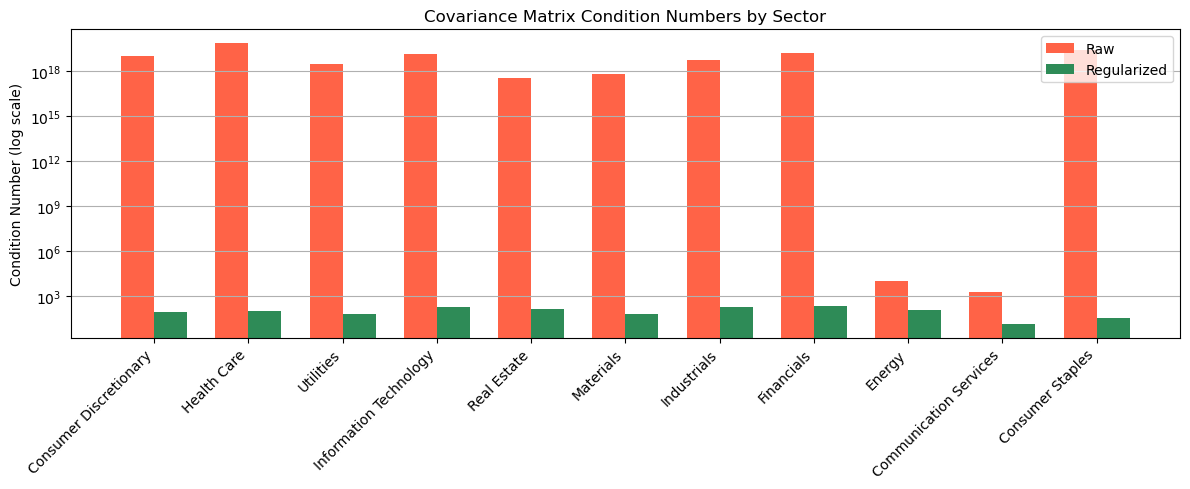

In [16]:
sectors = list(sector_weights.keys())
cond_raws = [sector_weights[s]["cond_raw"] for s in sectors]
cond_regs = [sector_weights[s]["cond_reg"] for s in sectors]
for s in sectors:
    print(s, sector_weights[s]["cond_raw"])

x = np.arange(len(sectors))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, cond_raws, width, label='Raw', color='tomato')
ax.bar(x + width / 2, cond_regs, width, label='Regularized', color='seagreen')

ax.set_yscale('log')  # <--- ADD THIS

ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=45, ha='right')
ax.set_ylabel("Condition Number (log scale)")
ax.set_title("Covariance Matrix Condition Numbers by Sector")
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()


In general all sectors are severely ill-conditioned, except for the Energy and Communication Services sectors that are mildy ill-conditioned.  What could be the reason why Energy condition number is lower?
Maybe because narrow spread of correlation (tigh around 0.6-0.9) can sometimes reduce spread in eigenvalues.
For communication services, it may be simply because of the low number of constituents. 

min: -2.61e-17
max: 2.78e-01
Condition number: -1.06e+16
1.12e+19


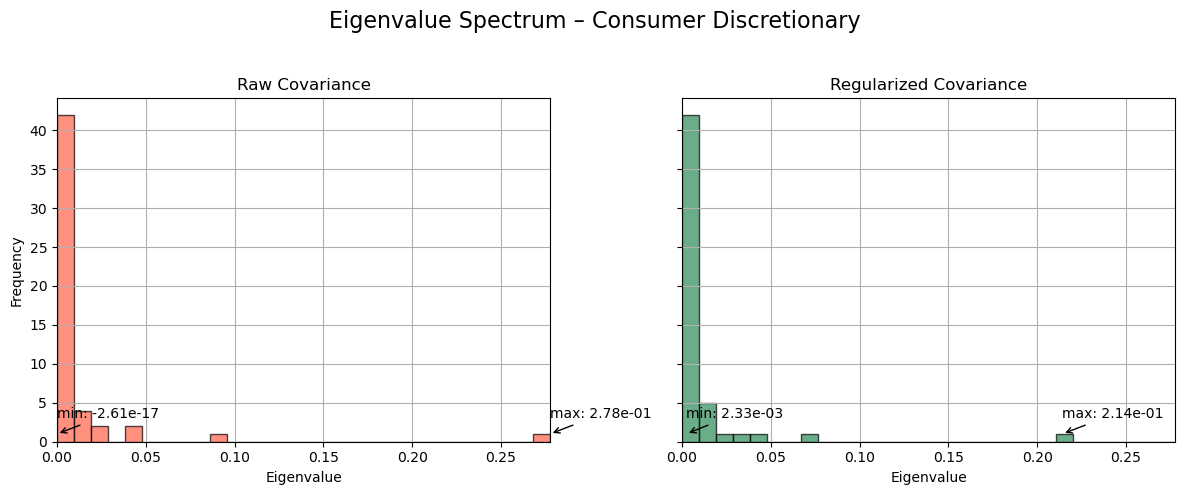

min: -1.59e-17
max: 2.61e-01
Condition number: -1.64e+16
7.56e+19


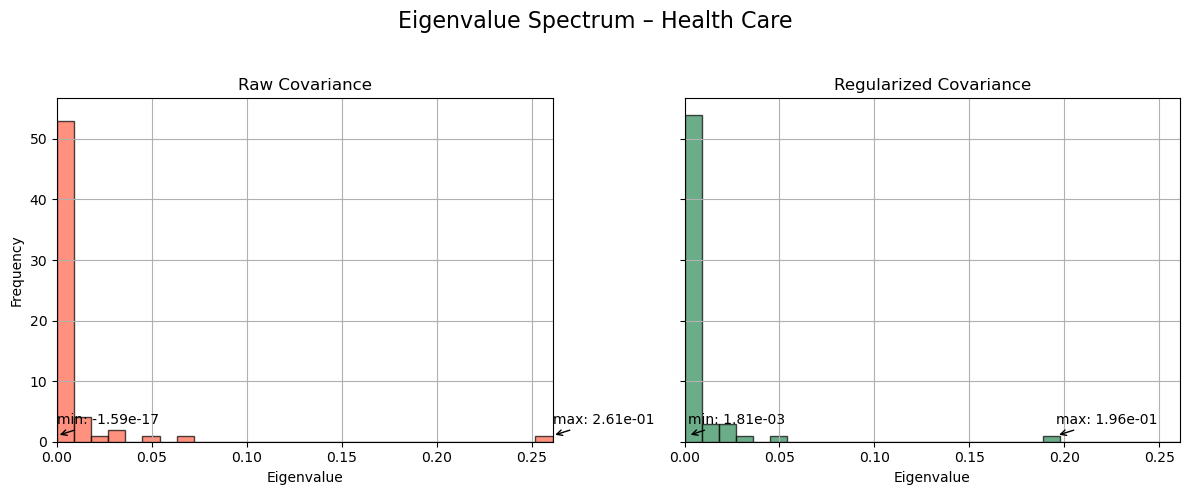

min: -1.88e-17
max: 1.28e-01
Condition number: -6.84e+15
3.25e+18


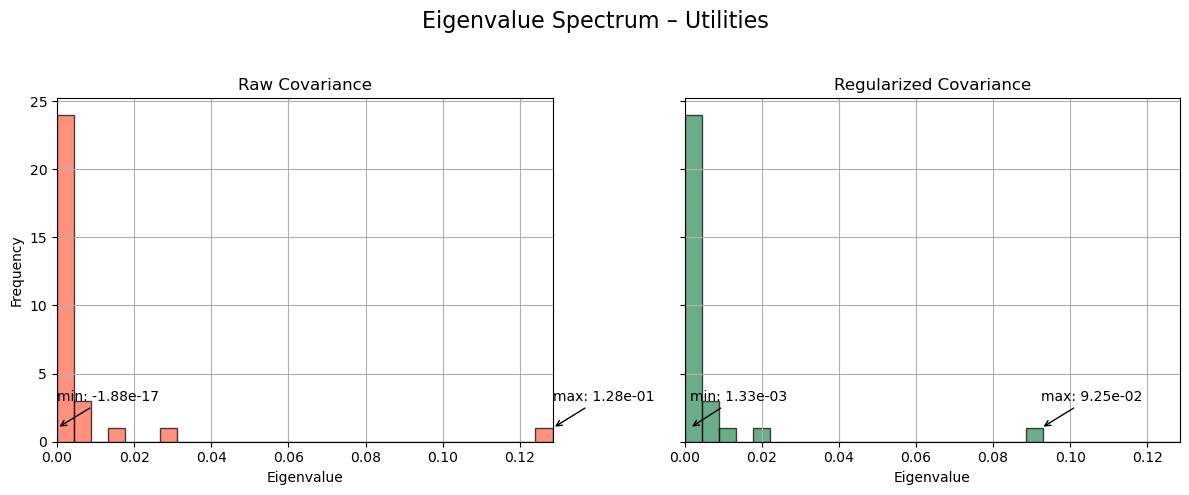

min: -3.51e-17
max: 3.58e-01
Condition number: -1.02e+16
1.38e+19


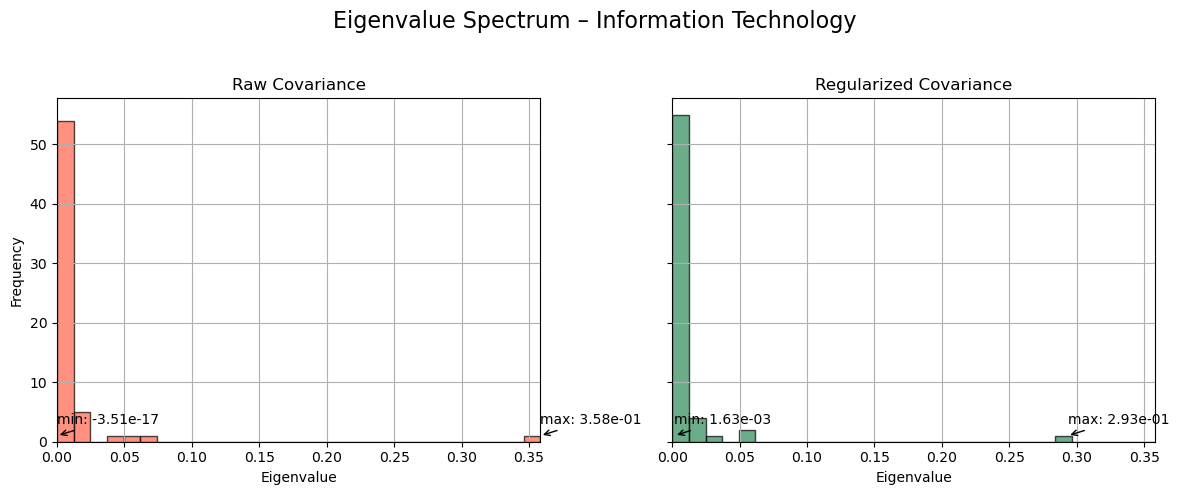

min: -2.54e-18
max: 1.17e-01
Condition number: -4.60e+16
3.47e+17


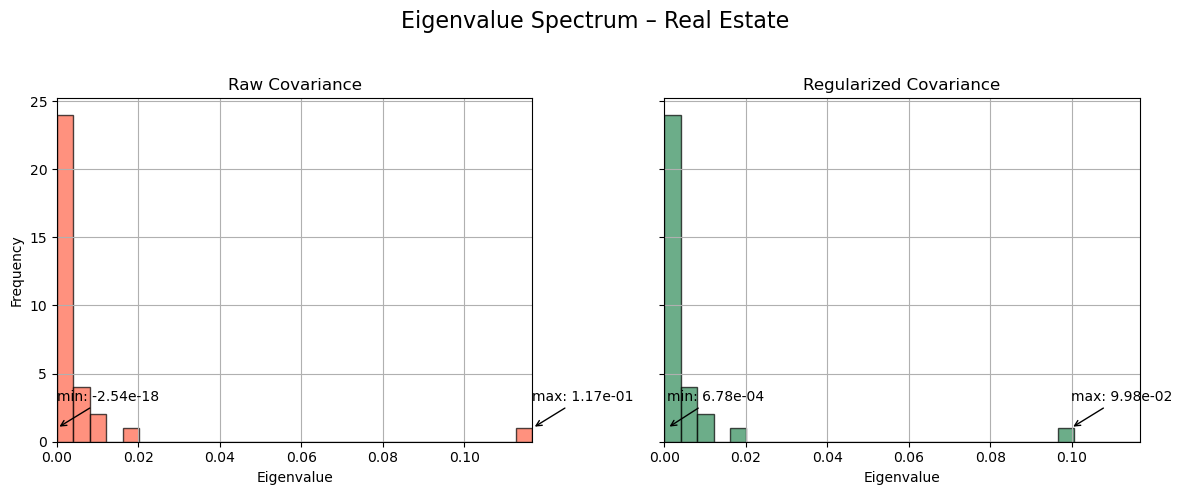

min: -1.70e-18
max: 1.44e-01
Condition number: -8.43e+16
6.33e+17


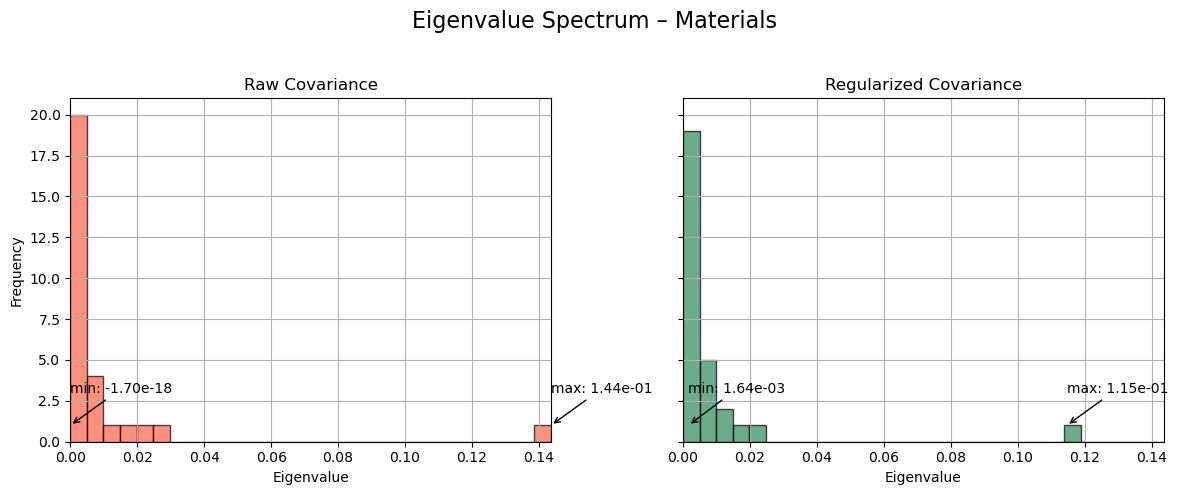

min: -3.70e-17
max: 2.81e-01
Condition number: -7.61e+15
5.55e+18


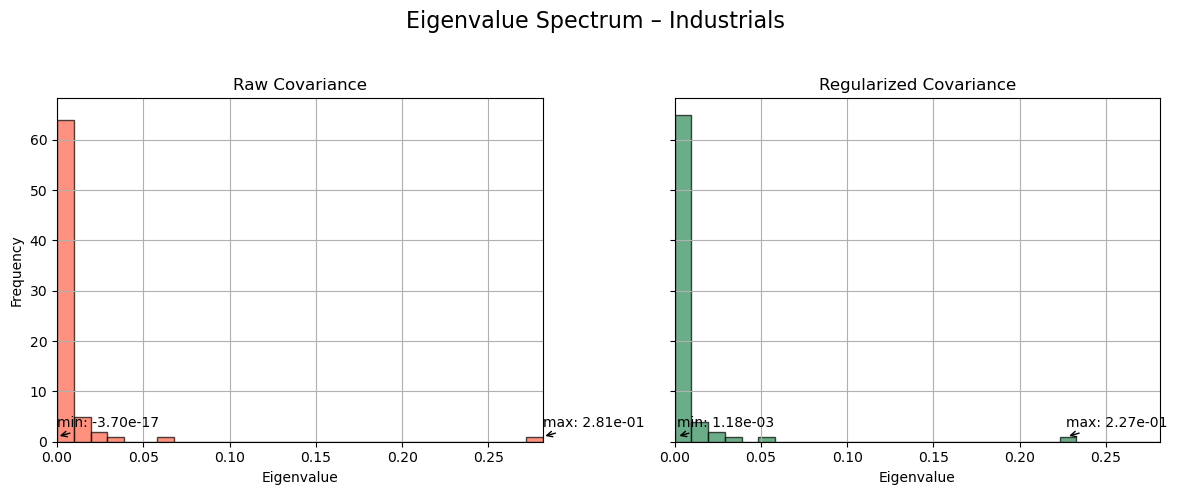

min: -4.68e-17
max: 2.70e-01
Condition number: -5.76e+15
1.81e+19


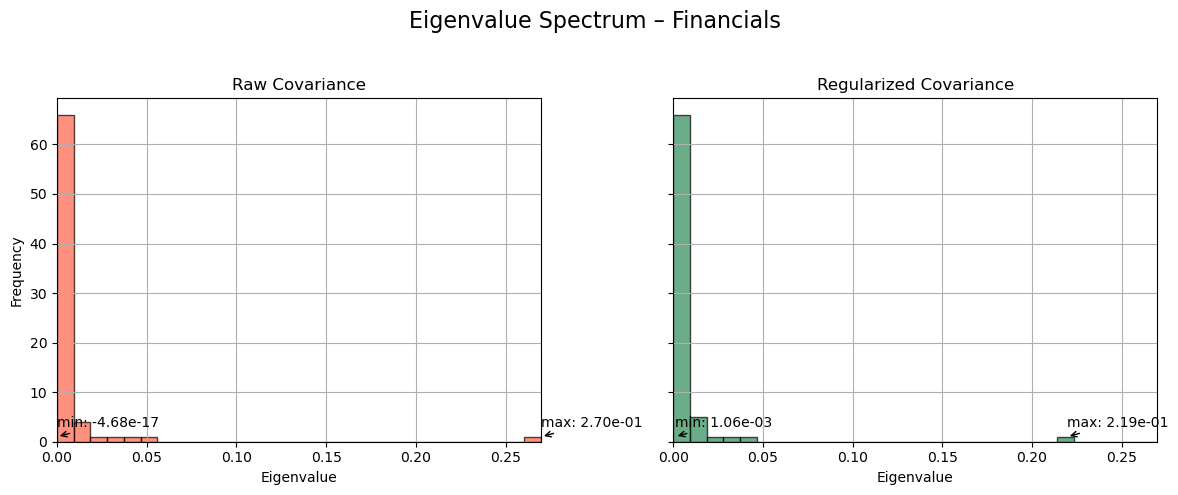

min: 2.23e-05
max: 2.42e-01
Condition number: 1.09e+04
1.09e+04


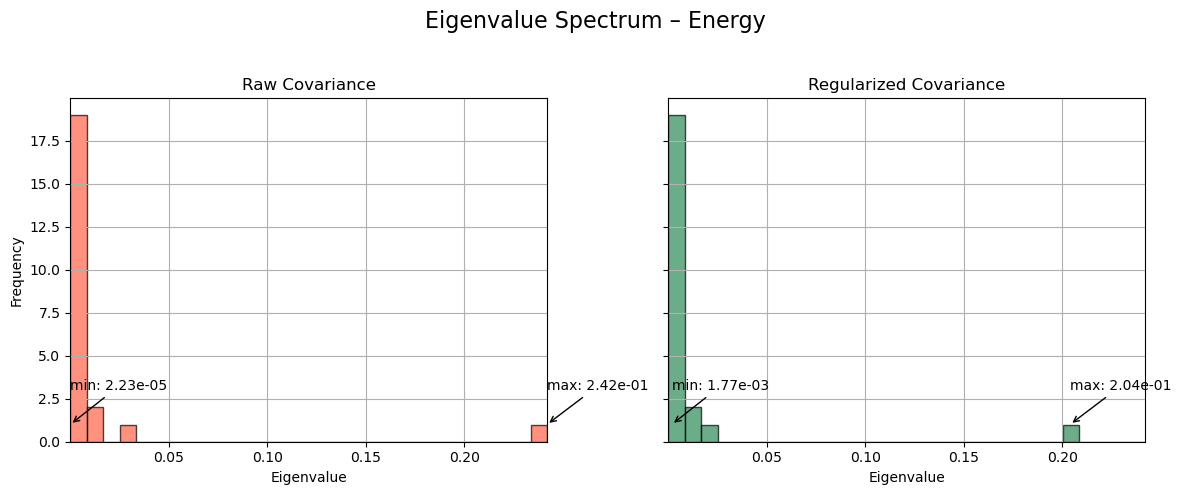

min: 4.90e-05
max: 9.74e-02
Condition number: 1.99e+03
1.99e+03


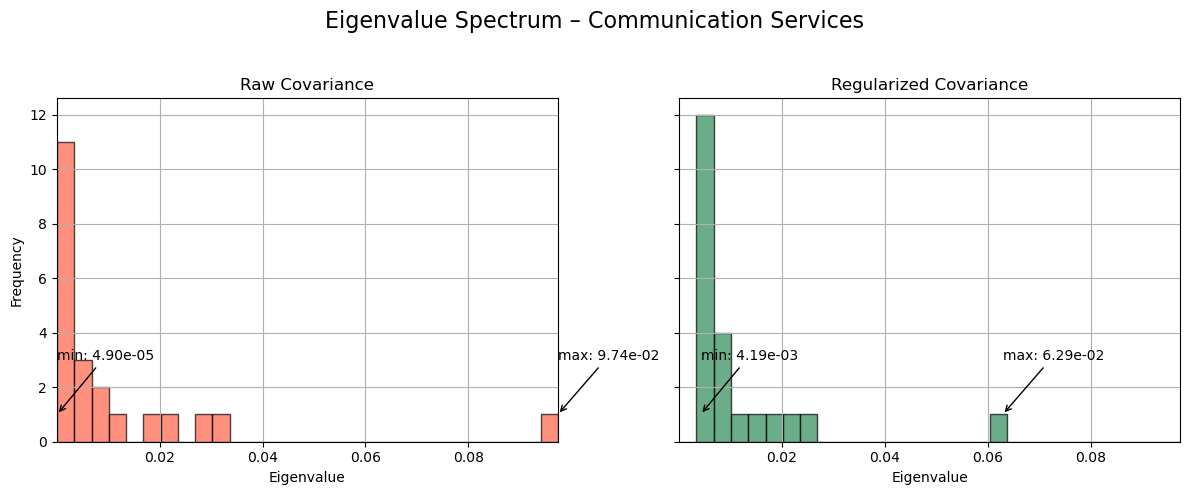

min: -3.90e-18
max: 6.60e-02
Condition number: -1.69e+16
2.56e+19


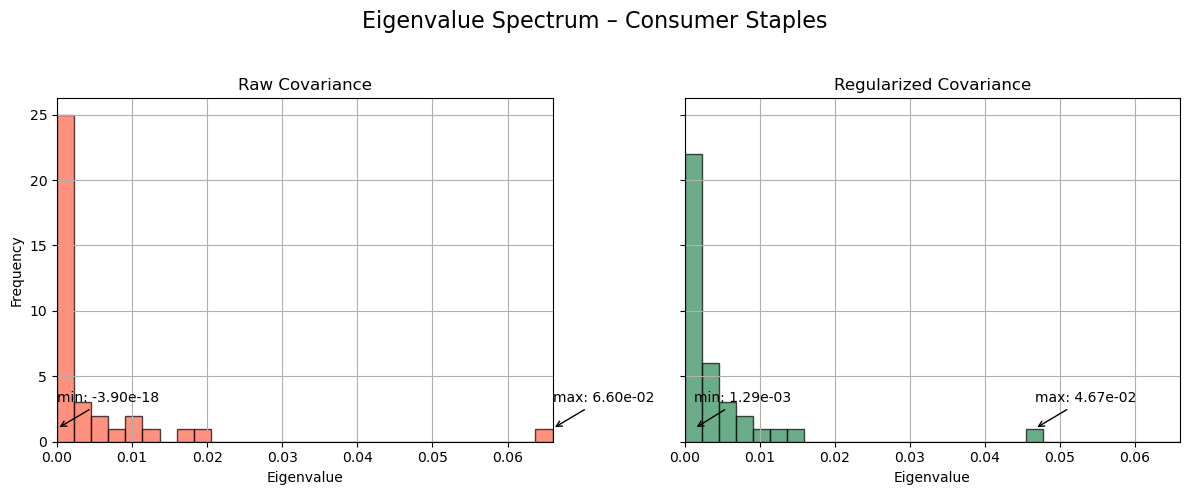

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.covariance import LedoitWolf

def sigma_raw_fn(R_clean):
    return R_clean.cov()

def sigma_reg_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    lambda_I = 1e-5
    return Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])

for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    Sigma_raw = sigma_raw_fn(R_clean)
    Sigma_reg = sigma_reg_fn(R_clean)
    eigvals_raw = np.linalg.eigvalsh(Sigma_raw)
    eigvals_reg = np.linalg.eigvalsh(Sigma_reg)

    # Combine eigenvalues to get common x-axis range
    all_eigvals = np.concatenate([eigvals_raw, eigvals_reg])
    xmin, xmax = np.min(all_eigvals), np.max(all_eigvals)
    bins = np.linspace(xmin, xmax, 30)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(f"Eigenvalue Spectrum – {sector_name}", fontsize=16)

    # Raw
    axes[0].hist(eigvals_raw, bins=bins, alpha=0.7, color='tomato', edgecolor='black')
    axes[0].set_title("Raw Covariance")
    axes[0].set_xlabel("Eigenvalue")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True)
    axes[0].set_xlim(xmin, xmax)
    print(f"min: {eigvals_raw.min():.2e}")
    print(f"max: {eigvals_raw.max():.2e}")
    print(f"Condition number: {eigvals_raw.max()/eigvals_raw.min():.2e}")
    cond_number = np.linalg.cond(sigma_raw_fn(R_clean))
    print(f"{cond_number:.2e}")
    # Annotate min and max eigenvalues
    axes[0].annotate(f"min: {eigvals_raw.min():.2e}", xy=(eigvals_raw.min(), 1), xytext=(eigvals_raw.min(), 3),
                     arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')
    axes[0].annotate(f"max: {eigvals_raw.max():.2e}", xy=(eigvals_raw.max(), 1), xytext=(eigvals_raw.max(), 3),
                     arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')

    # Regularized
    axes[1].hist(eigvals_reg, bins=bins, alpha=0.7, color='seagreen', edgecolor='black')
    axes[1].set_title("Regularized Covariance")
    axes[1].set_xlabel("Eigenvalue")
    axes[1].grid(True)
    axes[1].set_xlim(xmin, xmax)

    # Annotate min and max eigenvalues
    axes[1].annotate(f"min: {eigvals_reg.min():.2e}", xy=(eigvals_reg.min(), 1), xytext=(eigvals_reg.min(), 3),
                     arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')
    axes[1].annotate(f"max: {eigvals_reg.max():.2e}", xy=(eigvals_reg.max(), 1), xytext=(eigvals_reg.max(), 3),
                     arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, color='black')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


The max eigenvalue gets pulled down toward the average variance, so better conditioning is achieved.

A low condition number is good because:

- It means the matrix is well-conditioned
- The matrix is invertible
- Portfolio weights are less sensitive to estimation noise
- Optimization becomes more robust

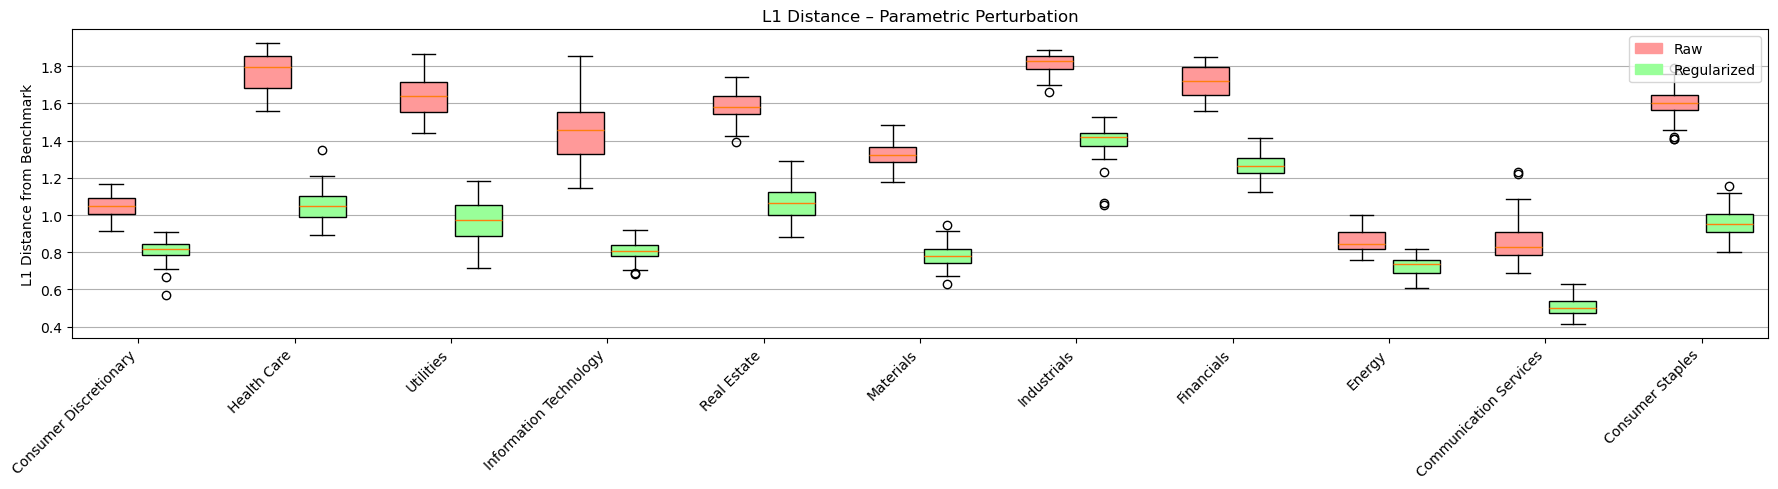

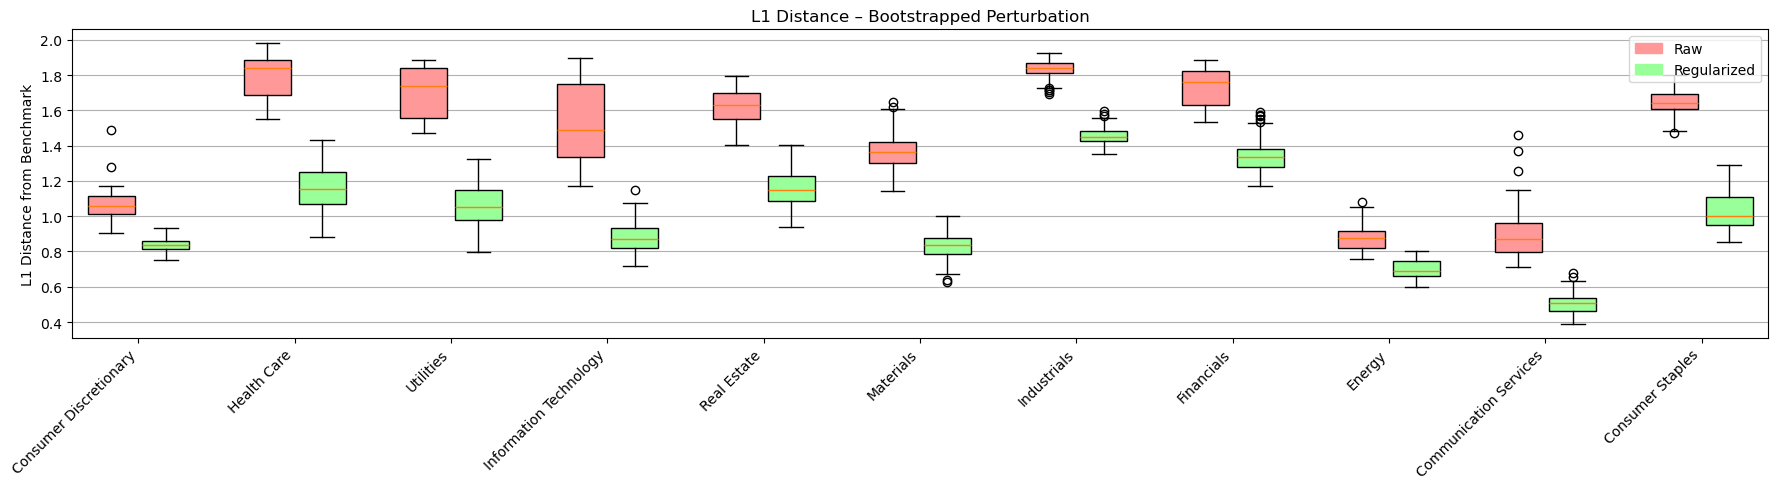

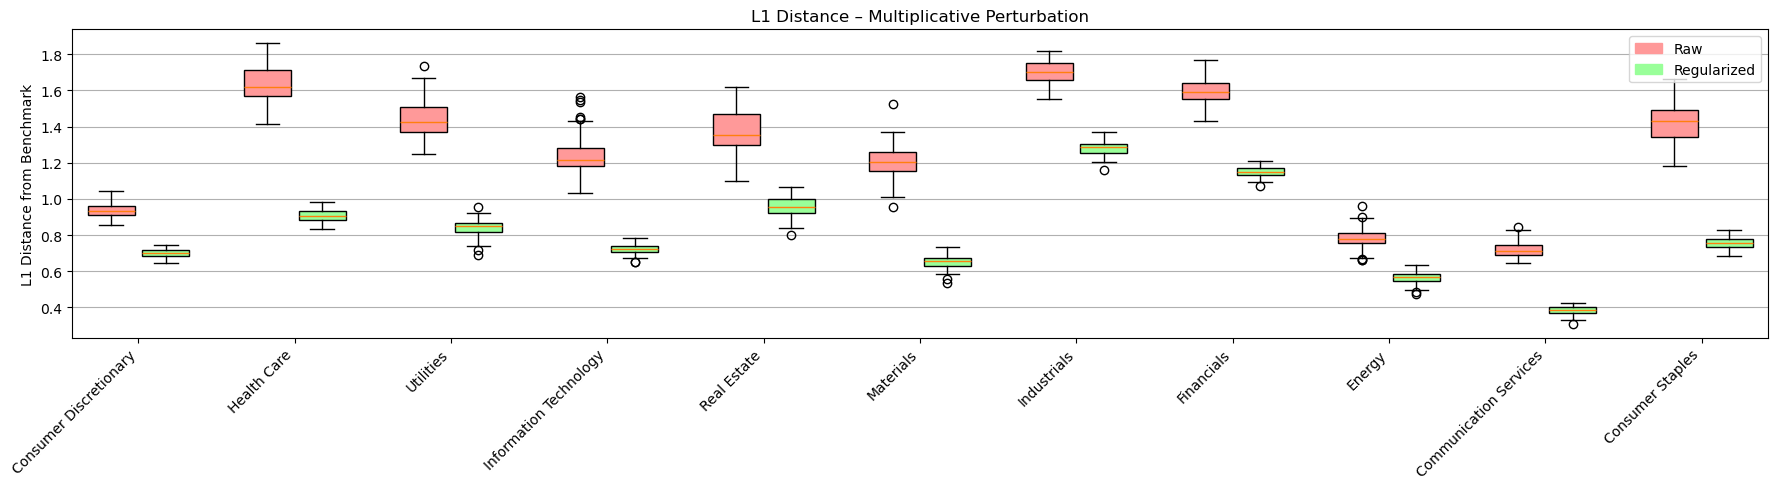

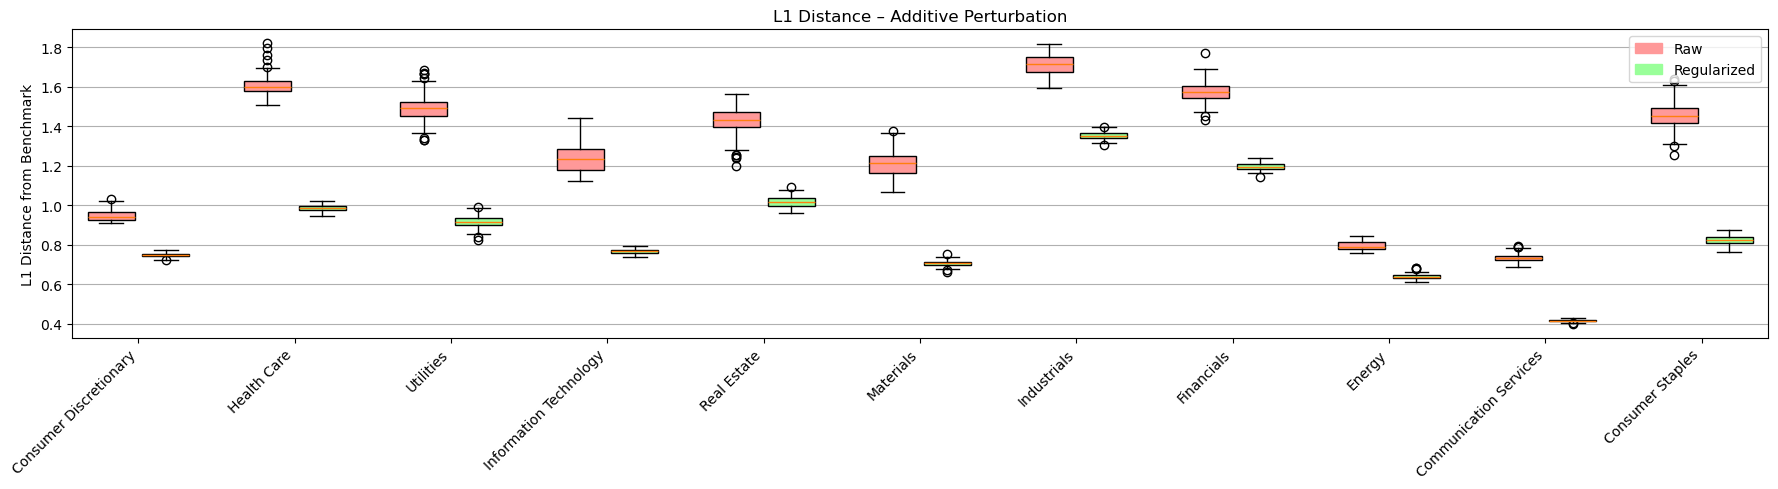

In [18]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

def plot_l1_boxplot(sector_weights, sectors, noise_type, title):
    fig, ax = plt.subplots(figsize=(18, 5))
    positions = []
    data = []
    colors = []
    labels = []

    for i, sector in enumerate(sectors):
        data.extend([
            sector_weights[sector][f"l1_{noise_type}_raw"],
            sector_weights[sector][f"l1_{noise_type}_reg"]
        ])
        positions.extend([2 * i, 2 * i + 0.7])
        colors.extend(['#FF9999', '#99FF99'])
        labels.extend([f"{sector}\nRaw", "Reg"])

    box = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    # X-axis formatting
    ax.set_xticks([2 * i + 0.35 for i in range(len(sectors))])
    ax.set_xticklabels(sectors, rotation=45, ha='right')

    # Labels & title
    ax.set_title(f"L1 Distance – {title}")
    ax.set_ylabel("L1 Distance from Benchmark")
    ax.grid(True, axis='y')

    # Legend
    legend_patches = [
        Patch(color='#FF9999', label='Raw'),
        Patch(color='#99FF99', label='Regularized')
    ]
    ax.legend(handles=legend_patches, loc='upper right')

    plt.tight_layout()
    plt.show()

# Usage
sectors = list(sector_weights.keys())
# Captures joint distribution if estimation is accurate
plot_l1_boxplot(sector_weights, sectors, noise_type="param", title="Parametric Perturbation")
# Non-parametric, respects empirical distribution
plot_l1_boxplot(sector_weights, sectors, noise_type="boot", title="Bootstrapped Perturbation")
# Noise is return-scaled, but not volatility-aware
plot_l1_boxplot(sector_weights, sectors, noise_type="mult", title="Multiplicative Perturbation")
# Adds uniform noise regardless of asset properties
plot_l1_boxplot(sector_weights, sectors, noise_type="add", title="Additive Perturbation")



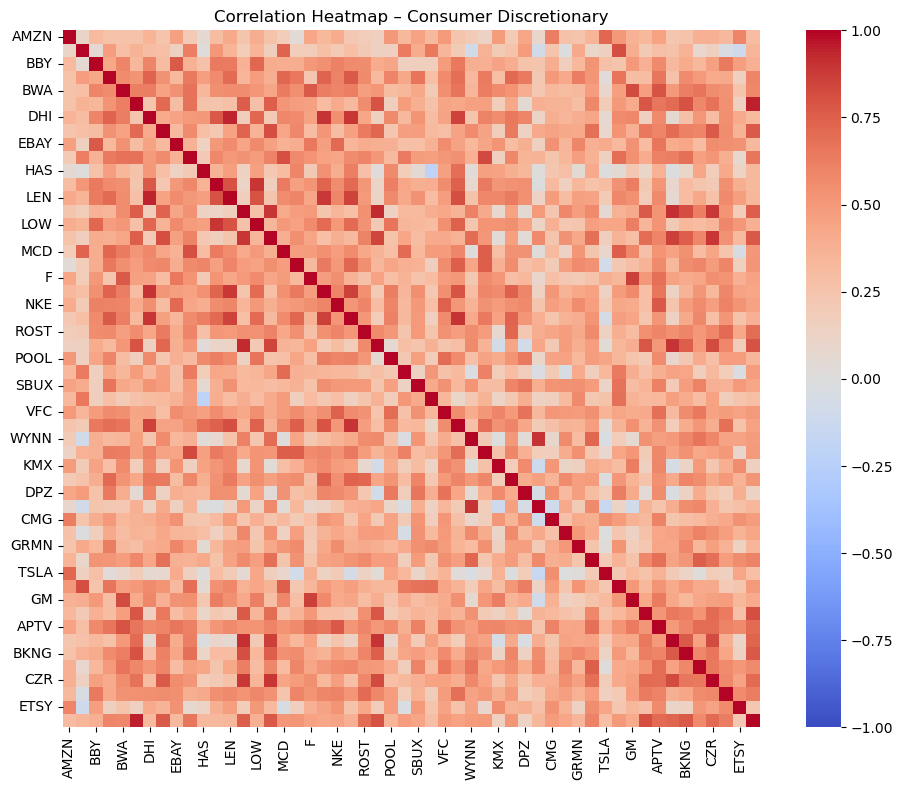

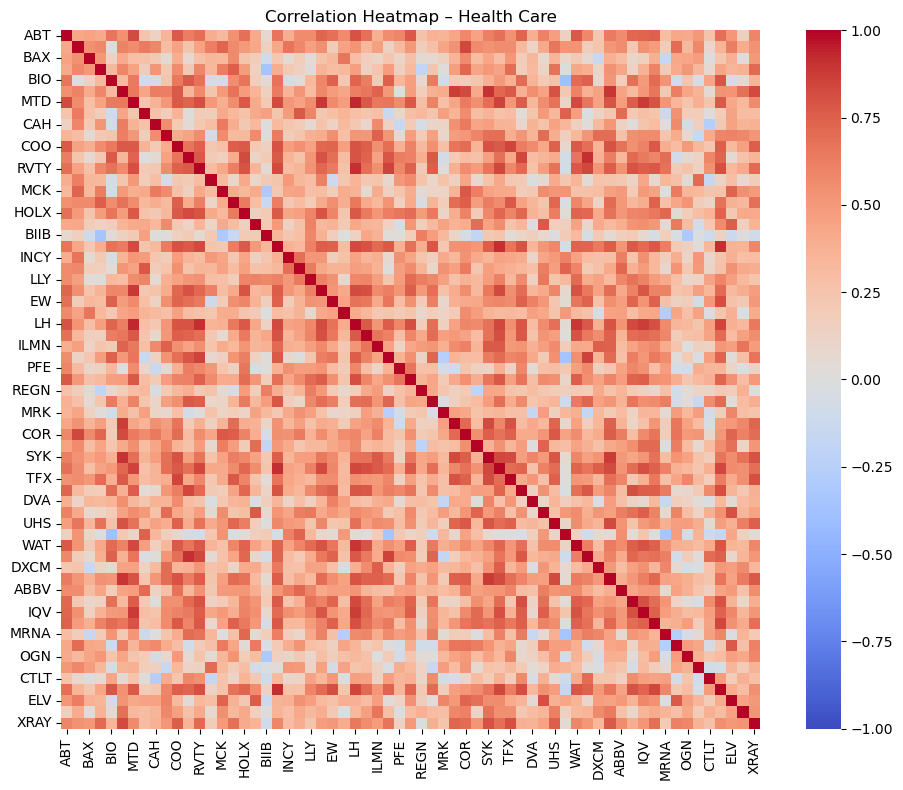

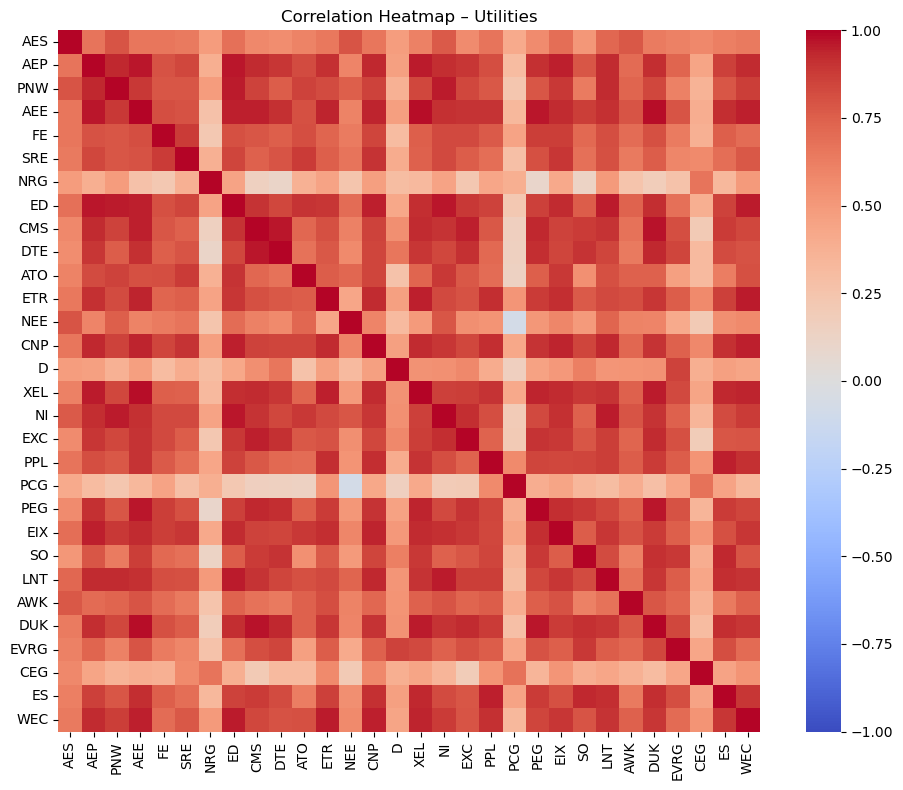

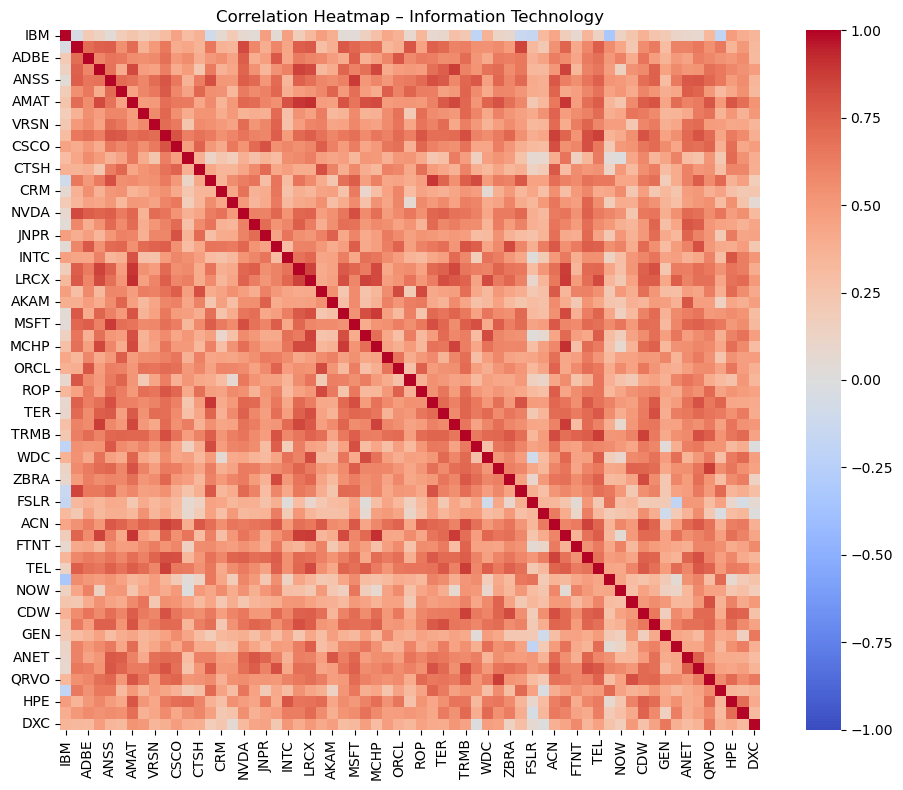

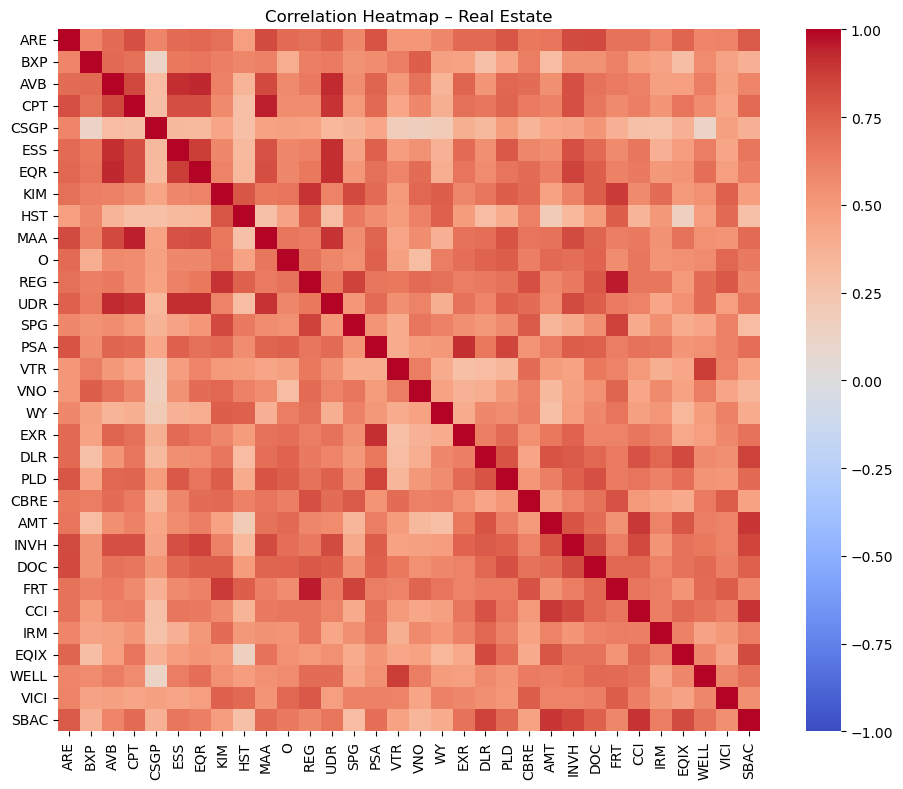

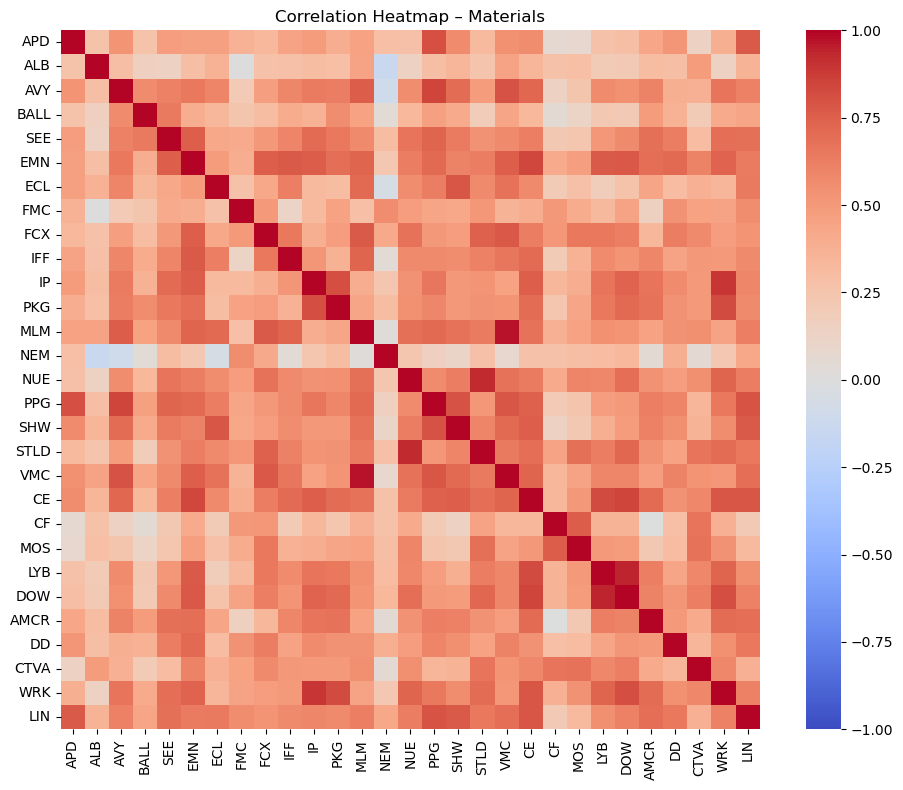

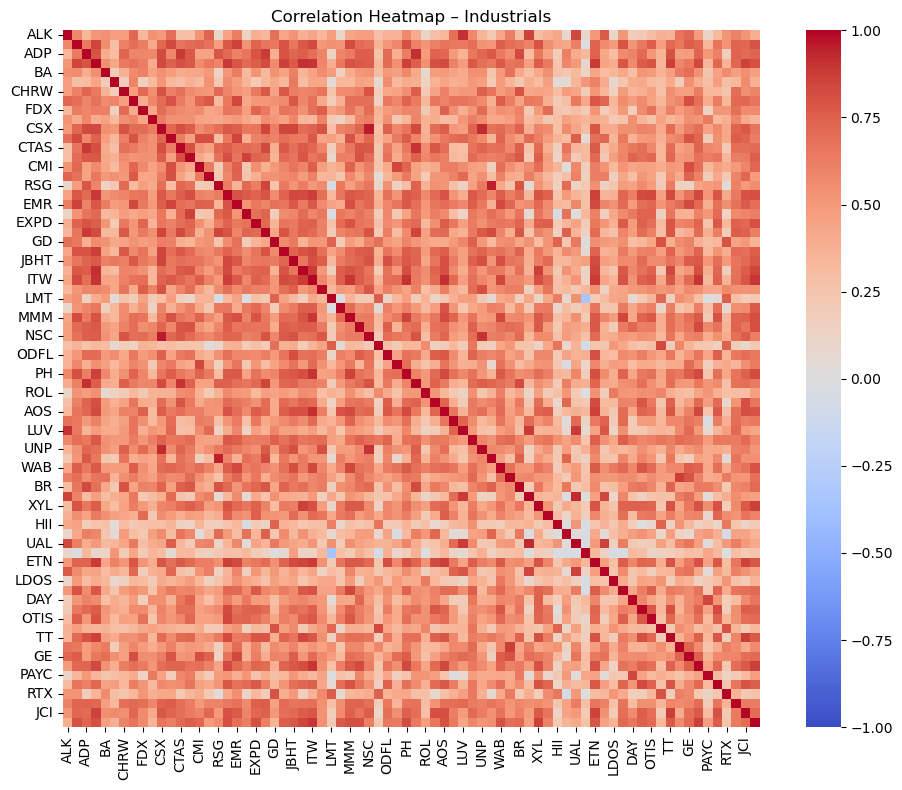

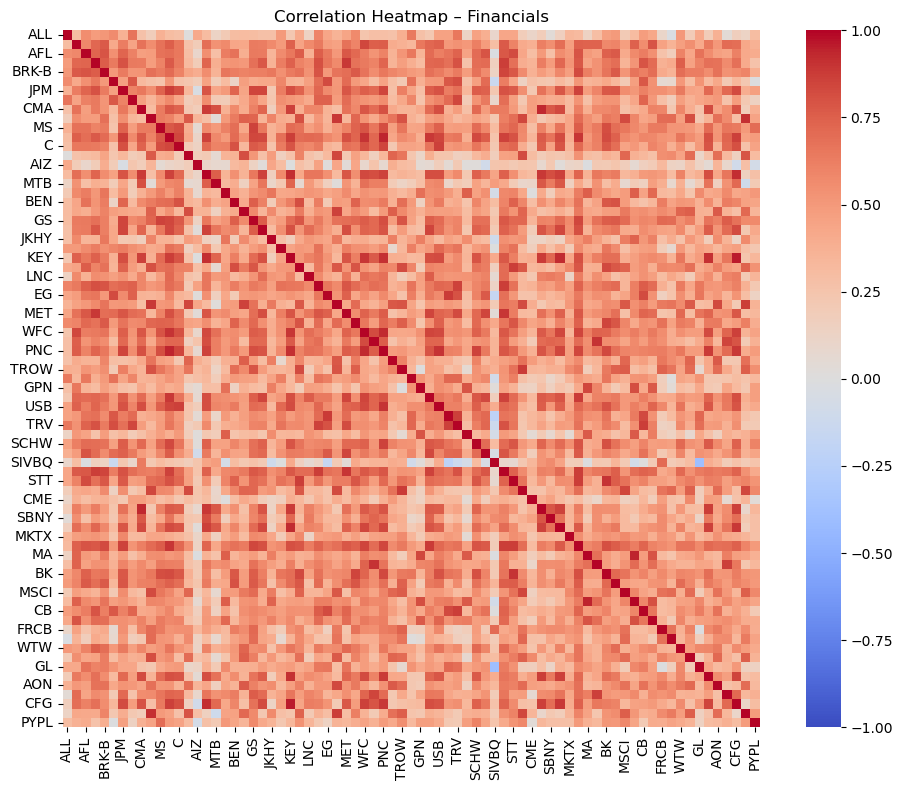

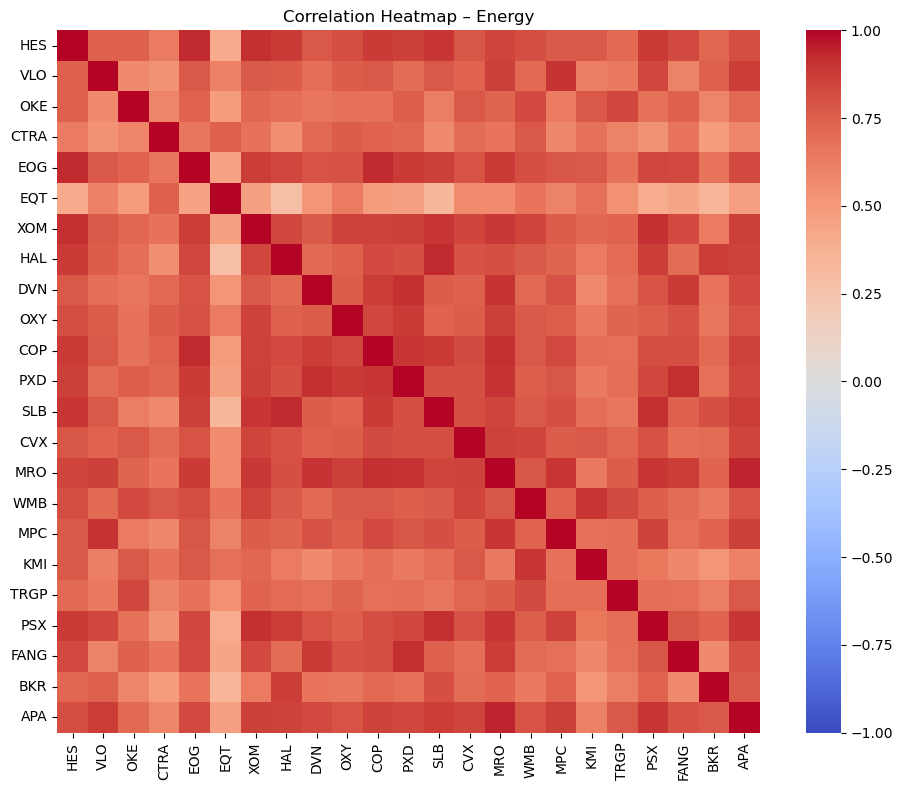

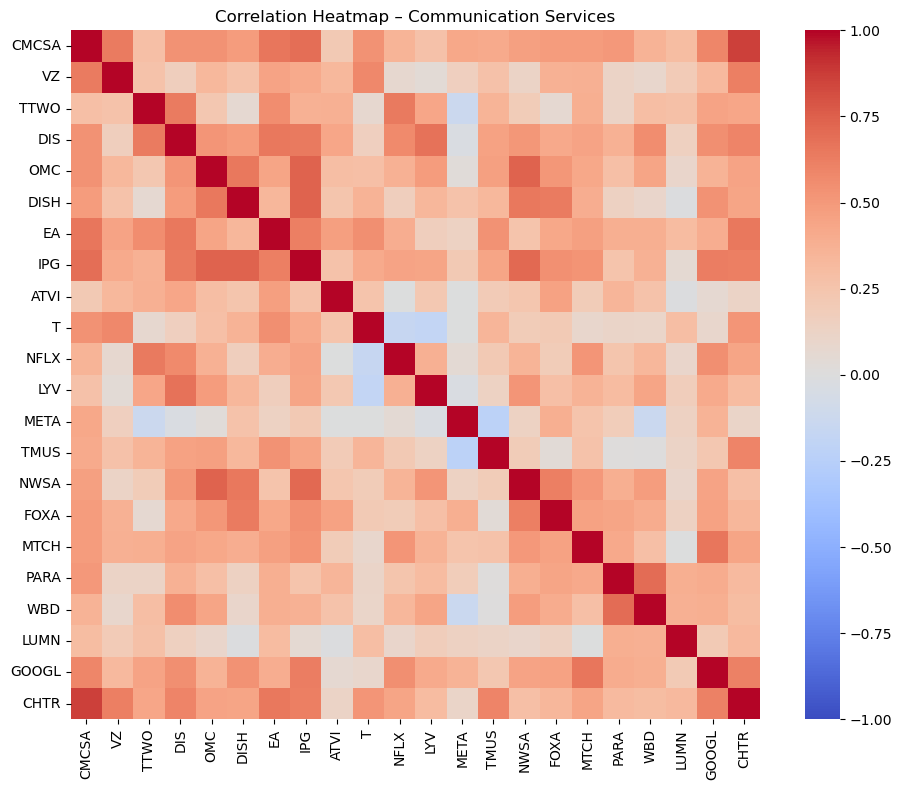

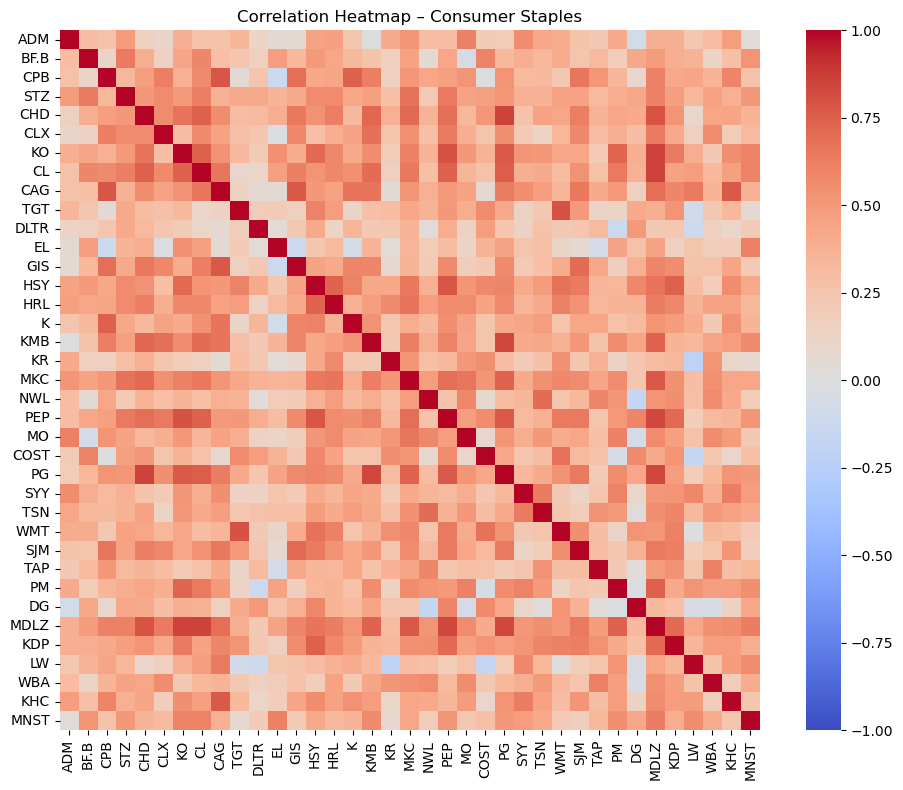

In [19]:
import seaborn as sns

for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()

    corr_matrix = R_clean.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, annot=False)
    plt.title(f"Correlation Heatmap – {sector_name}")
    plt.tight_layout()
    plt.show()


Lower correlation means better diversification and so the overall portfolio risk can be reduce. However, excessively low correlations may be a sign of modeling noise and on the other hand, if secors have high correlations but uniform then the covariance matrix might be less fragile. In fact if we look at what happens after shrinking the covariance matrix for the Energy sector (a sector with strong and uniform correlations) the L1 distance boxplot was already narrow before the regularisation and keeps the same length after regularisation. While for Communication Services a sector with lower correlations, the shrinkage narrowes significantly the L1 distance boxplot, meaning that the inputs sensitivity is reduced. 

In [20]:

for sector_name in data['GICS Sector'].unique():
    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    R_np = R_clean.values
    mu_hat = R_np.mean(axis=0)
    Sigma_hat = np.cov(R_np, rowvar=False)
    T = R_np.shape[0]
    print(mu_hat.shape)
    print(Sigma_hat.shape)
    print(sector_name, mu_hat.mean(), Sigma_hat.mean())

(52,)
(52, 52)
Consumer Discretionary -0.0004300861765770313 0.004543666262463396
(63,)
(63, 63)
Health Care -0.0009738077470104093 0.003378403784205931
(30,)
(30, 30)
Utilities 0.004705105368332529 0.004141742208645419
(63,)
(63, 63)
Information Technology 0.002658315796291701 0.005186837865340513
(32,)
(32, 32)
Real Estate 0.004378166808189379 0.003563676329137956
(29,)
(29, 29)
Materials 0.006709181615926079 0.004447694438014479
(74,)
(74, 74)
Industrials 0.004441287257361684 0.0035934484016785615
(75,)
(75, 75)
Financials 0.007344021806442867 0.003321961897073561
(23,)
(23, 23)
Energy 0.03978376476509813 0.010025320491552785
(22,)
(22, 22)
Communication Services -0.012973824315727694 0.003726937253810584
(37,)
(37, 37)
Consumer Staples 0.005582263308483072 0.0017011786130217777


In [21]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

def plot_te_boxplot(sector_weights, sectors, noise_type, title):
    fig, ax = plt.subplots(figsize=(18, 5))
    positions = []
    data = []
    colors = []

    for i, sector in enumerate(sectors):
        data.extend([
            sector_weights[sector][f"te_{noise_type}_raw"],
            sector_weights[sector][f"te_{noise_type}_reg"]
        ])
        positions.extend([2 * i, 2 * i + 0.7])
        colors.extend(['#87CEEB', '#4682B4'])  # Light/dark blue for raw/regularized

    box = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6)
  
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_xticks([2 * i + 0.35 for i in range(len(sectors))])
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.set_title(f"Realized Tracking Error – {title}")
    ax.set_ylabel("Tracking Error (Annualized)")
    ax.set_ylim(0.02999, 0.03001)
    ax.ticklabel_format(style='plain', axis='y')

    ax.grid(True, axis='y')

    legend_patches = [
        Patch(color='#87CEEB', label='Raw'),
        Patch(color='#4682B4', label='Regularized')
    ]
    ax.legend(handles=legend_patches, loc='upper right')

    plt.tight_layout()
    plt.show()


In [22]:
for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_param_reg']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_boot_reg']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_mult_reg']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_add_reg']))


for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_param_raw']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_boot_raw']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_mult_raw']))

for sector_name in sectors:
    print(np.mean(sector_weights[sector_name]['te_add_raw']))


0.030000053722960142
0.030000042821087813
0.030000016134833732
0.03000002702249001
0.030000046211038772
0.03000003931000655
0.029999989407494054
0.029999971269507503
0.030000039568421236
0.03000002227554613
0.030000025420790086
0.030000055961207105
0.030000036373347184
0.030000015856339723
0.03000002769270292
0.030000037107995415
0.030000049796175716
0.02999998434690892
0.029999983751163625
0.0300000452147639
0.030000022138656438
0.030000026716195352
0.030000073846306034
0.030000036191283014
0.03000001592741667
0.03000002256698201
0.030000045546989273
0.03000003834704001
0.030000007947994085
0.029999973402753382
0.03000004249330572
0.030000014977816857
0.030000027848405383
0.030000054557497227
0.030000033734263763
0.030000015428581127
0.03000002252394709
0.030000052208139366
0.030000047610391194
0.029999989105197026
0.0299999982955323
0.030000038656551462
0.030000016809982523
0.030000021805041827
0.030000026597286976
0.030000011312385312
0.030000010718382583
0.03000001574224832
0.03000

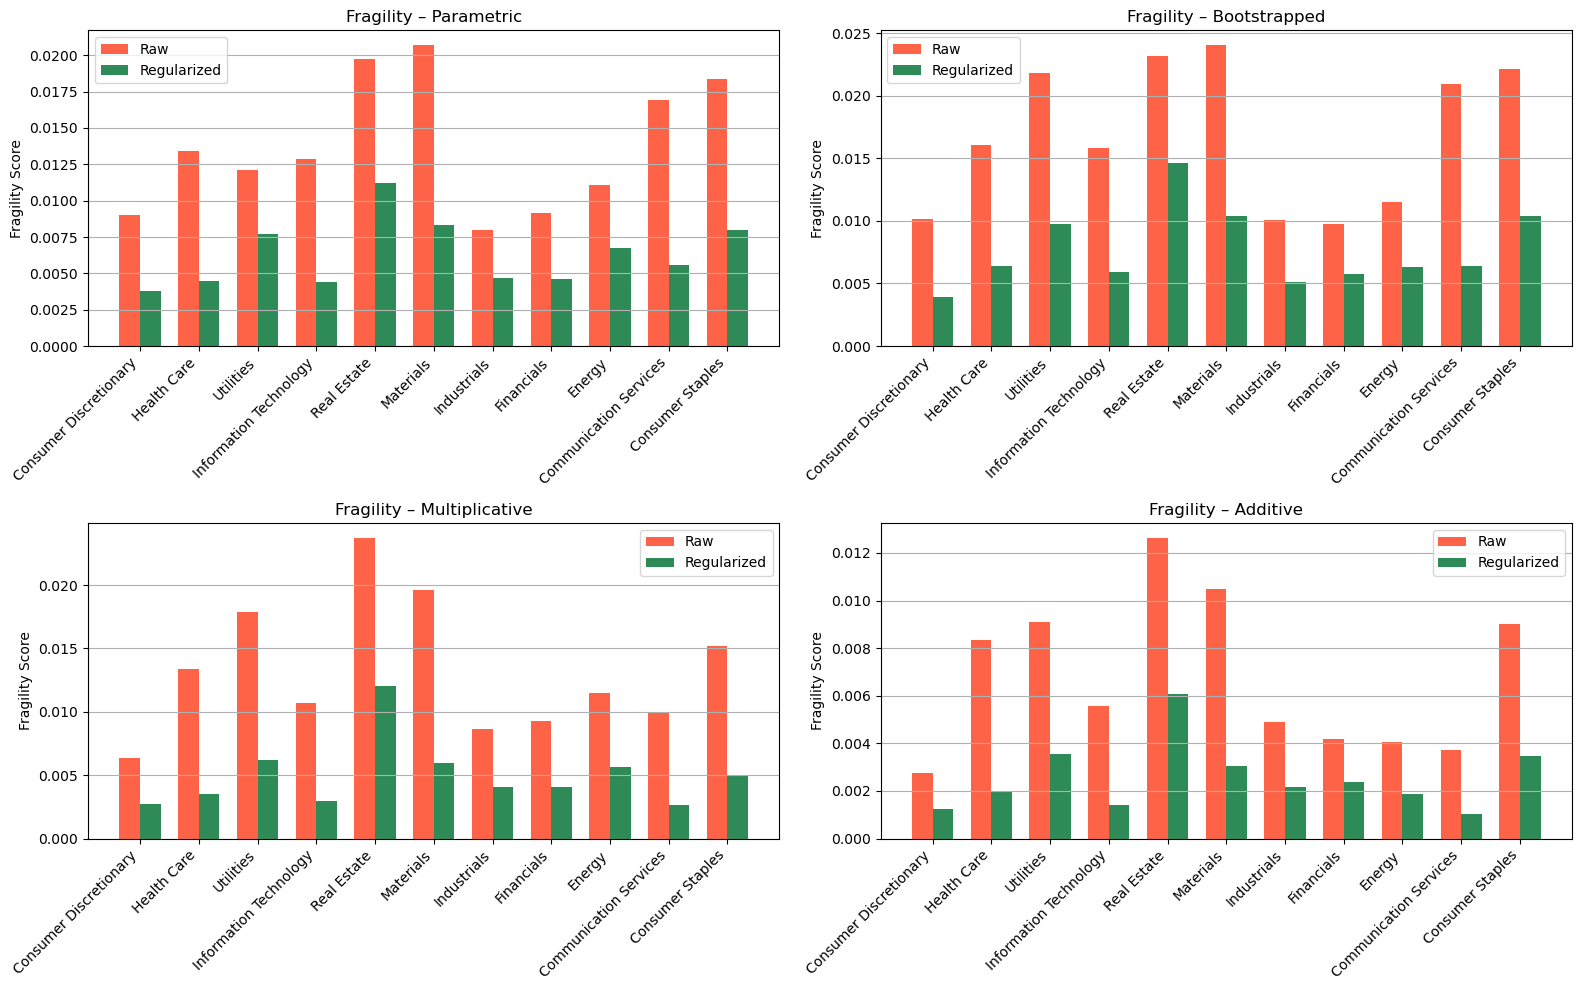

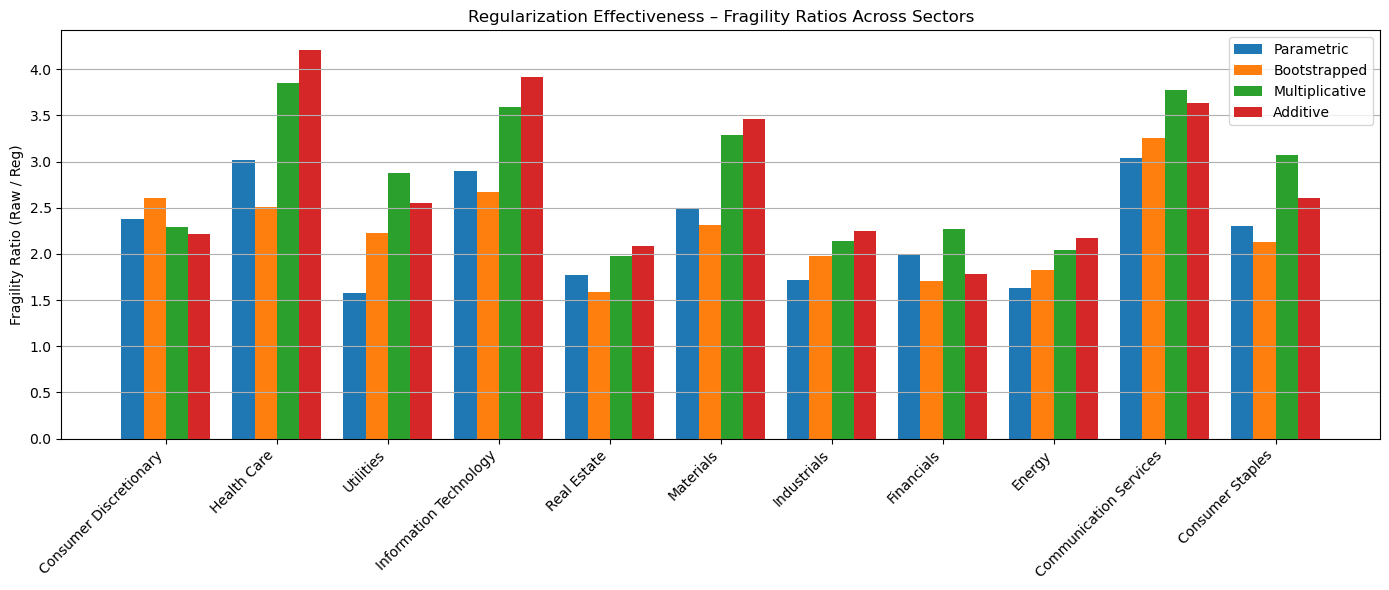

In [23]:
frag_raw_all = {"param": [], "boot": [], "mult": [], "add": []}
frag_reg_all = {"param": [], "boot": [], "mult": [], "add": []}
frag_ratio_all = {"param": [], "boot": [], "mult": [], "add": []}

sectors = list(sector_weights.keys())
for sector in sectors:
    for noise_type in ["param", "boot", "mult", "add"]:
        frag_raw_all[noise_type].append(sector_weights[sector][f"frag_{noise_type}_raw"])
        frag_reg_all[noise_type].append(sector_weights[sector][f"frag_{noise_type}_reg"])
        frag_ratio_all[noise_type].append(sector_weights[sector][f"frag_ratio_{noise_type}"])

# Plot Fragility (Raw vs Reg)
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
noise_labels = ["param", "boot", "mult", "add"]
titles = ["Parametric", "Bootstrapped", "Multiplicative", "Additive"]

for i, noise_type in enumerate(noise_labels):
    ax = axs[i // 2, i % 2]
    x = np.arange(len(sectors))
    width = 0.35

    ax.bar(x - width/2, frag_raw_all[noise_type], width, label='Raw', color='tomato')
    ax.bar(x + width/2, frag_reg_all[noise_type], width, label='Regularized', color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.set_ylabel("Fragility Score")
    ax.set_title(f"Fragility – {titles[i]}")
    ax.legend()
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

# Plot Fragility Ratios
fig, ax = plt.subplots(figsize=(14, 6))

width = 0.2
x = np.arange(len(sectors))

for i, noise_type in enumerate(noise_labels):
    offset = (i - 1.5) * width
    ax.bar(x + offset, frag_ratio_all[noise_type], width, label=titles[i])

ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=45, ha='right')
ax.set_ylabel("Fragility Ratio (Raw / Reg)")
ax.set_title("Regularization Effectiveness – Fragility Ratios Across Sectors")
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

So what happens for Consumer Staples?
1. Regularization shrinks the weight variability
- Each individual asset weight is more tightly concentrated across trials. That means fragility (weight-level std deviation) is lower.

2. But it may allow small, coordinated shifts away from benchmark
- Those smaller deviations may consistently be in different directions across trials. So while the overall size of deviation is small, the L1 distance from benchmark still varies more.

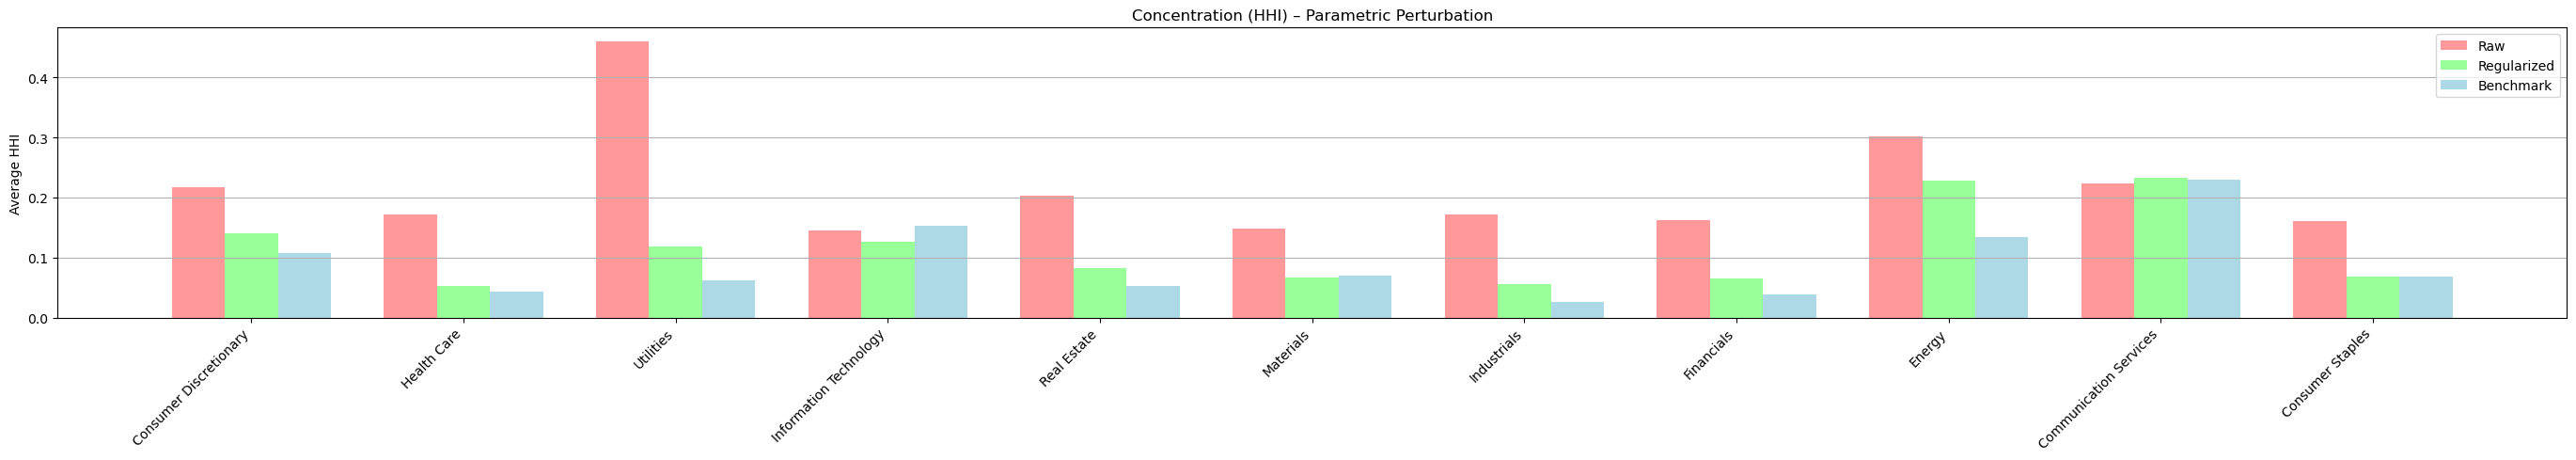

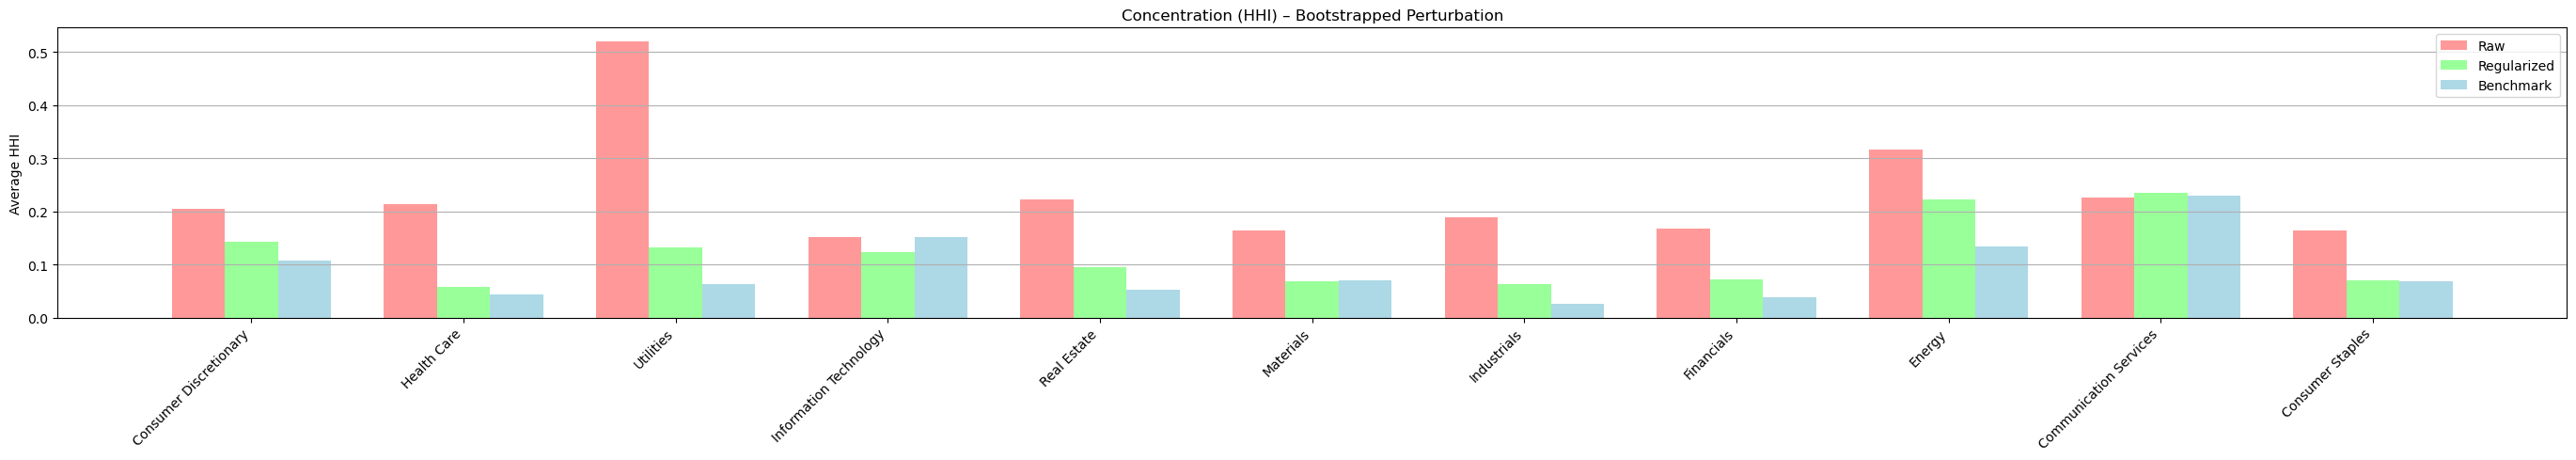

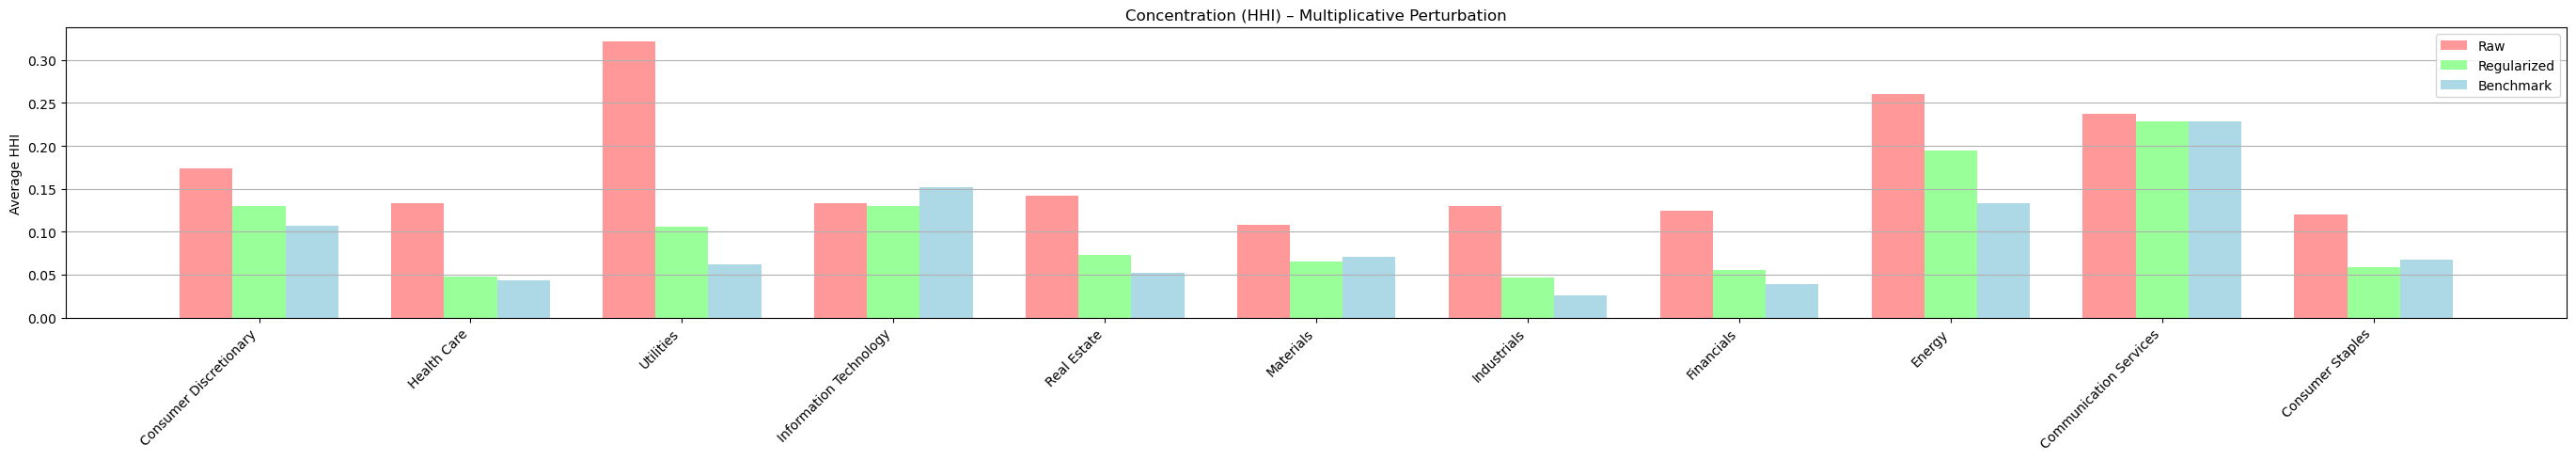

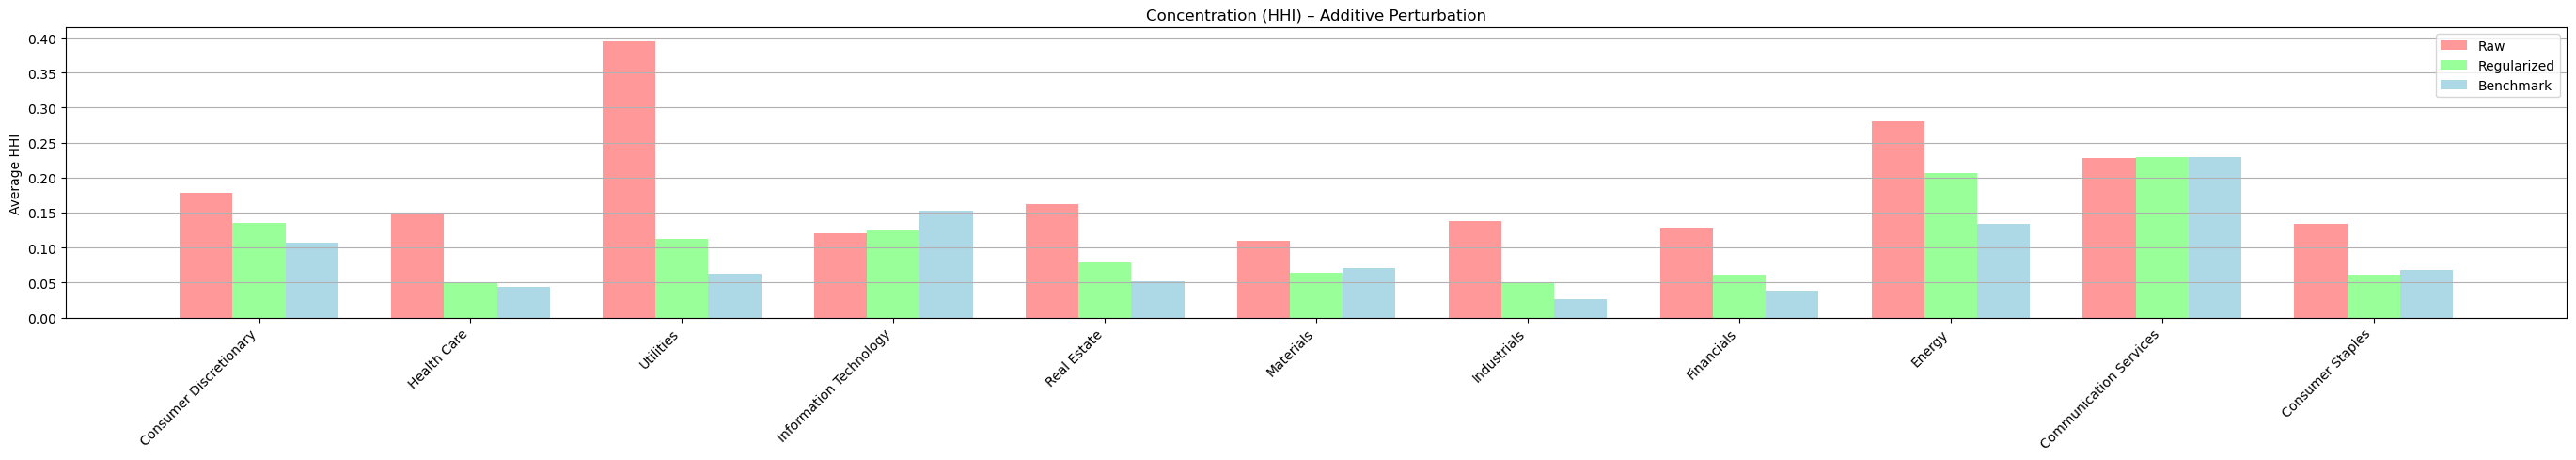

In [24]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

def plot_hhi_bars(sector_weights, sectors, noise_type, title):
    hhi_raw = []
    hhi_reg = []
    hhi_benchmark = []

    for sector in sectors:
        hhi_raw.append(sector_weights[sector][f"hhi_{noise_type}_raw"])
        hhi_reg.append(sector_weights[sector][f"hhi_{noise_type}_reg"])
        hhi_benchmark.append(sector_weights[sector]["hhi_benchmark"])

    x = np.arange(len(sectors))
    width = 0.25  # Narrower to fit 3 bars

    fig, ax = plt.subplots(figsize=(2.5 * len(sectors), 5))

    ax.bar(x - width, hhi_raw, width, label='Raw', color='#FF9999')
    ax.bar(x, hhi_reg, width, label='Regularized', color='#99FF99')
    ax.bar(x + width, hhi_benchmark, width, label='Benchmark', color='#ADD8E6')

    ax.set_xticks(x)
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.set_ylabel("Average HHI")
    ax.set_title(f"Concentration (HHI) – {title}")
    ax.legend()
    ax.grid(True, axis='y')

    plt.tight_layout()
    plt.show()

sectors = list(sector_weights.keys())

plot_hhi_bars(sector_weights, sectors, noise_type="param", title="Parametric Perturbation")
plot_hhi_bars(sector_weights, sectors, noise_type="boot", title="Bootstrapped Perturbation")
plot_hhi_bars(sector_weights, sectors, noise_type="mult", title="Multiplicative Perturbation")
plot_hhi_bars(sector_weights, sectors, noise_type="add", title="Additive Perturbation")